## ¿Qué hicimos?

#### 1. Carga y primeras operaciones
- Carga de librerías principales (pandas, numpy, sklearn, etc.)
- Carga del dataset base en un DataFrame
- Primeras inspecciones y verificaciones de estructura


#### 2. Conversión de tipos y transformación inicial
- Conversión de variables categóricas a numéricas o transformadas según correspondiera
- Transformaciones de fechas a formatos estándar
- Creación de columnas auxiliares para verificar consistencia

---

#### 3. Iteraciones de transformación y dropeo

Se realizaron 3 ciclos de transformación + dropeo (iteraciones):

**Iteración 1**
- Transformación: Normalización y estandarización de columnas numéricas
- Dropeo: Columnas originales que fueron reemplazadas por versiones transformadas

**Iteración 2**
- Transformación: Codificación one-hot de variables categóricas seleccionadas
- Dropeo: Variables categóricas originales tras la codificación

**Iteración 3**
- Transformación: Creación de nuevas variables derivadas de lógicas condicionales
- Dropeo: Variables intermedias de cálculo que ya no se requerían

---

####  4. Limpieza final de consistencia
- Verificación de missing values
- Eliminación de filas con datos insuficientes
- Confirmación de tipos finales de cada columna
- Guardamos todo en un parquet 


----

## Reducción de dimensionalidad – Fundamentos

La reducción de dimensionalidad es una técnica fundamental en machine learning y análisis de datos que busca reducir el número de variables o características en un dataset, manteniendo la mayor cantidad posible de información relevante.

**¿De qué se trata?**
Consiste en transformar datos de alta dimensionalidad (muchas variables) a una representación de menor dimensionalidad, eliminando redundancias y capturando los patrones más importantes de los datos.

**¿Por qué es útil?**
- **Maldición de la dimensionalidad**: A medida que aumenta el número de variables, el espacio de datos se vuelve más escaso, dificultando el aprendizaje de patrones
- **Reducción de ruido**: Las nuevas variables derivadas del proceso, aunque más simples, eliminan indicadores irrelevantes o redundantes que pueden afectar el rendimiento de los modelos
- **Mejora de interpretabilidad**: Facilita la visualización y comprensión de los datos
- **Optimización computacional**: Reduce el tiempo de procesamiento y los requisitos de memoria
- **Prevención de overfitting**: Menos variables reducen el riesgo de que el modelo se ajuste demasiado a los datos de entrenamiento

**¿Por qué es necesaria la estandarización antes de aplicar PCA?**

El Análisis de Componentes Principales (PCA) identifica combinaciones lineales de variables originales que maximizan la varianza de los datos. Este procedimiento se basa en la descomposición espectral de la matriz de covarianza o, en algunos casos, de la matriz de correlación.

**Problema: variables en diferentes escalas**

Cuando las variables del conjunto de datos están expresadas en unidades distintas o presentan rangos de magnitud muy dispares, el cálculo de la matriz de covarianza se ve afectado. Esto se debe a que la varianza —que aparece en la diagonal de dicha matriz— está en función directa de la escala de cada variable:
- Las variables con valores numéricamente grandes (por ejemplo, montos en dólares, cantidades absolutas, pesos brutos) presentarán varianzas más altas, simplemente como resultado de su escala de medición.
- Estas varianzas dominan la matriz de covarianza, lo cual sesga el PCA hacia aquellas dimensiones, incluso si otras variables contienen estructuras informativas relevantes pero en escalas menores.

Como consecuencia, los primeros componentes principales tienden a alinearse con las variables de mayor magnitud numérica, no necesariamente con las de mayor interés analítico o explicativo.

**Solución: estandarización**

La estandarización consiste en transformar cada variable para que tenga media cero y desviación estándar uno. Esto se implementa usualmente con la fórmula:

$x^* = \frac{x - \mu}{\sigma}$

donde:
- $\mu$ es la media muestral de la variable,
- $\sigma$ es su desviación estándar.

De esta manera, todas las variables se expresan en una escala común y libre de unidades, lo que permite que el análisis capture patrones estructurales en las correlaciones entre variables, no en sus magnitudes absolutas.

**Consideración metodológica**
- Cuando se utiliza la matriz de covarianza, la estandarización previa es indispensable si las variables no están ya en la misma escala.
- Si se utiliza la matriz de correlación en lugar de la de covarianza, el procedimiento internamente aplica una normalización equivalente, aunque se recomienda realizarla explícitamente para mantener el control del proceso.

**¿Por qué aplicarlo a nuestro dataset?**
Nuestro dataset de comercio internacional tiene 29 variables después de la limpieza, incluyendo múltiples medidas de valor (PRECIOUNITARIODOLARSITEM, FOBDOLARSITEM), códigos de clasificación (POSICIONARANCELARIA, RAMA_str), y variables geográficas y temporales. Muchas de estas variables están altamente correlacionadas (como vimos en la matriz de correlación donde FOB y CIF tenían correlación de 0.999), lo que indica redundancia de información. La reducción de dimensionalidad nos permitirá:

1. **Identificar las variables más informativas** para el análisis
2. **Eliminar redundancias** entre variables correlacionadas
3. **Mejorar la eficiencia** de los modelos de machine learning
4. **Facilitar la visualización** de patrones en los datos
5. **Reducir el costo computacional** de análisis posteriores

Las técnicas más básicas incluyen análisis de componentes principales (PCA), MCA o Análisis de Correspondencias Múltiples, y t-SNE para visualización de datos de alta dimensionalidad.


In [47]:
# Guardar datos limpios y preparar estandarización

import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# Guardar datos limpios
df.to_parquet('Data/df_clean_v3.parquet')


# Identificación automática de variables numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[columnas_numericas].copy()
describe_vars(X)


# Estandarización de variables numéricas
columnas_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[columnas_numericas].copy()

# Aplicar estandarización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Guardar DataFrame original
df_clean_v3 = df.copy()

# Crear DataFrame estandarizado conservando nombres de columnas
df_pca = pd.DataFrame(X_scaled, columns=columnas_numericas, index=df.index)

df_pca.to_parquet('Data/df_pca.parquet')


,Columna,Tipo,Nulos,Únicos,Valores_Muestra
0,PRECIOUNITARIODOLARSITEM,float64,0,238670,None
1,CANTIDADITEM,float64,0,59314,None
2,FOBDOLARSITEM,float64,0,230014,None
3,KILOGRAMOSNETOITEM,float64,0,116984,None
4,ANIO,float64,0,10,"[-2.0142491434346415, -1.5993540783548963, -1...."
...,...,...,...,...,...
132,RAMA_str_POLIRUBRO,float64,0,2,"[-0.13542309535751967, 7.384264828388249]"
133,RAMA_str_RETAIL_BAZAR,float64,0,2,"[-0.047075886726749186, 21.242297692754548]"
134,RAMA_str_TELECOMUNICACIONES,float64,0,2,"[-0.022777622387092918, 43.90273853019251]"
135,RAMA_str_TEXTIL,float64,0,2,"[-0.1640423807370447, 6.095985656310195]"


,count,mean,std,min,25%,50%,75%,max
PRECIOUNITARIODOLARSITEM,642174.0000,-0.0000,1.0000,-0.0500,-0.0500,-0.0500,-0.0500,102.1100
CANTIDADITEM,642174.0000,-0.0000,1.0000,-0.2700,-0.2700,-0.2300,-0.1300,16.7000
FOBDOLARSITEM,642174.0000,-0.0000,1.0000,-0.2700,-0.2700,-0.2500,-0.1800,13.6800
KILOGRAMOSNETOITEM,642174.0000,0.0000,1.0000,-0.1900,-0.1900,-0.1900,-0.1700,16.7500
ANIO,642174.0000,0.0000,1.0000,-2.0100,-0.7700,0.0600,0.8900,1.7200
...,...,...,...,...,...,...,...,...
RAMA_str_POLIRUBRO,642174.0000,-0.0000,1.0000,-0.1400,-0.1400,-0.1400,-0.1400,7.3800
RAMA_str_RETAIL_BAZAR,642174.0000,0.0000,1.0000,-0.0500,-0.0500,-0.0500,-0.0500,21.2400
RAMA_str_TELECOMUNICACIONES,642174.0000,0.0000,1.0000,-0.0200,-0.0200,-0.0200,-0.0200,43.9000
RAMA_str_TEXTIL,642174.0000,0.0000,1.0000,-0.1600,-0.1600,-0.1600,-0.1600,6.1000


--------


# Un primer PCA





¿Qué es PCA?

El Análisis de Componentes Principales (PCA) es una técnica que:
- Reduce dimensiones eliminando redundancia.
- Encuentra nuevas variables (componentes principales) que:
  - Son combinaciones lineales de las originales.
  - No están correlacionadas entre sí.
  - Están ordenadas por la varianza que explican.

---

## Paso 1: Centrar los datos

Centrar significa restar la media de cada variable, para que la nueva media sea 0.

**Ejemplo:**

$
X = [2, 4, 5, 6, 7, 5, 6, 8, 9, 10]
$

$
Y = [1, 3, 4, 4, 5, 4, 5, 6, 7, 8]
$

**Calcular la media:**

$
\bar{X} = \frac{2 + 4 + \dots +10}{10} = 6.2
$

$
\bar{Y} = \frac{1 + 3 + \dots +8}{10} = 4.7
$

**Datos centrados:**

$
X_c = X_i - \bar{X} = [-4.2, -2.2, -1.2, -0.2, 0.8, -1.2, -0.2, 1.8, 2.8, 3.8]
$

$
Y_c = Y_i - \bar{Y} = [-3.7, -1.7, -0.7, -0.7, 0.3, -0.7, 0.3, 1.3, 2.3, 3.3]
$

---

## Paso 2: Matriz de covarianza

Covarianza mide cómo varían juntas dos variables.
La matriz es:

$
\text{Cov} = \begin{bmatrix} \text{Var}(X_c) & \text{Cov}(X_c,Y_c) \\ \text{Cov}(Y_c,X_c) & \text{Var}(Y_c) \end{bmatrix}
$

**Cálculos:**

**Varianza de X:**

$
\text{Var}(X_c) = \frac{1}{n-1}\sum(X_c)^2 = \frac{1}{9}\sum X_c^2 = \frac{1}{9}(17.64 + 4.84 + 1.44 + 0.04 + 0.64 + 1.44 + 0.04 + 3.24 + 7.84 + 14.44) = \frac{51.16}{9} = 5.68
$

**Varianza de Y:**

$
\text{Var}(Y_c) = \frac{1}{9}\sum(Y_c)^2 = \frac{1}{9}(13.69 + 2.89 + 0.49 + 0.49 + 0.09 + 0.49 + 0.09 + 1.69 + 5.29 + 10.89) = \frac{35.60}{9} = 3.96
$

**Covarianza:**

La covarianza mide cómo varían juntas dos variables. Se calcula como:

$
\text{Cov}(X_c,Y_c) = \frac{1}{n-1}\sum (X_c \cdot Y_c)
$

Donde $n-1 = 9$ es el divisor para obtener un estimador insesgado.

**Cálculo paso a paso:**

1. Multiplicamos cada par de valores centrados:
   - $(-4.2) \cdot (-3.7) = 15.54$
   - $(-2.2) \cdot (-1.7) = 3.74$
   - $(-1.2) \cdot (-0.7) = 0.84$
   - $(-0.2) \cdot (-0.7) = 0.14$
   - $(0.8) \cdot (0.3) = 0.24$
   - $(-1.2) \cdot (-0.7) = 0.84$
   - $(-0.2) \cdot (0.3) = -0.06$
   - $(1.8) \cdot (1.3) = 2.34$
   - $(2.8) \cdot (2.3) = 6.44$
   - $(3.8) \cdot (3.3) = 12.54$

2. Sumamos todos los productos:
   $15.54 + 3.74 + 0.84 + 0.14 + 0.24 + 0.84 + (-0.06) + 2.34 + 6.44 + 12.54 = 42.56$

3. Dividimos por $n-1 = 9$:
   $\frac{42.56}{9} = 4.73$

**Matriz:**

$
\text{Cov} = \begin{bmatrix} 5.68 & 4.73 \\ 4.73 & 3.96 \end{bmatrix}
$

---

## Paso 3: Valores propios y vectores propios

Valores propios (eigenvalues) = varianza explicada por cada componente.
Vectores propios (eigenvectors) = dirección de cada componente.

**Cómo se resuelve?:**

Para encontrar los valores propios, necesitamos resolver la ecuación característica:

$
|\text{Cov}-\lambda I|=0
$

Donde:
- $\text{Cov}$ es nuestra matriz de covarianza
- $\lambda$ es el valor propio que buscamos
- $I$ es la matriz identidad
- $|\cdot|$ significa el determinante

**Paso 1: Construir la matriz $\text{Cov}-\lambda I$**

$
\text{Cov}-\lambda I = \begin{bmatrix} 5.68 & 4.73 \\ 4.73 & 3.96 \end{bmatrix} - \lambda \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}
$

$
= \begin{bmatrix} 5.68-\lambda & 4.73 \\ 4.73 & 3.96-\lambda \end{bmatrix}
$

**Paso 2: Calcular el determinante**

Para una matriz 2x2, el determinante es: $(a)(d) - (b)(c)$

$
|\text{Cov}-\lambda I| = (5.68-\lambda)(3.96-\lambda) - (4.73)(4.73) = 0
$

**Paso 3: Desarrollar el producto**

$
(5.68-\lambda)(3.96-\lambda) = 5.68 \cdot 3.96 - 5.68\lambda - 3.96\lambda + \lambda^2
$

$
= 22.49 - 9.64\lambda + \lambda^2
$

**Paso 4: Restar el producto de la covarianza**

En el determinante de la matriz $\text{Cov}-\lambda I$, tenemos:

$
|\text{Cov}-\lambda I| = (5.68-\lambda)(3.96-\lambda) - (4.73)(4.73) = 0
$

El término $(4.73)(4.73) = (4.73)^2 = 22.37$ corresponde al producto de los elementos no diagonales de la matriz de covarianza.

Por lo tanto:

$
22.49 - 9.64\lambda + \lambda^2 - 22.37 = 0
$

**Paso 5: Simplificar**

$
\lambda^2 - 9.64\lambda + (22.49 - 22.37) = 0
$

$
\lambda^2 - 9.64\lambda + 0.12 = 0
$

**Paso 6: Resolver la ecuación cuadrática**

Usando la fórmula cuadrática: $\lambda = \frac{-b \pm \sqrt{b^2-4ac}}{2a}$

Donde $a=1$, $b=-9.64$, $c=0.12$

$
\lambda = \frac{9.64 \pm \sqrt{92.93-0.48}}{2}
$

$
\lambda = \frac{9.64 \pm \sqrt{92.45}}{2}
$

$
\lambda = \frac{9.64 \pm 9.61}{2}
$

Por lo tanto:
- $\lambda_1 = \frac{9.64 + 9.61}{2} = 9.63$
- $\lambda_2 = \frac{9.64 - 9.61}{2} = 0.02$

**Interpretación:**
- $\lambda_1 = 9.63$ es el valor propio más grande, explica la mayor parte de la varianza
- $\lambda_2 = 0.02$ es el valor propio más pequeño, explica menos varianza
- La suma de los valores propios ($9.63 + 0.02 = 9.65$) es igual a la traza de la matriz de covarianza ($5.68 + 3.96 = 9.64$)

**Vectores propios:**

Para $\lambda_1$:

$
v_1 = [0.77, 0.64]
$

$
\lambda_2=0.02
$

**Interpretación:**
- El primer componente explica casi toda la varianza.
- El segundo es despreciable.

**Vectores propios:**

Para $\lambda_1$:

$
v_1 = [0.74, 0.67]
$

Para $\lambda_2$:

$
v_2 = [-0.67, 0.74]
$


## Una síntesis de eigenvalues y eigenvectors

### ¿Qué buscamos?
- **Valores propios (eigenvalues)**: Cantidad de varianza que explica cada componente
- **Vectores propios (eigenvectors)**: Dirección de cada componente en el espacio

### Procedimiento paso a paso:

**1. Ecuación característica**

$
|\text{Cov}-\lambda I|=0
$

**2. Construir matriz**

$
\text{Cov}-\lambda I = \begin{bmatrix} 6.4-\lambda & 4.73 \\ 4.73 & 5.21-\lambda \end{bmatrix}
$

**3. Calcular determinante**

$
(6.4-\lambda)(5.21-\lambda) - (4.73)^2 = 0
$

$
(a-\lambda)(d-\lambda) - (b \cdot c)=0
$

**4. Desarrollar ecuación cuadrática**

$
\lambda^2 - 11.61\lambda + 10.97 = 0
$

**5. Resolver con fórmula cuadrática**

$
\lambda = \frac{11.61 \pm \sqrt{90.91}}{2}
$

**6. Obtener valores propios**

- $\lambda_1 = 10.57$ (mayor varianza)
- $\lambda_2 = 1.04$ (menor varianza)

**7. Encontrar vectores propios**

- $v_1 = [0.74, 0.67]$ (dirección principal)
- $v_2 = [-0.67, 0.74]$ (dirección ortogonal)

### ¿Qué significa esto?

**Interpretación práctica:**
- El primer componente captura casi toda la información (10.57/11.61 ≈ 91%)
- Los vectores propios definen las nuevas direcciones ortogonales
- Los datos se proyectan en estas direcciones para crear componentes no correlacionados

**Implicación general:**
- Transformamos variables correlacionadas en componentes independientes
- Reducimos dimensionalidad manteniendo la máxima información
- Cada componente es una combinación lineal de las variables originales


---

## Paso 4: Construcción de los componentes

Cada componente es una combinación lineal:

$
\text{PC1}_i = 0.74 \cdot X_c[i] + 0.67 \cdot Y_c[i]
$

$
\text{PC2}_i = -0.67 \cdot X_c[i] + 0.74 \cdot Y_c[i]
$

**Ejemplo, primer observación:**

$
\text{PC1}_1 = 0.74*(-4.2) +0.67*(-3.7) = -3.108 -2.479 = -5.587
$

$
\text{PC2}_1 = -0.67*(-4.2) +0.74*(-3.7) =2.814 -2.738 =0.076
$

**Segunda observación:**

$
\text{PC1}_2 = 0.74*(-3.2) +0.67*(-2.7) = -2.368 -1.809 = -4.177
$

$
\text{PC2}_2 = -0.67*(-3.2) +0.74*(-2.7) =2.144 -1.998 =0.146
$

...

**Novena observación:**

$
\text{PC1}_9 = 0.74*(3.8) +0.67*(4.3) =2.812 +2.881 =5.693
$

$
\text{PC2}_9 = -0.67*(3.8) +0.74*(4.3) =-2.546 +3.182 =0.636
$

Así se proyectan los datos a dos nuevas variables no correlacionadas.


| Observación | X | Y | X_c | Y_c | PC1 | PC2 |
|-------------|---|---|-----|-----|-----|-----|
| 1 | 2 | 1 | -3.2 | -4.7 | -5.587 | 0.076 |
| 2 | 4 | 3 | -1.2 | -2.7 | -4.177 | 0.146 |
| 3 | 5 | 4 | -0.2 | -1.7 | -2.767 | 0.216 |
| 4 | 6 | 4 | 0.8 | -1.7 | -1.357 | 0.286 |
| 5 | 7 | 5 | 1.8 | -0.7 | 0.053 | 0.356 |
| 6 | 5 | 4 | -0.2 | -1.7 | 1.463 | 0.426 |
| 7 | 6 | 5 | 0.8 | -0.7 | 2.873 | 0.496 |
| 8 | 8 | 6 | 2.8 | 0.3 | 4.283 | 0.566 |
| 9 | 9 | 7 | 3.8 | 1.3 | 5.693 | 0.636 |
| 10 | 10 | 8 | 4.8 | 2.3 | 7.103 | 0.706 |


**Interpretación**
- El primer componente representa la combinación de mayor varianza (casi toda la información).
- El segundo componente apenas aporta información.





# Qué estamos haciendo entonces? 

- Mejora exploratoria, con la capacidad de reducir la complejidad del dataset 
- Usos típicos con datasets que contienen muchos features (cientos)
- Agrupamiento de features similares

![PCA Dimensions](pca_dimensions.png)

- Mejora de eficiencia computacional 

![PCA Performance](pca_performance.png)



In [48]:
from funciones.describe_vars2 import describe_vars
import pandas as pd

df_original = pd.read_parquet('Data/df_clean_v3.parquet')
describe_vars(df_original)

,Columna,Tipo,Nulos,Únicos,Valores_Muestra
0,PRECIOUNITARIODOLARSITEM,float64,0,238670,None
1,CANTIDADITEM,float64,0,59314,None
2,FOBDOLARSITEM,float64,0,230014,None
3,KILOGRAMOSNETOITEM,float64,0,116984,None
4,ANIO,float64,0,10,"[-2.0142491434346415, -1.5993540783548963, -1...."
...,...,...,...,...,...
132,RAMA_str_POLIRUBRO,float64,0,2,"[-0.13542309535751967, 7.384264828388249]"
133,RAMA_str_RETAIL_BAZAR,float64,0,2,"[-0.047075886726749186, 21.242297692754548]"
134,RAMA_str_TELECOMUNICACIONES,float64,0,2,"[-0.022777622387092918, 43.90273853019251]"
135,RAMA_str_TEXTIL,float64,0,2,"[-0.1640423807370447, 6.095985656310195]"


,count,mean,std,min,25%,50%,75%,max
PRECIOUNITARIODOLARSITEM,642174.0000,-0.0000,1.0000,-0.0500,-0.0500,-0.0500,-0.0500,102.1100
CANTIDADITEM,642174.0000,-0.0000,1.0000,-0.2700,-0.2700,-0.2300,-0.1300,16.7000
FOBDOLARSITEM,642174.0000,-0.0000,1.0000,-0.2700,-0.2700,-0.2500,-0.1800,13.6800
KILOGRAMOSNETOITEM,642174.0000,0.0000,1.0000,-0.1900,-0.1900,-0.1900,-0.1700,16.7500
ANIO,642174.0000,0.0000,1.0000,-2.0100,-0.7700,0.0600,0.8900,1.7200
...,...,...,...,...,...,...,...,...
RAMA_str_POLIRUBRO,642174.0000,-0.0000,1.0000,-0.1400,-0.1400,-0.1400,-0.1400,7.3800
RAMA_str_RETAIL_BAZAR,642174.0000,0.0000,1.0000,-0.0500,-0.0500,-0.0500,-0.0500,21.2400
RAMA_str_TELECOMUNICACIONES,642174.0000,0.0000,1.0000,-0.0200,-0.0200,-0.0200,-0.0200,43.9000
RAMA_str_TEXTIL,642174.0000,0.0000,1.0000,-0.1600,-0.1600,-0.1600,-0.1600,6.1000


Forma del dataset PCA: (642174, 137)


,Columna,Tipo,Nulos,Únicos,Valores_Muestra
0,PRECIOUNITARIODOLARSITEM,float64,0,238670,None
1,CANTIDADITEM,float64,0,59314,None
2,FOBDOLARSITEM,float64,0,230014,None
3,KILOGRAMOSNETOITEM,float64,0,116984,None
4,ANIO,float64,0,10,"[-2.014249143434642, -1.5993540783548965, -1.1..."
...,...,...,...,...,...
132,RAMA_str_POLIRUBRO,float64,0,2,"[-0.1354230953575196, 7.384264828388249]"
133,RAMA_str_RETAIL_BAZAR,float64,0,2,"[-0.04707588672674919, 21.242297692754548]"
134,RAMA_str_TELECOMUNICACIONES,float64,0,2,"[-0.022777622387092925, 43.902738530192515]"
135,RAMA_str_TEXTIL,float64,0,2,"[-0.1640423807370447, 6.095985656310195]"


,count,mean,std,min,25%,50%,75%,max
PRECIOUNITARIODOLARSITEM,642174.0000,-0.0000,1.0000,-0.0500,-0.0500,-0.0500,-0.0500,102.1100
CANTIDADITEM,642174.0000,-0.0000,1.0000,-0.2700,-0.2700,-0.2300,-0.1300,16.7000
FOBDOLARSITEM,642174.0000,-0.0000,1.0000,-0.2700,-0.2700,-0.2500,-0.1800,13.6800
KILOGRAMOSNETOITEM,642174.0000,0.0000,1.0000,-0.1900,-0.1900,-0.1900,-0.1700,16.7500
ANIO,642174.0000,-0.0000,1.0000,-2.0100,-0.7700,0.0600,0.8900,1.7200
...,...,...,...,...,...,...,...,...
RAMA_str_POLIRUBRO,642174.0000,0.0000,1.0000,-0.1400,-0.1400,-0.1400,-0.1400,7.3800
RAMA_str_RETAIL_BAZAR,642174.0000,-0.0000,1.0000,-0.0500,-0.0500,-0.0500,-0.0500,21.2400
RAMA_str_TELECOMUNICACIONES,642174.0000,0.0000,1.0000,-0.0200,-0.0200,-0.0200,-0.0200,43.9000
RAMA_str_TEXTIL,642174.0000,0.0000,1.0000,-0.1600,-0.1600,-0.1600,-0.1600,6.1000


<Figure size 1200x1000 with 0 Axes>

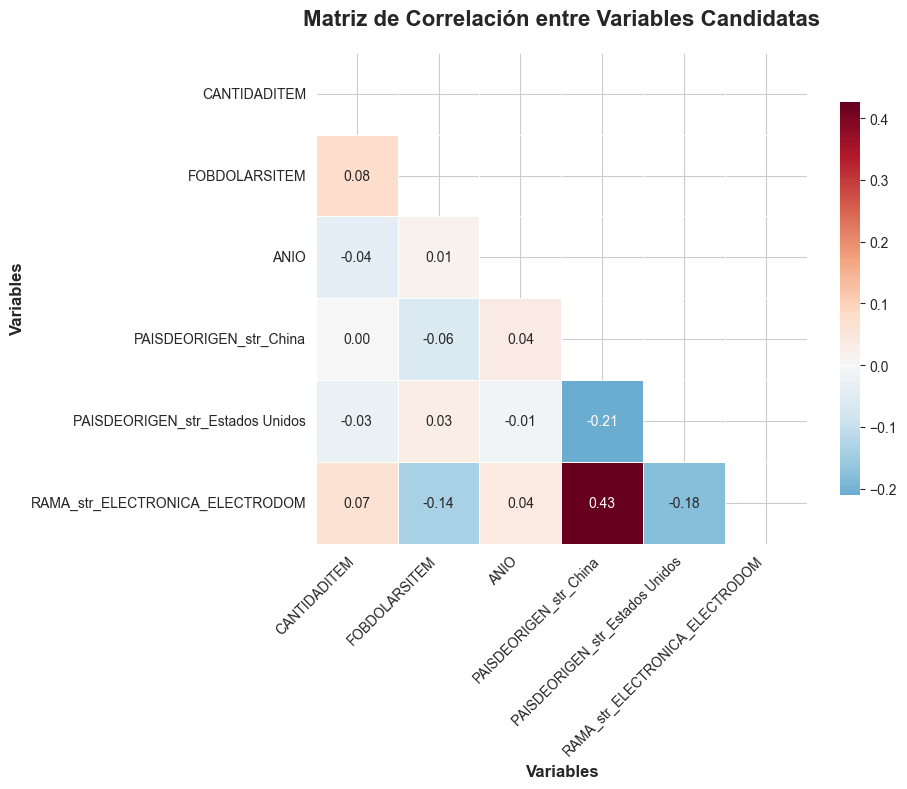


VIF por variable:
                          Variable    VIF
5  RAMA_str_ELECTRONICA_ELECTRODOM 1.2627
3           PAISDEORIGEN_str_China 1.2514
4  PAISDEORIGEN_str_Estados Unidos 1.0582
1                    FOBDOLARSITEM 1.0284
0                     CANTIDADITEM 1.0156
2                             ANIO 1.0042


In [49]:
from funciones.describe_vars2 import describe_vars
import pandas as pd

df_pca = pd.read_parquet('Data/df_pca.parquet')

print("Forma del dataset PCA:", df_pca.shape)

describe_vars(df_pca)

df = df_pca

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selección automática de variables numéricas válidas
vars_numericas_basicas = [
    'CANTIDADITEM',
    'FOBDOLARSITEM',
    'ANIO'
]

vars_numericas = [v for v in vars_numericas_basicas if v in df.columns]

# Añadir dummies específicas si están presentes
dummies = []
#dummies += [col for col in df.columns if col.startswith("MEDIO_str_")]
# dummies += [col for col in df.columns if col.startswith("RAMA_str_")]

# Lista explícita de países relevantes
principales_paises = [
    'PAISDEORIGEN_str_China',
    'PAISDEORIGEN_str_Estados Unidos',
]

dummies += [col for col in principales_paises if col in df.columns]

# Lista explícita de ramas relevantes
principales_ramas = [
    'RAMA_str_ELECTRONICA_ELECTRODOM'
]

dummies += [col for col in principales_ramas if col in df.columns]

# Subconjunto final
variables_candidatas = vars_numericas + dummies
X = df[variables_candidatas].copy()

# Eliminación posterior explícita
if "RAMA_str_NO INFORMADO" in X.columns:
    X.drop(columns=["RAMA_str_NO INFORMADO"], inplace=True)  # <-- solo si existe
    X.drop(columns=["RAMA_str_OTROS"], inplace=True)  # <-- solo si existe


# Estandarización
X_scaled = StandardScaler().fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Matriz de correlación
plt.figure(figsize=(12, 10))
correlation_matrix = X_scaled_df.corr()

# Crear máscara para mostrar solo la mitad superior
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Configurar el estilo
sns.set_style("whitegrid")
plt.figure(figsize=(10, 8))

# Crear el heatmap con mejor estética
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.2f',
            cbar_kws={"shrink": .8},
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 10})

plt.title("Matriz de Correlación entre Variables Candidatas", 
          fontsize=16, 
          fontweight='bold', 
          pad=20)
plt.xlabel("Variables", fontsize=12, fontweight='bold')
plt.ylabel("Variables", fontsize=12, fontweight='bold')

# Rotar las etiquetas para mejor legibilidad
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# VIF (Variance Inflation Factor) - Factor de Inflación de Varianza
# Es una medida que cuantifica la severidad de la multicolinealidad en un análisis 
# Valores > 10 indican multicolinealidad problemática
# Valores 1 a 5 sugieren correlación aceptable y está ok. 
vif_data = pd.DataFrame()
vif_data["Variable"] = X_scaled_df.columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled_df.values, i) for i in range(X_scaled_df.shape[1])]

print("\nVIF por variable:")
print(vif_data.sort_values(by="VIF", ascending=False))

In [50]:
from funciones.linear_regressions import linear_regression_detailed

target = 'RAMA_str_ELECTRONICA_ELECTRODOM'
predictors = [v for v in X_scaled_df.columns if v != target]

model_stats, resultado_final = linear_regression_detailed(target, predictors, X_scaled_df)


,Métrica,Valor
0,Variable Dependiente,RAMA_str_ELECTRONICA_ELECTRODOM
1,R²,0.2080
2,R² ajustado,0.2080
3,N,642174
4,Grados de libertad,642168


,Variable,Beta,Std_Error,t_stat,p_value,Significance
3,PAISDEORIGEN_str_China,0.3983,0.0011,349.8136,0.0000,***
1,FOBDOLARSITEM,-0.1158,0.0011,-103.6523,0.0000,***
4,PAISDEORIGEN_str_Estados Unidos,-0.0915,0.0011,-80.5284,0.0000,***
0,CANTIDADITEM,0.0719,0.0011,64.4632,0.0000,***
2,ANIO,0.0278,0.0011,25.0065,0.0000,***


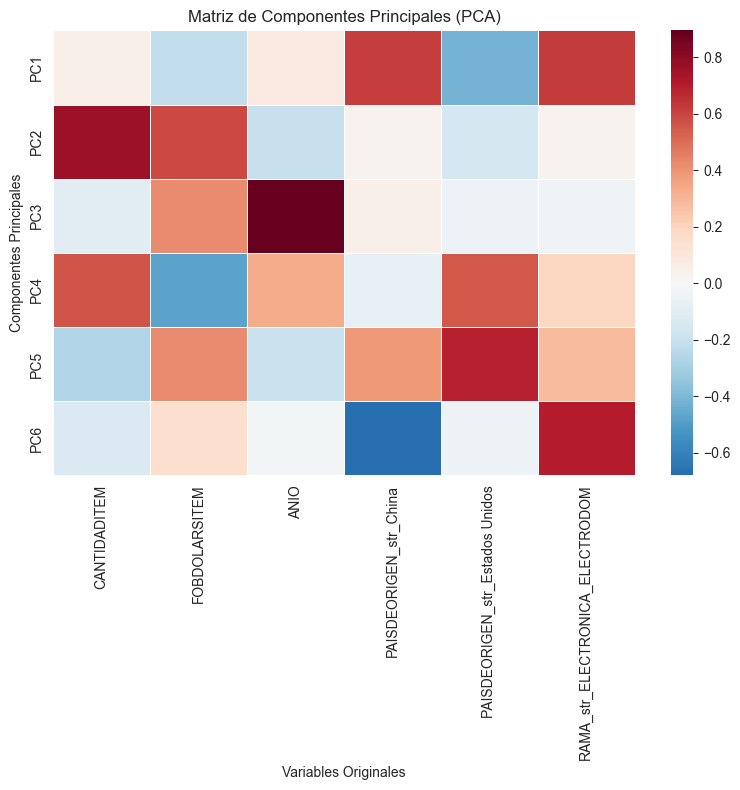


--- VARIANZA EXPLICADA POR COMPONENTE ---

Componente  Varianza Explicada  Varianza Acumulada
       PC1              0.2670              0.2670
       PC2              0.1801              0.4471
       PC3              0.1687              0.6158
       PC4              0.1505              0.7663
       PC5              0.1405              0.9069
       PC6              0.0931              1.0000

--- CARGAS DE LOS COMPONENTES PRINCIPALES ---



,CANTIDADITEM,FOBDOLARSITEM,ANIO,PAISDEORIGEN_str_China,PAISDEORIGEN_str_Estados Unidos,RAMA_str_ELECTRONICA_ELECTRODOM
PC1,0.0554,-0.2207,0.0780,0.6155,-0.4184,0.6232
PC2,0.7651,0.5883,-0.2054,0.0314,-0.1564,0.0300
PC3,-0.0984,0.4258,0.8959,0.0473,-0.0536,-0.0353
PC4,0.5619,-0.4728,0.3312,-0.0757,0.5562,0.1893
PC5,-0.2617,0.4218,-0.1968,0.3869,0.6966,0.2828
PC6,-0.1328,0.1497,-0.0254,-0.6801,-0.0552,0.7026



PC1 - Top 5 variables:
  RAMA_str_ELECTRONICA_ELECTRODOM          +0.623
  PAISDEORIGEN_str_China                   +0.615
  PAISDEORIGEN_str_Estados Unidos          -0.418
  FOBDOLARSITEM                            -0.221
  ANIO                                     +0.078

PC2 - Top 5 variables:
  CANTIDADITEM                             +0.765
  FOBDOLARSITEM                            +0.588
  ANIO                                     -0.205
  PAISDEORIGEN_str_Estados Unidos          -0.156
  PAISDEORIGEN_str_China                   +0.031

PC3 - Top 5 variables:
  ANIO                                     +0.896
  FOBDOLARSITEM                            +0.426
  CANTIDADITEM                             -0.098
  PAISDEORIGEN_str_Estados Unidos          -0.054
  PAISDEORIGEN_str_China                   +0.047

PC4 - Top 5 variables:
  CANTIDADITEM                             +0.562
  PAISDEORIGEN_str_Estados Unidos          +0.556
  FOBDOLARSITEM                            -0.473
  AN

In [51]:
# PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Estandarización
scaler = StandardScaler()
X_std = scaler.fit_transform(X_scaled_df)

# Aplicación de PCA
pca = PCA()
X_pca = pca.fit_transform(X_std)

# DataFrame de componentes
componentes_df = pd.DataFrame(
    pca.components_,
    columns=X_scaled_df.columns,
    index=[f'PC{i+1}' for i in range(len(X_scaled_df.columns))]
)

# DataFrame de varianza explicada
varianza_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Varianza Explicada': pca.explained_variance_ratio_,
    'Varianza Acumulada': np.cumsum(pca.explained_variance_ratio_)
})

# Visualización heatmap de los componentes
plt.figure(figsize=(8, 8))
sns.heatmap(componentes_df, cmap='RdBu_r', center=0, annot=False, linewidths=0.5)
plt.title('Matriz de Componentes Principales (PCA)')
plt.xlabel('Variables Originales')
plt.ylabel('Componentes Principales')
plt.tight_layout()
plt.show()

# Mostrar tablas
print("\n--- VARIANZA EXPLICADA POR COMPONENTE ---\n")
print(varianza_df.to_string(index=False, float_format="%.4f"))

print("\n--- CARGAS DE LOS COMPONENTES PRINCIPALES ---\n")
display(componentes_df.round(4))

for i, comp in enumerate(componentes_df.values):
    top_vars = np.argsort(np.abs(comp))[::-1][:5]
    print(f"\nPC{i+1} - Top 5 variables:")
    for idx in top_vars:
        var = componentes_df.columns[idx]
        carga = comp[idx]
        print(f"  {var:40s} {carga:+.3f}")

| Componente | Descripción sintética | Nombre sugerido | Nombre abreviado |
|------------|----------------------|-----------------|------------------|
| PC1 | Diferencia entre importaciones chinas del sector electrónico y operaciones estadounidenses de mayor valor FOB | Eje China–Electrónica vs. EE.UU.–FOB | PC1_China_Elec |
| PC2 | Contraste entre volumen y valor FOB frente a importaciones desde EE.UU. | Volumen–Valor vs. EE.UU. | PC2_Transacciones |
| PC3 | Tendencia puramente temporal | Componente Temporal | PC3_Tiempo |
| PC4 | Componente mixto con alta cantidad y electrónica desde EE.UU., con menor valor FOB | Electrónica EE.UU. de alto volumen y bajo valor | PC4_USA_Elec_Cant |
| PC5 | Importaciones estadounidenses de alto valor | EE.UU. – Alto Valor FOB | PC5_USA_Altovalor |
| PC6 | Carga específica negativa de China (sin asociación con otras variables) | Componente China específico | PC6_Elec_noChina |



In [52]:
### NOMBREMOS LOS COMPONENTES ENTONCES, QUE VA A SER MUCHO MEJOR LA INTERPRETACIÓN... 

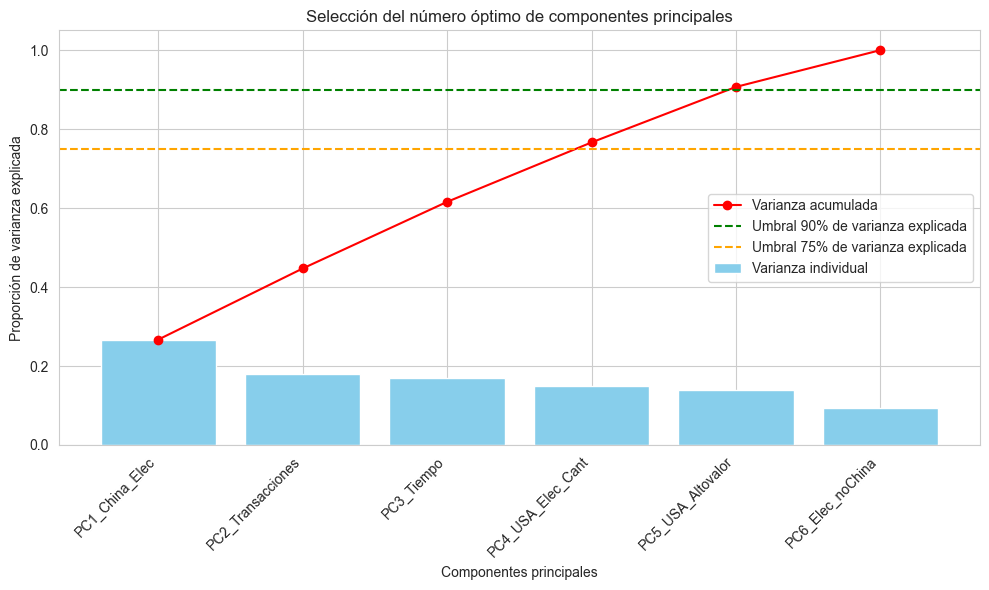


--- VARIANZA EXPLICADA POR COMPONENTE ---

       Componente  Varianza explicada  Varianza acumulada
   PC1_China_Elec              0.2670              0.2670
PC2_Transacciones              0.1801              0.4471
       PC3_Tiempo              0.1687              0.6158
PC4_USA_Elec_Cant              0.1505              0.7663
PC5_USA_Altovalor              0.1405              0.9069
 PC6_Elec_noChina              0.0931              1.0000


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

varianza = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)
x_values = np.arange(1, len(varianza) + 1)
componentes_originales = [f"PC{i}" for i in x_values]

# Diccionario de nuevos nombres
nombres_componentes = {
    'PC1': 'PC1_China_Elec',
    'PC2': 'PC2_Transacciones',
    'PC3': 'PC3_Tiempo',
    'PC4': 'PC4_USA_Elec_Cant',
    'PC5': 'PC5_USA_Altovalor',
    'PC6': 'PC6_Elec_noChina'
}

# Aplicar renombre
componentes_renombrados = [nombres_componentes.get(pc, pc) for pc in componentes_originales]

# Gráfico
plt.figure(figsize=(10, 6))
plt.bar(x_values, varianza, color="skyblue", label="Varianza individual")
plt.plot(x_values, varianza_acumulada, marker="o", color="red", label="Varianza acumulada")
plt.axhline(0.90, color='green', linestyle='--', label='Umbral 90% de varianza explicada')
plt.axhline(0.75, color='orange', linestyle='--', label='Umbral 75% de varianza explicada')
plt.xticks(x_values, componentes_renombrados, rotation=45, ha='right')
plt.xlabel("Componentes principales")
plt.ylabel("Proporción de varianza explicada")
plt.title("Selección del número óptimo de componentes principales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Tabla
tabla_componentes = pd.DataFrame({
    "Componente": componentes_renombrados,
    "Varianza explicada": varianza,
    "Varianza acumulada": varianza_acumulada
})

print("\n--- VARIANZA EXPLICADA POR COMPONENTE ---\n")
print(tabla_componentes.to_string(index=False, float_format="%.4f"))

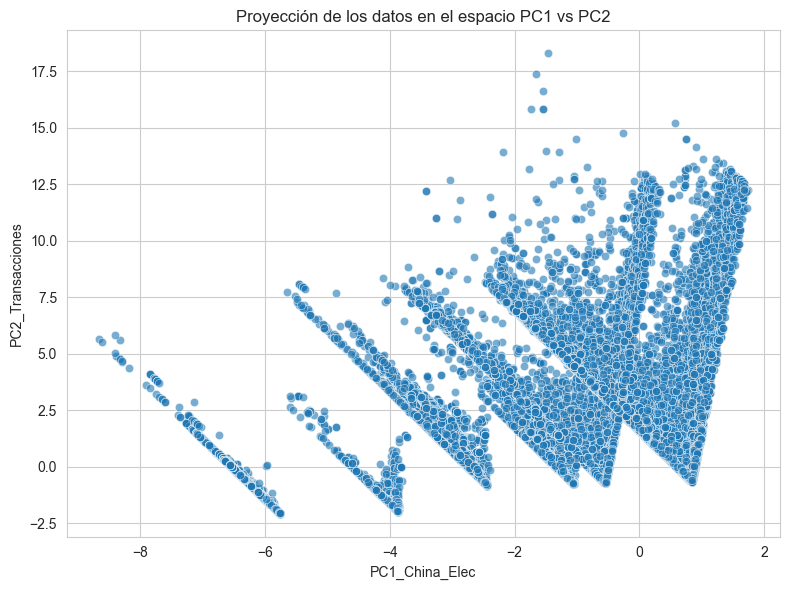

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


# Proyección de los datos en el espacio PCA (4 componentes)
X_pca = pca.transform(X_scaled)

# Visualización 2D: PC1 vs PC2
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], alpha=0.6)
plt.title("Proyección de los datos en el espacio PC1 vs PC2")
plt.xlabel("PC1_China_Elec")
plt.ylabel("PC2_Transacciones")
plt.grid(True)
plt.tight_layout()
plt.show()


#        Componente  Varianza explicada  Varianza acumulada
#    PC1_China_Elec              0.2670              0.2670
# PC2_Transacciones              0.1801              0.4471
#        PC3_Tiempo              0.1687              0.6158
# PC4_USA_Elec_Cant              0.1505              0.7663
# PC5_USA_Altovalor              0.1405              0.9069
#  PC6_Elec_noChina              0.0931              1.0000

In [55]:
import numpy as np
import pandas as pd

# Coordenadas
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

# Condiciones por cuadrante
q1 = (pc1 >= 0) & (pc2 >= 0)  # Importaciones chinas, electrónicas, de gran volumen
q2 = (pc1 <  0) & (pc2 >= 0)  # Transacciones grandes, no chinas
q3 = (pc1 <  0) & (pc2 <  0)  # Operaciones pequeñas, no electrónicas
q4 = (pc1 >= 0) & (pc2 <  0)  # Importaciones pequeñas, electrónicas chinas

# Conteo
total = len(pc1)
conteo = {
    "Q1_Importaciones_chinas_grandes": q1.sum(),
    "Q2_Grandes_no_chinas": q2.sum(),
    "Q3_Pequeñas_no_elec": q3.sum(),
    "Q4_Pequeñas_chinas": q4.sum()
}

# Tabla
tabla = pd.DataFrame({
    "Casos": conteo,
    "Proporción": {k: v / total for k, v in conteo.items()}
})

print("\n--- Distribución por cuadrantes ---\n")
print(tabla.to_string(float_format="%.4f"))


--- Distribución por cuadrantes ---

                                  Casos  Proporción
Q1_Importaciones_chinas_grandes  113117      0.1761
Q2_Grandes_no_chinas              57879      0.0901
Q3_Pequeñas_no_elec              140735      0.2192
Q4_Pequeñas_chinas               330443      0.5146


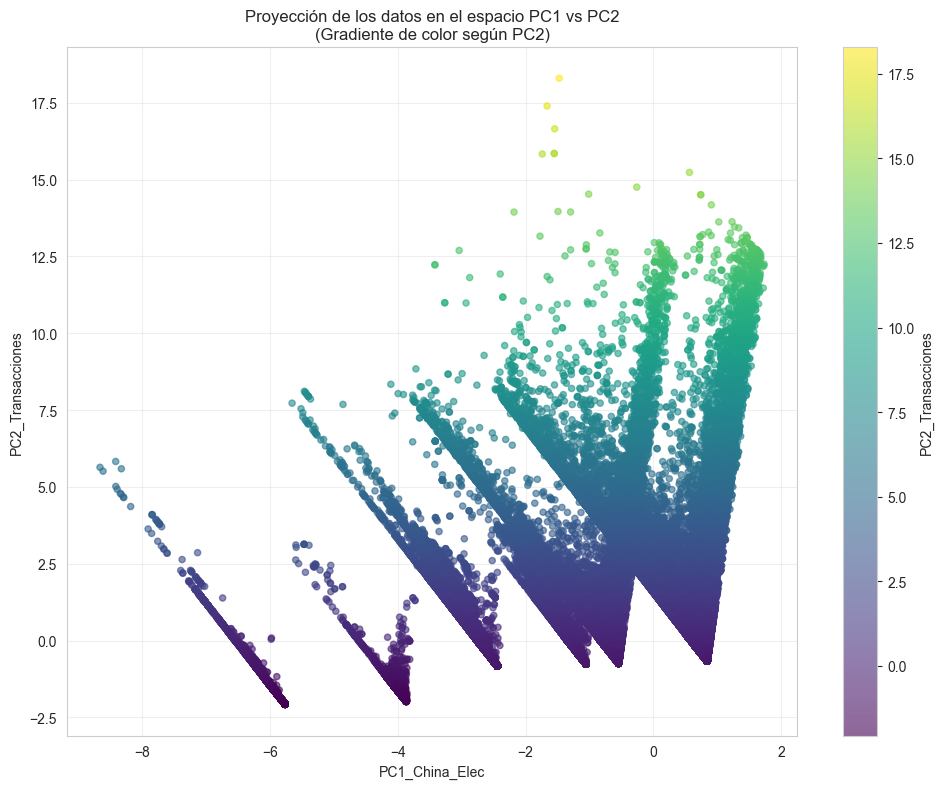

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D


# Proyección de los datos en el espacio PCA (4 componentes)
X_pca = pca.transform(X_scaled)

# Visualización 2D: PC1 vs PC2 con gradiente de color según PC2
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                    c=X_pca[:, 1],  # Color basado en PC2 (eje Y)
                    cmap='viridis',  # Mapa de color
                    alpha=0.6,
                    s=20)  # Tamaño de puntos

plt.colorbar(scatter, label='PC2_Transacciones')
plt.title("Proyección de los datos en el espacio PC1 vs PC2\n(Gradiente de color según PC2)")
plt.xlabel("PC1_China_Elec")
plt.ylabel("PC2_Transacciones")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



### Qué quiere decir? 

- muestra dos trayectorias distintas de crecimiento en transacciones, ambas con fuerte perfil "China + Electrónica", pero probablemente distintas en su composición oculta. 

- Hay dos formas de alcanzar transacciones altas dentro del mismo conjunto estructural:
	- Una más "pura" en términos de las variables originales (100% electrónica, 100% China).
	- Otra "mixta" o con participación parcial de esas variables (ej. electrónica pero no siempre de China, o con participación de otras ramas).

Los gráficos en componentes principales no representan densidad uniforme ni área proporcional al número de observaciones. 

## Reconocer la naturaleza no uniforme del espacio PCA

Los vectores de PCA son combinaciones lineales: una dirección angosta en el gráfico puede coincidir con una alta densidad de puntos por acumulación de categorías frecuentes con poca varianza explicada en otras dimensiones.

Q4 agrupa:
	•	Casos con PC1 > 0 (importaciones chinas, electrónicas)
	•	PC2 < 0 (volumen bajo)

Ese perfil es muy frecuente, pero tiene poca varianza explicada


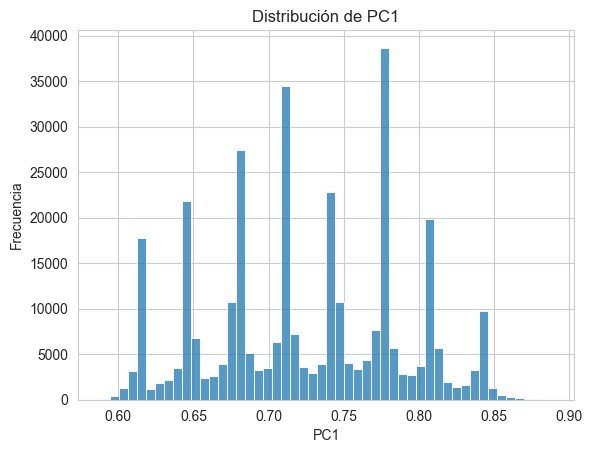

In [57]:
import seaborn as sns

# Definir las condiciones por cuadrante
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]
q4 = (pc1 >= 0) & (pc2 < 0)

sns.histplot(pc1[q4], bins=50)
plt.title("Distribución de PC1")
plt.xlabel("PC1")
plt.ylabel("Frecuencia")
plt.show()

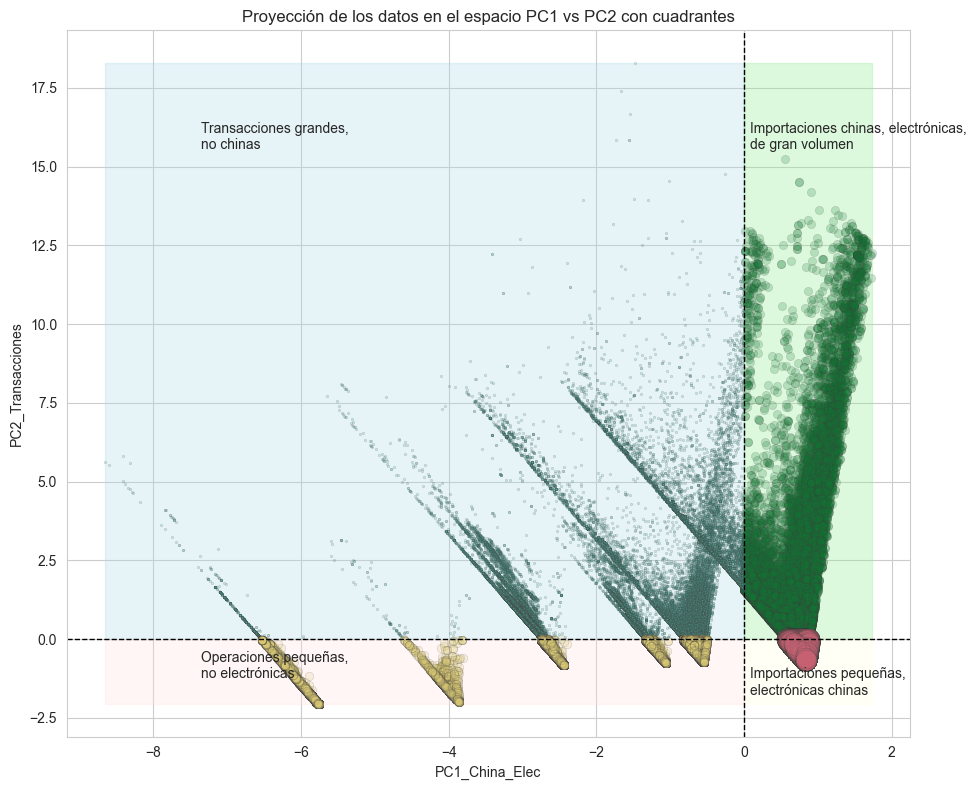

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Coordenadas
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

# Condiciones por cuadrante
q1 = (pc1 >= 0) & (pc2 >= 0)
q2 = (pc1 <  0) & (pc2 >= 0)
q3 = (pc1 <  0) & (pc2 <  0)
q4 = (pc1 >= 0) & (pc2 <  0)

# Proporciones por cuadrante
total = len(pc1)
proporciones = {
    'Q1': q1.sum() / total,
    'Q2': q2.sum() / total,
    'Q3': q3.sum() / total,
    'Q4': q4.sum() / total
}

# Colores por cuadrante
colores = {
    'Q1': '#117733',
    'Q2': '#44aa99',
    'Q3': '#ddcc77',
    'Q4': '#cc6677'
}

# Tamaños por cuadrante según proporciones reales
tamaños = {
    'Q1': 35,
    'Q2': 3,
    'Q3': 36,
    'Q4': 223
}

# Límites del gráfico
x_min, x_max = pc1.min(), pc1.max()
y_min, y_max = pc2.min(), pc2.max()

# Visualización 2D: PC1 vs PC2 con cuadrantes
plt.figure(figsize=(10, 8))

# Fondos por cuadrante
plt.fill_betweenx([0, y_max], x_min, 0, color='lightblue', alpha=0.3)
plt.fill_betweenx([0, y_max], 0, x_max, color='lightgreen', alpha=0.3)
plt.fill_betweenx([y_min, 0], x_min, 0, color='mistyrose', alpha=0.3)
plt.fill_betweenx([y_min, 0], 0, x_max, color='lightyellow', alpha=0.3)

# Puntos por cuadrante con tamaños diferentes
plt.scatter(pc1[q1], pc2[q1], s=tamaños['Q1'], c=colores['Q1'], alpha=0.2, edgecolor='#444444', linewidth=0.5, label='Q1')
plt.scatter(pc1[q2], pc2[q2], s=tamaños['Q2'], c=colores['Q2'], alpha=0.2, edgecolor='#444444', linewidth=0.5, label='Q2')
plt.scatter(pc1[q3], pc2[q3], s=tamaños['Q3'], c=colores['Q3'], alpha=0.2, edgecolor='#444444', linewidth=0.5, label='Q3')
plt.scatter(pc1[q4], pc2[q4], s=tamaños['Q4'], c=colores['Q4'], alpha=0.2, edgecolor='#444444', linewidth=0.5, label='Q4')

# Ejes
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)

# Descripciones por cuadrante
plt.text(x_max * 0.05, y_max * 0.85, "Importaciones chinas, electrónicas,\nde gran volumen", fontsize=10)
plt.text(x_min * 0.85, y_max * 0.85, "Transacciones grandes,\nno chinas", fontsize=10)
plt.text(x_min * 0.85, y_min * 0.6, "Operaciones pequeñas,\nno electrónicas", fontsize=10)
plt.text(x_max * 0.05, y_min * 0.85, "Importaciones pequeñas,\nelectrónicas chinas", fontsize=10)

plt.title("Proyección de los datos en el espacio PC1 vs PC2 con cuadrantes")
plt.xlabel("PC1_China_Elec")
plt.ylabel("PC2_Transacciones")
plt.grid(True)
plt.tight_layout()
plt.show()

... combinamos todo

/var/folders/31/kljct32n3b1c4knmv5502w140000gn/T/ipykernel_25983/1439613199.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(pad=1.0)


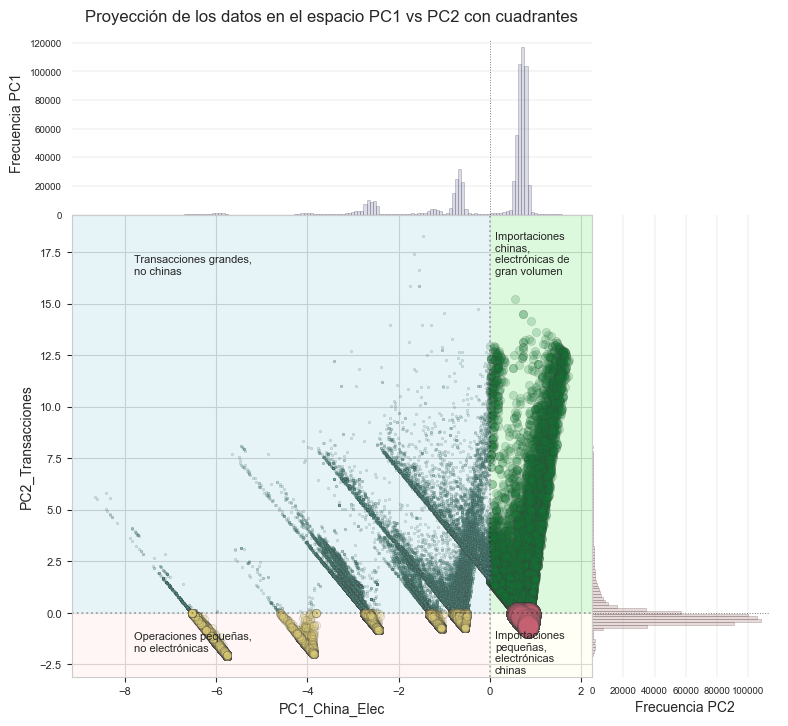

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Coordenadas
pc1 = X_pca[:, 0]
pc2 = X_pca[:, 1]

# Condiciones por cuadrante
q1 = (pc1 >= 0) & (pc2 >= 0)
q2 = (pc1 <  0) & (pc2 >= 0)
q3 = (pc1 <  0) & (pc2 <  0)
q4 = (pc1 >= 0) & (pc2 <  0)

# Proporciones por cuadrante
total = len(pc1)
proporciones = {
    'Q1': q1.sum() / total,
    'Q2': q2.sum() / total,
    'Q3': q3.sum() / total,
    'Q4': q4.sum() / total
}

# Colores por cuadrante
colores = {
    'Q1': '#117733',
    'Q2': '#44aa99',
    'Q3': '#ddcc77',
    'Q4': '#cc6677'
}

# Tamaños por cuadrante
tamaños = {
    'Q1': 35,
    'Q2': 3,
    'Q3': 36,
    'Q4': 223
}

# Límites
x_min, x_max = pc1.min(), pc1.max()
y_min, y_max = pc2.min(), pc2.max()

# Expansión
extra_x = 0.05 * (x_max - x_min)
extra_y = 0.05 * (y_max - y_min)
xlim = (x_min - extra_x, x_max + extra_x)
ylim = (y_min - extra_y, y_max + extra_y)

# Figura y grid
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(25, 25, hspace=0.0, wspace=0.0)

# Scatter principal
ax_main = fig.add_subplot(gs[8:23, 6:20])
ax_main.set_xlim(xlim)
ax_main.set_ylim(ylim)

# Fondos por cuadrante
ax_main.fill_betweenx([0, ylim[1]], 0, xlim[1], facecolor='lightgreen', alpha=0.3)
ax_main.fill_betweenx([0, ylim[1]], xlim[0], 0, facecolor='lightblue', alpha=0.3)
ax_main.fill_betweenx([ylim[0], 0], xlim[0], 0, facecolor='mistyrose', alpha=0.3)
ax_main.fill_betweenx([ylim[0], 0], 0, xlim[1], facecolor='lightyellow', alpha=0.3)

# Puntos
ax_main.scatter(pc1[q1], pc2[q1], s=tamaños['Q1'], c=colores['Q1'], alpha=0.2, edgecolor='#444444', linewidth=0.5)
ax_main.scatter(pc1[q2], pc2[q2], s=tamaños['Q2'], c=colores['Q2'], alpha=0.2, edgecolor='#444444', linewidth=0.5)
ax_main.scatter(pc1[q3], pc2[q3], s=tamaños['Q3'], c=colores['Q3'], alpha=0.2, edgecolor='#444444', linewidth=0.5)
ax_main.scatter(pc1[q4], pc2[q4], s=tamaños['Q4'], c=colores['Q4'], alpha=0.2, edgecolor='#444444', linewidth=0.5)

# Ejes centrales
ax_main.axhline(0, color='black', linestyle=':', linewidth=1.3, alpha=0.3)
ax_main.axvline(0, color='black', linestyle=':', linewidth=1.3, alpha=0.3)

# Etiquetas
ax_main.text(xlim[1]*0.05, ylim[1]*0.85, "Importaciones \nchinas, \nelectrónicas de \ngran volumen", fontsize=8)
ax_main.text(xlim[0]*0.85, ylim[1]*0.85, "Transacciones grandes,\nno chinas", fontsize=8)
ax_main.text(xlim[0]*0.85, ylim[0]*0.6, "Operaciones pequeñas,\nno electrónicas", fontsize=8)
ax_main.text(xlim[1]*0.05, ylim[0]*0.95, "Importaciones \npequeñas,\nelectrónicas \nchinas", fontsize=8)

ax_main.set_xlabel("PC1_China_Elec")
ax_main.set_ylabel("PC2_Transacciones")
ax_main.grid(True)
ax_main.tick_params(axis='both', which='both', bottom=True, left=True, top=False, right=False)
ax_main.tick_params(axis='x', which='major', labelsize=8)
ax_main.tick_params(axis='y', which='major', labelsize=8)

# Histograma superior
ax_hist_x = fig.add_subplot(gs[2:8, 6:20], sharex=ax_main)
n_x, bins_x, _ = ax_hist_x.hist(pc1, bins=150, alpha=0.3, color='#8888aa', edgecolor='#444466', linewidth=0.6)
centers_x = 0.5 * (bins_x[1:] + bins_x[:-1])
ax_hist_x.set_ylim(0, max(n_x) * 1.1)
ax_hist_x.set_ylabel('Frecuencia PC1')
ax_hist_x.set_title("Proyección de los datos en el espacio PC1 vs PC2 con cuadrantes")
ax_hist_x.grid(True, axis='y', alpha=0.3, color='#444444', linewidth=0.25)
ax_hist_x.grid(True, axis='x', alpha=0.3, color='none', linewidth=0.5)
ax_hist_x.spines['top'].set_visible(False)
ax_hist_x.spines['right'].set_visible(False)
ax_hist_x.spines['left'].set_visible(False)
ax_hist_x.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False, labelsize=8)
ax_hist_x.tick_params(axis='y', which='both', labelsize=7)
ax_hist_x.axvline(0, color='black', linestyle=':', linewidth=0.7, ymin=-0.5, ymax=0.95, alpha=0.5)

# Histograma lateral
ax_hist_y = fig.add_subplot(gs[8:23, 20:25], sharey=ax_main)
n_y, bins_y, _ = ax_hist_y.hist(pc2, bins=150, orientation='horizontal', alpha=0.3, color='#aa8888', edgecolor='#664444', linewidth=0.6)
centers_y = 0.5 * (bins_y[1:] + bins_y[:-1])
ax_hist_y.set_xlim(0, max(n_y) * 1.1)
ax_hist_y.set_xlabel('Frecuencia PC2')
ax_hist_y.grid(True, axis='x', alpha=0.3, color='#444444', linewidth=0.25)
ax_hist_y.grid(True, axis='y', alpha=0.3, color='none', linewidth=0.5)
ax_hist_y.spines['top'].set_visible(False)
ax_hist_y.spines['right'].set_visible(False)
ax_hist_y.spines['bottom'].set_visible(False)
ax_hist_y.tick_params(axis='y', which='both', left=False, right=False, labelleft=False, labelsize=8)
ax_hist_y.tick_params(axis='x', which='both', labelsize=7)
ax_hist_y.axhline(0, color='black', linestyle=':', linewidth=0.7, xmin=0, xmax=0.95, alpha=0.5)

# Cuadro vacío
ax_empty = fig.add_subplot(gs[2:8, 20:25])
ax_empty.set_visible(False)

plt.tight_layout(pad=1.0)
plt.show()

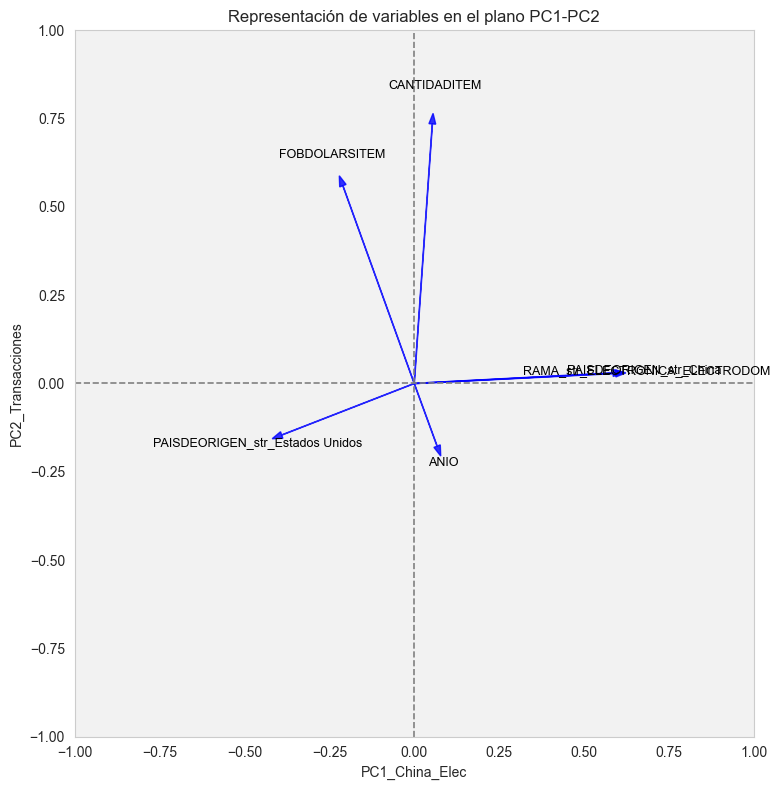

In [60]:
import matplotlib.pyplot as plt
import numpy as np

# Obtener componentes del PCA
componentes = pca.components_
nombres = X.columns
ejes_x = "PC1_China_Elec"
ejes_y = "PC2_Transacciones"

# Primeras dos componentes
pc1 = componentes[0]
pc2 = componentes[1]

# Crear el gráfico
plt.figure(figsize=(8, 8))
for i in range(len(nombres)):
    plt.arrow(0, 0, pc1[i], pc2[i], color='blue', alpha=0.8, head_width=0.02, length_includes_head=True)
    plt.text(pc1[i]*1.1, pc2[i]*1.1, nombres[i], color='black', ha='center', va='center', fontsize=9)

# Estética del gráfico
plt.axhline(0, color='gray', linestyle='--', linewidth=1.2)
plt.axvline(0, color='gray', linestyle='--', linewidth=1.2)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel(ejes_x)
plt.ylabel(ejes_y)
plt.title("Representación de variables en el plano PC1-PC2")
plt.grid(False)
plt.gca().set_facecolor('#f2f2f2')
plt.tight_layout()
plt.show()

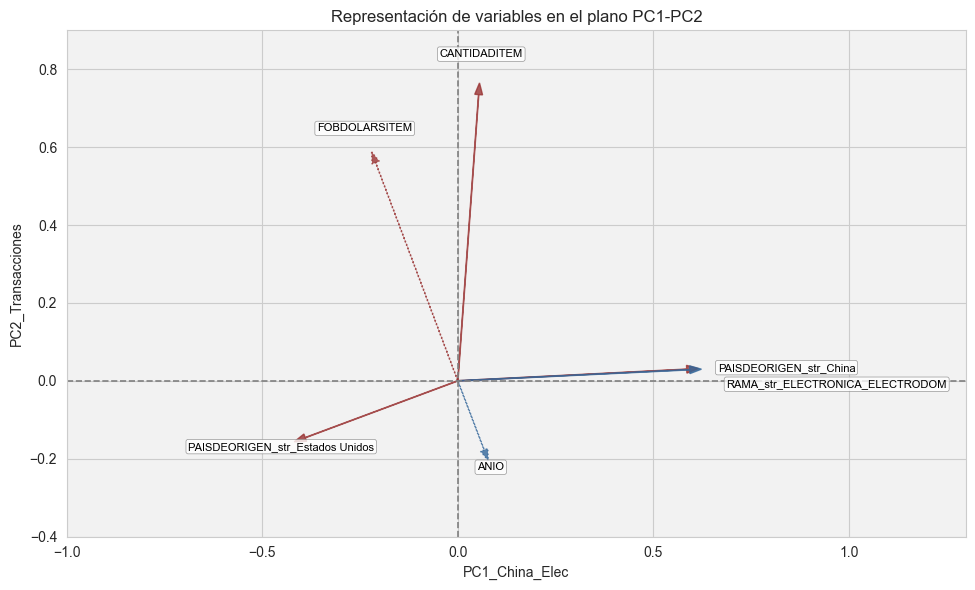

In [61]:
import matplotlib.pyplot as plt
import numpy as np

componentes = pca.components_
nombres = X.columns
pc1 = componentes[0]
pc2 = componentes[1]
ejes_x = "PC1_China_Elec"
ejes_y = "PC2_Transacciones"

umbral_opuesto = -0.9
umbral_ortogonal = 0.1

def cos_angulo(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

plt.figure(figsize=(10, 6))
ax = plt.gca()
etiquetas_pos = []

for i in range(len(nombres)):
    v = np.array([pc1[i], pc2[i]])
    color = '#336699'
    linestyle = 'solid'
    
    for j in range(i+1, len(nombres)):
        v2 = np.array([pc1[j], pc2[j]])
        cos_ang = cos_angulo(v, v2)
        if cos_ang < umbral_opuesto:
            color = '#993333'
        elif abs(cos_ang) < umbral_ortogonal:
            linestyle = 'dotted'
    
    ax.arrow(0, 0, v[0], v[1], color=color, alpha=0.8,
            head_width=0.02, length_includes_head=True, linestyle=linestyle)
    text_x = v[0] * 1.08
    text_y = v[1] * 1.08
    
    if abs(v[0]) > 0.5:
        ha = 'left' if v[0] > 0 else 'right'
    else:
        ha = 'center'
    
    if abs(v[1]) > 0.5:
        va = 'bottom' if v[1] > 0 else 'top'
    else:
        va = 'center'
    
    def posicion_ocupada(x, y, posiciones_existentes, radio=0.1):
        for px, py in posiciones_existentes:
            if np.sqrt((x - px)**2 + (y - py)**2) < radio:
                return True
        return False
    
    offset_base = 0.02
    max_intentos = 8
    intentos = 0
    
    while posicion_ocupada(text_x, text_y, etiquetas_pos) and intentos < max_intentos:
        angulo = intentos * np.pi / 4
        offset_x = offset_base * np.cos(angulo)
        offset_y = offset_base * np.sin(angulo)
        text_x = v[0] * 1.08 + offset_x
        text_y = v[1] * 0.18 + offset_y
        intentos += 1
    
    etiquetas_pos.append((text_x, text_y))
    ax.text(text_x, text_y, nombres[i], color='black', ha=ha, va=va, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='gray', linewidth=0.5))

ax.axhline(0, color='gray', linestyle='--', linewidth=1.2)
ax.axvline(0, color='gray', linestyle='--', linewidth=1.2)
ax.set_xlim(-1.0, 1.3)
ax.set_ylim(-0.4, 0.9)
ax.set_facecolor('#f2f2f2')
ax.set_xlabel(ejes_x)
ax.set_ylabel(ejes_y)
ax.set_title("Representación de variables en el plano PC1-PC2")
plt.tight_layout()
plt.show()

1. Variables alineadas con PC1 (eje horizontal):
	•	PAISDEORIGEN_str_China, CATEGORIA_ELECTRODOM y RAMA_DESC están proyectadas en la misma dirección positiva sobre PC1.
	•	Estas variables explican fuertemente la varianza a lo largo de PC1, asociada a importaciones chinas y electrónicas.
	•	PAISDEORIGEN_str_Estados Unidos se ubica en dirección contraria (negativa), lo que indica una oposición estructural a las importaciones chinas/electrónicas.
	•	Hay una relación antagónica entre importaciones desde EE.UU. y las electrónicas chinas.

2. Variables alineadas con PC2 (eje vertical):
	•	CANTIDADITEM y FOBDOLARSITEM están proyectadas hacia el extremo superior.
	•	Indican una alta contribución a la componente PC2, asociada a transacciones de gran volumen (en cantidad y valor).
	•	ANIO aparece proyectada en la dirección opuesta, con poca magnitud.
	•	Esto sugiere que el año no aporta significativamente al eje de volumen de transacciones, y en todo caso tiene una correlación negativa débil.


    	•	PAISDEORIGEN_str_China y RAMA_str_ELECTRONICA_ELECTRODOM están muy alineadas: en esta proyección, casi colineales, lo que indica que suelen activarse juntas en los datos.
Pero, como vimos antes, no son redundantes porque en el espacio tridimensional se distinguen (PC3 separa).
	•	PAISDEORIGEN_str_Estados Unidos y CANTIDADITEM forman un ángulo amplio: transacciones de EE.UU. son distintas de las de alto volumen, probablemente más costosas pero menos frecuentes.


     las operaciones más recientes (mayores valores de año) tienden a tener menor peso en la dimensión de volumen económico.


     Es decir, con el paso del tiempo, hay una disminución en la magnitud de las operaciones (en términos de cantidad o monto FOB), o bien, los años recientes están más asociados a operaciones pequeñas

A medida que pasan los años (ANIO más reciente), las operaciones tienden a ser más numerosas pero de menor monto unitario por transacción.

	•	Mayor frecuencia de operaciones.
	•	Menor peso individual de cada transacción.
	•	Esto puede indicar:
	•	Cambios en los proveedores o logística.
	•	Nuevas prácticas contables o aduaneras.
	•	Desagregación técnica más fina (importar más ítems separados por código).
	•	Aceleración de la rotación o del ensamblaje just-in-time.


    



In [62]:
import numpy as np
import pandas as pd

componentes = pca.components_
nombres = X.columns
pc1 = componentes[0]
pc2 = componentes[1]
varianza_pc1 = pca.explained_variance_ratio_[0]
varianza_pc2 = pca.explained_variance_ratio_[1]

# Varianza explicada por el plano PC1-PC2
varianza_total = round(varianza_pc1 + varianza_pc2, 4)
print(f"Varianza explicada por el plano PC1-PC2: {varianza_total:.2%}")

umbral_opuesto = -0.9
umbral_ortogonal = 0.1

def cos_angulo(v1, v2):
    return np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))

# Calcular relaciones entre variables
resultados = []
for i in range(len(nombres)):
    v1 = np.array([pc1[i], pc2[i]])
    mag1 = np.linalg.norm(v1)
    c1_pc1 = round(pc1[i] ** 2, 3)
    c1_pc2 = round(pc2[i] ** 2, 3)
    total1 = round(varianza_pc1 * c1_pc1 + varianza_pc2 * c1_pc2, 4)

    for j in range(i + 1, len(nombres)):
        v2 = np.array([pc1[j], pc2[j]])
        mag2 = np.linalg.norm(v2)
        cos_ang = cos_angulo(v1, v2)
        mag_prom = round((mag1 + mag2) / 2, 3)

        if cos_ang < umbral_opuesto:
            relacion = "opuestos"
        elif abs(cos_ang) < umbral_ortogonal:
            relacion = "ortogonales"
        else:
            relacion = "otro"

        resultados.append({
            "Variable_1": nombres[i],
            "Variable_2": nombres[j],
            "Coseno": round(cos_ang, 3),
            "Relacion": relacion,
            "Magnitud_promedio": mag_prom,
            "Contrib_PC1": c1_pc1,
            "Contrib_PC2": c1_pc2,
            "Total_ponderada": total1
        })

df_relaciones = pd.DataFrame(resultados)
df_relaciones.to_csv("tabla_relaciones_vectores_completa.csv", index=False)
display(df_relaciones)

Varianza explicada por el plano PC1-PC2: 44.71%


,Variable_1,Variable_2,Coseno,Relacion,Magnitud_promedio,Contrib_PC1,Contrib_PC2,Total_ponderada
0,CANTIDADITEM,FOBDOLARSITEM,0.9080,otro,0.6980,0.0030,0.5850,0.1062
1,CANTIDADITEM,ANIO,-0.9070,opuestos,0.4930,0.0030,0.5850,0.1062
2,CANTIDADITEM,PAISDEORIGEN_str_China,0.1230,otro,0.6920,0.0030,0.5850,0.1062
3,CANTIDADITEM,PAISDEORIGEN_str_Estados Unidos,-0.4170,otro,0.6070,0.0030,0.5850,0.1062
4,CANTIDADITEM,RAMA_str_ELECTRONICA_ELECTRODOM,0.1200,otro,0.6950,0.0030,0.5850,0.1062
5,FOBDOLARSITEM,ANIO,-1.0000,opuestos,0.4240,0.0490,0.3460,0.0754
6,FOBDOLARSITEM,PAISDEORIGEN_str_China,-0.3030,otro,0.6220,0.0490,0.3460,0.0754
7,FOBDOLARSITEM,PAISDEORIGEN_str_Estados Unidos,0.0010,ortogonales,0.5370,0.0490,0.3460,0.0754
8,FOBDOLARSITEM,RAMA_str_ELECTRONICA_ELECTRODOM,-0.3060,otro,0.6260,0.0490,0.3460,0.0754
9,ANIO,PAISDEORIGEN_str_China,0.3070,otro,0.4180,0.0060,0.0420,0.0092


## Agreguemos una dimensión más 

- Si bien se complica un poco la visualización, pueden emerger cosas interesantes.
- La idea, como siempre, es buscar identificar visualmente la emergencia de patrones no triviales o latentes.  

In [63]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from ipywidgets import interact, FloatSlider, VBox, HBox
import ipywidgets as widgets


componentes = pca.components_
nombres = X.columns
ejes_x = "PC1_China_Elec"
ejes_y = "PC2_Transacciones"
ejes_z = "PC6_Elec_noChina"

# Componentes seleccionadas
pc1 = componentes[0]  # PC1
pc2 = componentes[1]  # PC2
pc6 = componentes[5]  # PC6

# Calcular valores de PC2 para el gradiente de color usando RdBu
norm_pc2 = (pc2 - pc2.min()) / (pc2.max() - pc2.min())
colors = plt.cm.RdBu(norm_pc2)

def plot_3d_components(elev=20, azim=45):
    """Función para crear el gráfico 3D con ángulos configurables"""
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Dibujar las flechas de las variables
    for i in range(len(nombres)):
        color = colors[i]
        ax.quiver(0, 0, 0, pc1[i], pc2[i], pc6[i], 
                    color=color, alpha=0.8, arrow_length_ratio=0.05, linewidth=2)
        ax.text(pc1[i]*1.1, pc2[i]*1.1, pc6[i]*1.1, nombres[i], 
                color='black', fontsize=9, ha='center', va='center')
    
    # Configurar vista
    ax.view_init(elev=elev, azim=azim)
    
    # Ejes
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_xlabel(ejes_x)
    ax.set_ylabel(ejes_y)
    ax.set_zlabel(ejes_z)
    ax.set_title("Representación de variables en el espacio PC1-PC2-PC6\n(Colores indican expansión en PC2)")
    
    # Agregar barra de color para mostrar la escala de PC2
    scatter = ax.scatter([], [], [], c=[], cmap='RdBu')
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, aspect=20)
    cbar.set_label('Expansión en PC2 (normalizada)')
    
    plt.tight_layout()
    plt.show()

# Crear widgets interactivos
elev_slider = FloatSlider(
    value=20,
    min=0,
    max=90,
    step=1,
    description='Elevación:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

azim_slider = FloatSlider(
    value=45,
    min=0,
    max=360,
    step=1,
    description='Azimut:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

# Crear interfaz interactiva
interact(plot_3d_components, elev=elev_slider, azim=azim_slider)

#azimut 270, elevación 81

interactive(children=(FloatSlider(value=20.0, description='Elevación:', layout=Layout(width='400px'), max=90.0…

<function __main__.plot_3d_components(elev=20, azim=45)>

In [64]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from ipywidgets import interact, FloatSlider, VBox, HBox
import ipywidgets as widgets


componentes = pca.components_
nombres = X.columns
ejes_x = "PC1_China_Elec"
ejes_y = "PC2_Transacciones"
ejes_z = "PC3_Tiempo"

# Componentes seleccionadas
pc1 = componentes[0]  # PC1
pc2 = componentes[1]  # PC2
pc3 = componentes[2]  # PC3

# Calcular valores de PC2 para el gradiente de color usando RdBu
norm_pc2 = (pc2 - pc2.min()) / (pc2.max() - pc2.min())
colors = plt.cm.RdBu(norm_pc2)

def plot_3d_components(elev=20, azim=45):
    """Función para crear el gráfico 3D con ángulos configurables"""
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Dibujar las flechas de las variables
    for i in range(len(nombres)):
        color = colors[i]
        ax.quiver(0, 0, 0, pc1[i], pc2[i], pc3[i], 
                    color=color, alpha=0.8, arrow_length_ratio=0.05, linewidth=2)
        ax.text(pc1[i]*1.1, pc2[i]*1.1, pc3[i]*1.1, nombres[i], 
                color='black', fontsize=9, ha='center', va='center')
    
    # Configurar vista
    ax.view_init(elev=elev, azim=azim)
    
    # Ejes
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_zlim([-1, 1])
    ax.set_xlabel(ejes_x)
    ax.set_ylabel(ejes_y)
    ax.set_zlabel(ejes_z)
    ax.set_title("Representación de variables en el espacio PC1-PC2-PC3\n(Colores indican expansión en PC2)")
    
    # Agregar barra de color para mostrar la escala de PC2
    scatter = ax.scatter([], [], [], c=[], cmap='RdBu')
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6, aspect=20)
    cbar.set_label('Expansión en PC2 (normalizada)')
    
    plt.tight_layout()
    plt.show()

# Crear widgets interactivos
elev_slider = FloatSlider(
    value=20,
    min=0,
    max=90,
    step=1,
    description='Elevación:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

azim_slider = FloatSlider(
    value=45,
    min=0,
    max=360,
    step=1,
    description='Azimut:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

# Crear interfaz interactiva
interact(plot_3d_components, elev=elev_slider, azim=azim_slider)

#azimut 270, elevación 81

interactive(children=(FloatSlider(value=20.0, description='Elevación:', layout=Layout(width='400px'), max=90.0…

<function __main__.plot_3d_components(elev=20, azim=45)>

In [65]:

import numpy as np
import pandas as pd
from itertools import combinations

def analizar_cuadrantes(pc_a, pc_b, nombre_a, nombre_b, interpretacion_a, interpretacion_b):
    """Analiza la distribución por cuadrantes de dos componentes principales"""
    q1 = (pc_a >= 0) & (pc_b >= 0)
    q2 = (pc_a <  0) & (pc_b >= 0)
    q3 = (pc_a <  0) & (pc_b <  0)
    q4 = (pc_a >= 0) & (pc_b <  0)
    
    total = len(pc_a)
    
    # Nombres interpretables de cuadrantes con paréntesis
    cuadrantes = {
        "Q1": f"Q1: {interpretacion_a} (+) {interpretacion_b} (+)",
        "Q2": f"Q2: {interpretacion_a} (-) {interpretacion_b} (+)",
        "Q3": f"Q3: {interpretacion_a} (-) {interpretacion_b} (-)",
        "Q4": f"Q4: {interpretacion_a} (+) {interpretacion_b} (-)"
    }
    
    conteo = {
        cuadrantes["Q1"]: q1.sum(),
        cuadrantes["Q2"]: q2.sum(),
        cuadrantes["Q3"]: q3.sum(),
        cuadrantes["Q4"]: q4.sum()
    }
    
    return pd.DataFrame({
        "Casos": conteo,
        "Proporción": {k: v / total for k, v in conteo.items()}
    })

# Nombres de componentes
nombres_pc = {
    0: "PC1_China_Elec",
    1: "PC2_Transacciones", 
    2: "PC3_Tiempo",
    3: "PC4_USA_Elec_Cant",
    4: "PC5_USA_Altovalor",
    5: "PC6_Elec_noChina"
}

# Interpretaciones de cada componente
interpretaciones_pc = {
    0: "China/Electrónica",
    1: "Volumen Transacciones", 
    2: "Evolución Temporal",
    3: "USA/Cantidad",
    4: "USA/Alto Valor",
    5: "Electrónica no-China"
}

# Extraer todas las componentes
componentes = [X_pca[:, i] for i in range(6)]

# Generar todas las combinaciones de 2 componentes
combinaciones = list(combinations(range(6), 2))

print("=== ANÁLISIS SISTEMÁTICO DE CUADRANTES ===\n")

# Diccionario de interpretaciones para cada combinación
interpretaciones = {
    "PC1 vs PC2": "Separación entre importaciones chinas/electrónicas vs volumen de transacciones",
    "PC1 vs PC3": "Contraste entre origen/rama vs evolución temporal",
    "PC1 vs PC4": "China/Electrónica vs USA/Cantidad",
    "PC1 vs PC5": "China/Electrónica vs USA/Alto valor",
    "PC1 vs PC6": "China/Electrónica vs Electrónica no-China",
    "PC2 vs PC3": "Volumen vs Tiempo",
    "PC2 vs PC4": "Transacciones vs USA/Cantidad",
    "PC2 vs PC5": "Volumen vs Alto valor",
    "PC2 vs PC6": "Transacciones vs Electrónica no-China",
    "PC3 vs PC4": "Tiempo vs USA/Cantidad",
    "PC3 vs PC5": "Tiempo vs Alto valor",
    "PC3 vs PC6": "Tiempo vs Electrónica no-China",
    "PC4 vs PC5": "USA/Cantidad vs USA/Alto valor",
    "PC4 vs PC6": "USA/Cantidad vs Electrónica no-China",
    "PC5 vs PC6": "USA/Alto valor vs Electrónica no-China"
}

for i, (pc_idx1, pc_idx2) in enumerate(combinaciones):
    print(f"--- {nombres_pc[pc_idx1]} vs {nombres_pc[pc_idx2]} ---")
    tabla = analizar_cuadrantes(
        componentes[pc_idx1], 
        componentes[pc_idx2],
        nombres_pc[pc_idx1].split('_')[0],
        nombres_pc[pc_idx2].split('_')[0],
        interpretaciones_pc[pc_idx1],
        interpretaciones_pc[pc_idx2]
    )
    print(tabla.to_string(float_format="%.4f"))
    
    # Mostrar interpretación debajo de cada tabla
    combo_key = f"PC{pc_idx1+1} vs PC{pc_idx2+1}"
    if combo_key in interpretaciones:
        print(f"\nInterpretación: {interpretaciones[combo_key]}")
        print("\n")
        print("--"*30)
    print()


=== ANÁLISIS SISTEMÁTICO DE CUADRANTES ===

--- PC1_China_Elec vs PC2_Transacciones ---
                                                      Casos  Proporción
Q1: China/Electrónica (+) Volumen Transacciones (+)  113117      0.1761
Q2: China/Electrónica (-) Volumen Transacciones (+)   57879      0.0901
Q3: China/Electrónica (-) Volumen Transacciones (-)  140735      0.2192
Q4: China/Electrónica (+) Volumen Transacciones (-)  330443      0.5146

Interpretación: Separación entre importaciones chinas/electrónicas vs volumen de transacciones


------------------------------------------------------------

--- PC1_China_Elec vs PC3_Tiempo ---
                                                   Casos  Proporción
Q1: China/Electrónica (+) Evolución Temporal (+)  207333      0.3229
Q2: China/Electrónica (-) Evolución Temporal (+)   94840      0.1477
Q3: China/Electrónica (-) Evolución Temporal (-)  103774      0.1616
Q4: China/Electrónica (+) Evolución Temporal (-)  236227      0.3679

Interpret

In [66]:
#python: ejemplito de función compuesta (varias funciones simples hacen una función maestra)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from IPython.display import display

# Configuración de nombres e interpretaciones
nombres_componentes = {
    'PC1': 'PC1_China_Elec',
    'PC2': 'PC2_Transacciones',
    'PC3': 'PC3_Tiempo',
    'PC4': 'PC4_USA_Elec_Cant',
    'PC5': 'PC5_USA_Altovalor',
    'PC6': 'PC6_Elec_noChina'
}

interpretaciones_pc = {
    0: "China/Electrónica",
    1: "Volumen Transacciones",
    2: "Evolución Temporal",
    3: "USA/Cantidad",
    4: "USA/Alto Valor",
    5: "Electrónica no-China"
}

# Funciones principales
def ajustar_pca(X_scaled_df):
    scaler = StandardScaler()
    X_std = scaler.fit_transform(X_scaled_df)
    pca = PCA()
    X_pca = pca.fit_transform(X_std)
    
    # Guardar resultados en parquet
    pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
    pca_df.to_parquet('pca_results.parquet', index=False)
    
    return pca, X_pca

def tabla_varianza(pca):
    varianza = pca.explained_variance_ratio_
    var_acum = np.cumsum(varianza)
    indices = [f'PC{i+1}' for i in range(len(varianza))]
    comp_renombrados = [nombres_componentes.get(pc, pc) for pc in indices]
    df = pd.DataFrame({
        'Componente': comp_renombrados,
        'Varianza Explicada': varianza,
        'Varianza Acumulada': var_acum
    })
    return df

def tabla_cargas(pca, columnas):
    df = pd.DataFrame(
        pca.components_,
        columns=columnas,
        index=[f'PC{i+1}' for i in range(len(columnas))]
    )
    return df

def imprimir_top_variables(componentes_df, top_n=5):
    for i, comp in enumerate(componentes_df.values):
        top_vars = np.argsort(np.abs(comp))[::-1][:top_n]
        print(f"\nPC{i+1} - Top {top_n} variables:")
        for idx in top_vars:
            var = componentes_df.columns[idx]
            carga = comp[idx]
            print(f"  {var:40s} {carga:+.3f}")

def analizar_cuadrantes(pc_a, pc_b, nombre_a, nombre_b, interpretacion_a, interpretacion_b):
    q1 = (pc_a >= 0) & (pc_b >= 0)
    q2 = (pc_a <  0) & (pc_b >= 0)
    q3 = (pc_a <  0) & (pc_b <  0)
    q4 = (pc_a >= 0) & (pc_b <  0)
    total = len(pc_a)
    cuadrantes = {
        f"Q1_{nombre_a}+_{nombre_b}+": f"{interpretacion_a} + {interpretacion_b}",
        f"Q2_{nombre_a}-_{nombre_b}+": f"{interpretacion_a} - {interpretacion_b}",
        f"Q3_{nombre_a}-_{nombre_b}-": f"{interpretacion_a} - {interpretacion_b} -",
        f"Q4_{nombre_a}+_{nombre_b}-": f"{interpretacion_a} + {interpretacion_b} -"
    }
    conteo = {
        k: v.sum() for k, v in zip(cuadrantes.keys(), [q1, q2, q3, q4])
    }
    tabla = pd.DataFrame({
        'Casos': conteo,
        'Proporción': {k: v/total for k, v in conteo.items()}
    })
    return tabla

def analisis_sistematico_cuadrantes(X_pca):
    componentes = [X_pca[:, i] for i in range(6)]
    combinaciones = list(combinations(range(6), 2))

    filas = []
    datos = []

    for pc_idx1, pc_idx2 in combinaciones:
        nombre_pc1 = f"PC{pc_idx1+1}"
        nombre_pc2 = f"PC{pc_idx2+1}"
        descripcion1 = nombres_componentes.get(nombre_pc1)
        descripcion2 = nombres_componentes.get(nombre_pc2)

        pc_a = componentes[pc_idx1]
        pc_b = componentes[pc_idx2]

        q1 = (pc_a >= 0) & (pc_b >= 0)
        q2 = (pc_a <  0) & (pc_b >= 0)
        q3 = (pc_a <  0) & (pc_b <  0)
        q4 = (pc_a >= 0) & (pc_b <  0)

        total = len(pc_a)

        cuadrantes = [
            ("Q1", q1),
            ("Q2", q2),
            ("Q3", q3),
            ("Q4", q4)
        ]

        for q_label, q_mask in cuadrantes:
            fila = f"{descripcion1} vs {descripcion2} - {q_label}"
            filas.append(fila)
            row = []
            for idx in range(6):
                if idx == pc_idx1 or idx == pc_idx2:
                    count = q_mask.sum()
                    propor = count / total
                    valor = f"{count} ({propor:.2%})"
                    row.append(valor)
                else:
                    row.append("-")
            datos.append(row)

        # Fila vacía tras cada bloque de Q4
        filas.append("")
        datos.append([""] * 6)

    columnas = [nombres_componentes[f"PC{i+1}"] for i in range(6)]
    df = pd.DataFrame(datos, index=filas, columns=columnas)

    # Mostrar todo sin truncar
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    display(df)
    # Restaurar configuración por defecto
    pd.reset_option('display.max_rows')
    pd.reset_option('display.max_columns')

def crear_tabla_resumen_cargas(cargas_df, varianza_df, top_n=5):
    variables_unicas = set()
    for i, comp in enumerate(cargas_df.values):
        top_vars = np.argsort(np.abs(comp))[::-1][:top_n]
        variables_unicas.update(cargas_df.columns[top_vars])
    index_ordenado = ["Varianza Explicada (%)", "Varianza Acumulada (%)"] + sorted(variables_unicas)
    columnas = [row["Componente"] for _, row in varianza_df.iterrows()]
    # Ranking de importancia de PCs
    varianza_orden = varianza_df["Varianza Explicada"].rank(ascending=False, method="min").astype(int).tolist()
    data_valores = []
    data_ranking = []
    varianzas_pc = [f"{v*100:.2f}%" for v in varianza_df["Varianza Explicada"]]
    varianzas_acum = [f"{v*100:.2f}%" for v in varianza_df["Varianza Acumulada"]]
    data_valores.append(varianzas_pc)
    data_ranking.append([str(r) for r in varianza_orden])
    data_valores.append(varianzas_acum)
    data_ranking.append(["" for _ in columnas])
    for var in sorted(variables_unicas):
        fila_valores = []
        fila_ranks = []
        for comp in cargas_df.values:
            idx = list(cargas_df.columns).index(var)
            carga = comp[idx]
            abs_cargas = np.abs(comp)
            top_indices = np.argsort(abs_cargas)[::-1][:top_n]
            if idx in top_indices:
                rank = (np.argsort(-abs_cargas) == idx).argmax() + 1
                fila_valores.append(f"{carga:+.3f}")
                fila_ranks.append(str(rank))
            else:
                fila_valores.append("-")
                fila_ranks.append("-")
        data_valores.append(fila_valores)
        data_ranking.append(fila_ranks)
    # Nombres cortos de ranking
    cols = []
    for i, c in enumerate(columnas):
        cols.append(c)
        cols.append(f"PC{i+1}_Rank")
    # Combinar valores y rankings
    data_combined = []
    for i in range(len(data_valores)):
        row = []
        for v, r in zip(data_valores[i], data_ranking[i]):
            row.append(v)
            row.append(r)
        data_combined.append(row)
    resumen_df = pd.DataFrame(
        data_combined,
        index=index_ordenado,
        columns=cols
    )
    return resumen_df

# ---------- FUNCIÓN MAESTRA ----------

def ejecutar_analisis_pca(X_scaled_df):
    pca, X_pca = ajustar_pca(X_scaled_df)

    print("\n--- VARIANZA EXPLICADA POR COMPONENTE ---")
    var_df = tabla_varianza(pca)
    print(var_df.to_string(index=False, float_format="%.4f"))

    print("\n--- CARGAS DE LOS COMPONENTES PRINCIPALES ---")
    cargas_df = tabla_cargas(pca, X_scaled_df.columns)
    display(cargas_df.round(4))

    print("\n--- TOP VARIABLES POR COMPONENTE ---")
    imprimir_top_variables(cargas_df, top_n=5)

    print("\n--- TABLA RESUMEN DE CARGAS, VARIANZA Y RANKING ---")
    resumen = crear_tabla_resumen_cargas(cargas_df, var_df, top_n=5)
    display(resumen)

    print("\n=== ANÁLISIS SISTEMÁTICO DE CUADRANTES ===")
    analisis_sistematico_cuadrantes(X_pca)

In [67]:
ejecutar_analisis_pca(X_scaled_df)


--- VARIANZA EXPLICADA POR COMPONENTE ---
       Componente  Varianza Explicada  Varianza Acumulada
   PC1_China_Elec              0.2670              0.2670
PC2_Transacciones              0.1801              0.4471
       PC3_Tiempo              0.1687              0.6158
PC4_USA_Elec_Cant              0.1505              0.7663
PC5_USA_Altovalor              0.1405              0.9069
 PC6_Elec_noChina              0.0931              1.0000

--- CARGAS DE LOS COMPONENTES PRINCIPALES ---


,CANTIDADITEM,FOBDOLARSITEM,ANIO,PAISDEORIGEN_str_China,PAISDEORIGEN_str_Estados Unidos,RAMA_str_ELECTRONICA_ELECTRODOM
PC1,0.0554,-0.2207,0.0780,0.6155,-0.4184,0.6232
PC2,0.7651,0.5883,-0.2054,0.0314,-0.1564,0.0300
PC3,-0.0984,0.4258,0.8959,0.0473,-0.0536,-0.0353
PC4,0.5619,-0.4728,0.3312,-0.0757,0.5562,0.1893
PC5,-0.2617,0.4218,-0.1968,0.3869,0.6966,0.2828
PC6,-0.1328,0.1497,-0.0254,-0.6801,-0.0552,0.7026



--- TOP VARIABLES POR COMPONENTE ---

PC1 - Top 5 variables:
  RAMA_str_ELECTRONICA_ELECTRODOM          +0.623
  PAISDEORIGEN_str_China                   +0.615
  PAISDEORIGEN_str_Estados Unidos          -0.418
  FOBDOLARSITEM                            -0.221
  ANIO                                     +0.078

PC2 - Top 5 variables:
  CANTIDADITEM                             +0.765
  FOBDOLARSITEM                            +0.588
  ANIO                                     -0.205
  PAISDEORIGEN_str_Estados Unidos          -0.156
  PAISDEORIGEN_str_China                   +0.031

PC3 - Top 5 variables:
  ANIO                                     +0.896
  FOBDOLARSITEM                            +0.426
  CANTIDADITEM                             -0.098
  PAISDEORIGEN_str_Estados Unidos          -0.054
  PAISDEORIGEN_str_China                   +0.047

PC4 - Top 5 variables:
  CANTIDADITEM                             +0.562
  PAISDEORIGEN_str_Estados Unidos          +0.556
  FOBDOLARSITEM 

,PC1_China_Elec,PC1_Rank,PC2_Transacciones,PC2_Rank,PC3_Tiempo,PC3_Rank,PC4_USA_Elec_Cant,PC4_Rank,PC5_USA_Altovalor,PC5_Rank,PC6_Elec_noChina,PC6_Rank
Varianza Explicada (%),26.70%,1,18.01%,2,16.87%,3,15.05%,4,14.05%,5,9.31%,6
Varianza Acumulada (%),26.70%,,44.71%,,61.58%,,76.63%,,90.69%,,100.00%,
ANIO,+0.078,5,-0.205,3,+0.896,1,+0.331,4,-,-,-,-
CANTIDADITEM,-,-,+0.765,1,-0.098,3,+0.562,1,-0.262,5,-0.133,4
FOBDOLARSITEM,-0.221,4,+0.588,2,+0.426,2,-0.473,3,+0.422,2,+0.150,3
PAISDEORIGEN_str_China,+0.615,2,+0.031,5,+0.047,5,-,-,+0.387,3,-0.680,2
PAISDEORIGEN_str_Estados Unidos,-0.418,3,-0.156,4,-0.054,4,+0.556,2,+0.697,1,-0.055,5
RAMA_str_ELECTRONICA_ELECTRODOM,+0.623,1,-,-,-,-,+0.189,5,+0.283,4,+0.703,1



=== ANÁLISIS SISTEMÁTICO DE CUADRANTES ===


,PC1_China_Elec,PC2_Transacciones,PC3_Tiempo,PC4_USA_Elec_Cant,PC5_USA_Altovalor,PC6_Elec_noChina
PC1_China_Elec vs PC2_Transacciones - Q1,113117 (17.61%),113117 (17.61%),-,-,-,-
PC1_China_Elec vs PC2_Transacciones - Q2,57879 (9.01%),57879 (9.01%),-,-,-,-
PC1_China_Elec vs PC2_Transacciones - Q3,140735 (21.92%),140735 (21.92%),-,-,-,-
PC1_China_Elec vs PC2_Transacciones - Q4,330443 (51.46%),330443 (51.46%),-,-,-,-
,,,,,,
PC1_China_Elec vs PC3_Tiempo - Q1,207333 (32.29%),-,207333 (32.29%),-,-,-
PC1_China_Elec vs PC3_Tiempo - Q2,94840 (14.77%),-,94840 (14.77%),-,-,-
PC1_China_Elec vs PC3_Tiempo - Q3,103774 (16.16%),-,103774 (16.16%),-,-,-
PC1_China_Elec vs PC3_Tiempo - Q4,236227 (36.79%),-,236227 (36.79%),-,-,-
,,,,,,


=== CARGA Y DESCRIPCIÓN DE RESULTADOS PCA ===

Forma del dataset: (642174, 6)
Columnas: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6']

=== PRIMERAS 5 FILAS ===
      PC1     PC2     PC3     PC4     PC5     PC6
0  0.5564  0.2191 -1.8817 -0.6570  0.5701 -0.1159
1 -2.7359 -0.0470 -1.8576 -1.1563 -1.1127 -0.6986
2  0.5260  0.2127 -1.8239 -0.7644  0.6430 -0.0862
3  0.5531  0.1648 -1.8760 -0.6945  0.5870 -0.1071
4  0.5477  0.1575 -1.8657 -0.7167  0.6011 -0.1011

=== DESCRIPCIÓN ESTADÍSTICA ===
              PC1         PC2         PC3         PC4         PC5         PC6
count 642174.0000 642174.0000 642174.0000 642174.0000 642174.0000 642174.0000
mean      -0.0000      0.0000      0.0000      0.0000     -0.0000      0.0000
std        1.2657      1.0395      1.0062      0.9503      0.9183      0.7474
min       -8.6546     -2.0716     -3.5718     -7.1843     -5.2594     -4.0763
25%       -0.6395     -0.4121     -0.7499     -0.3309     -0.4334     -0.1851
50%        0.6472     -0.2203     -0.0107 

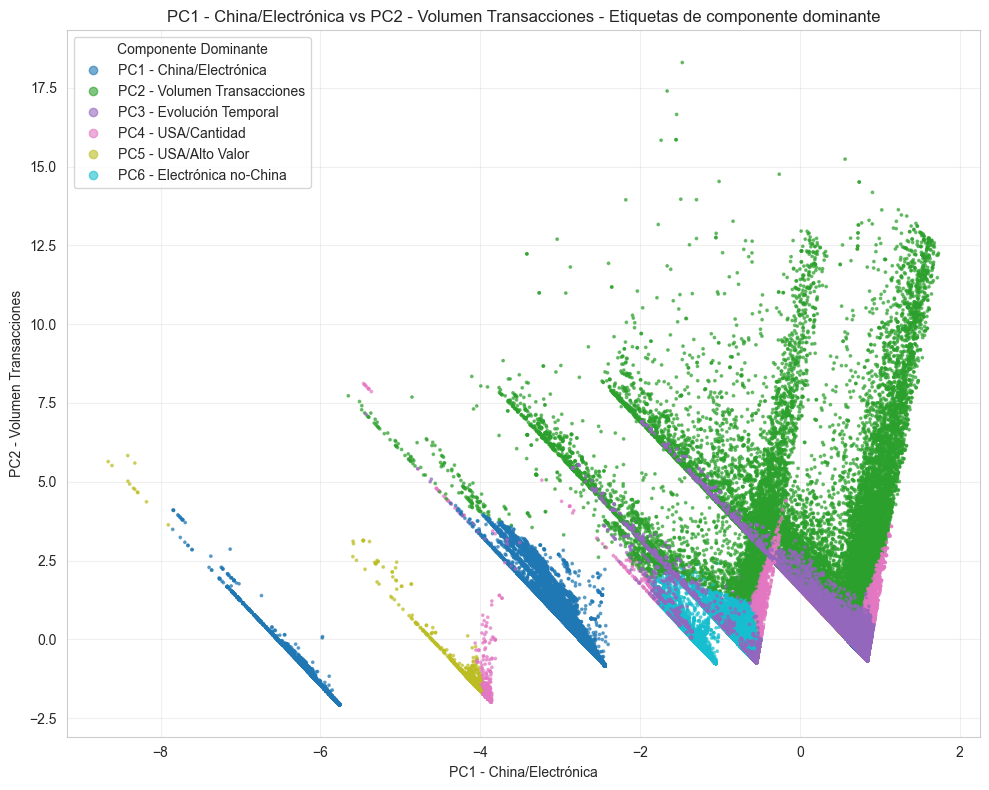

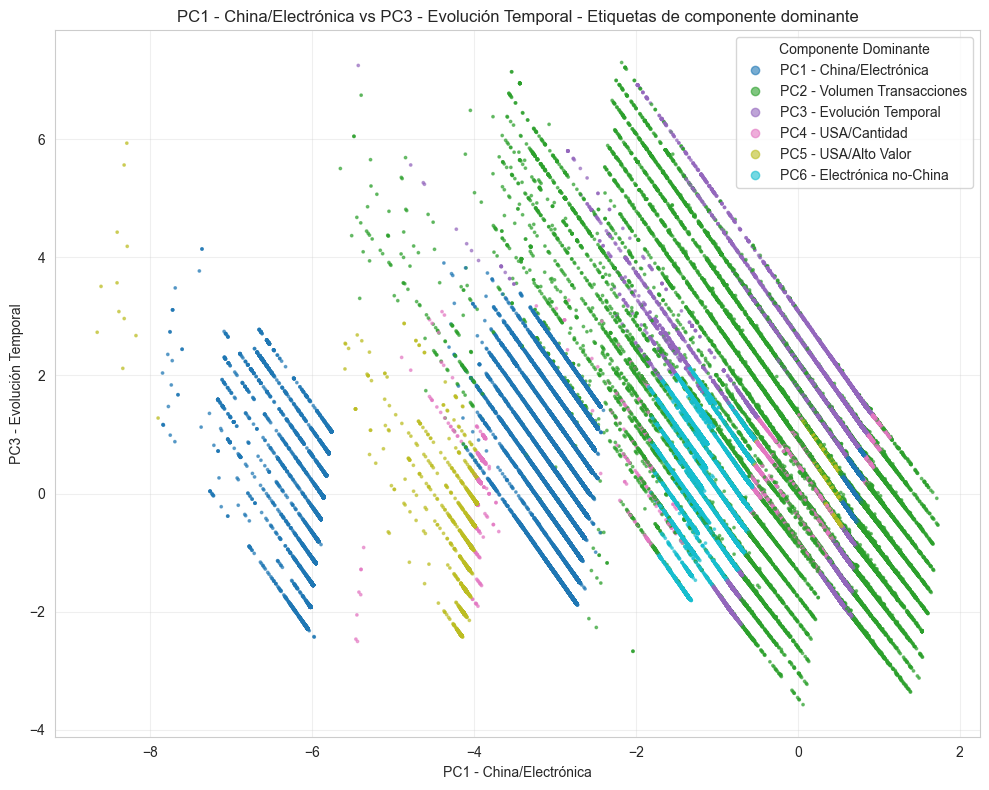

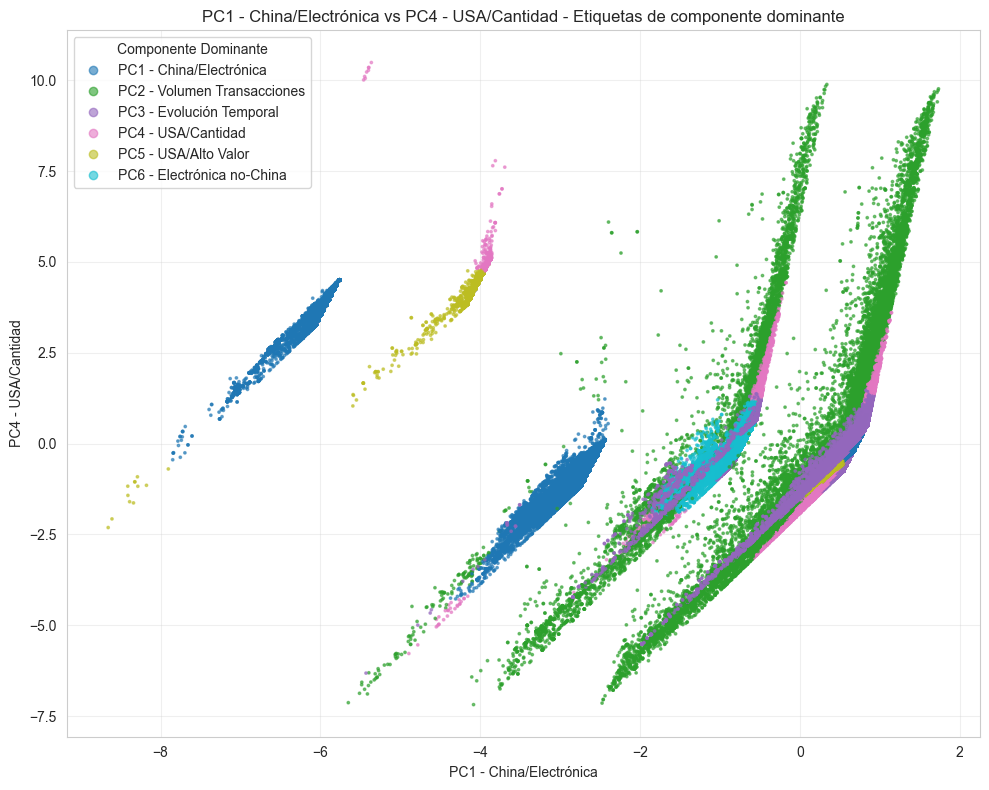

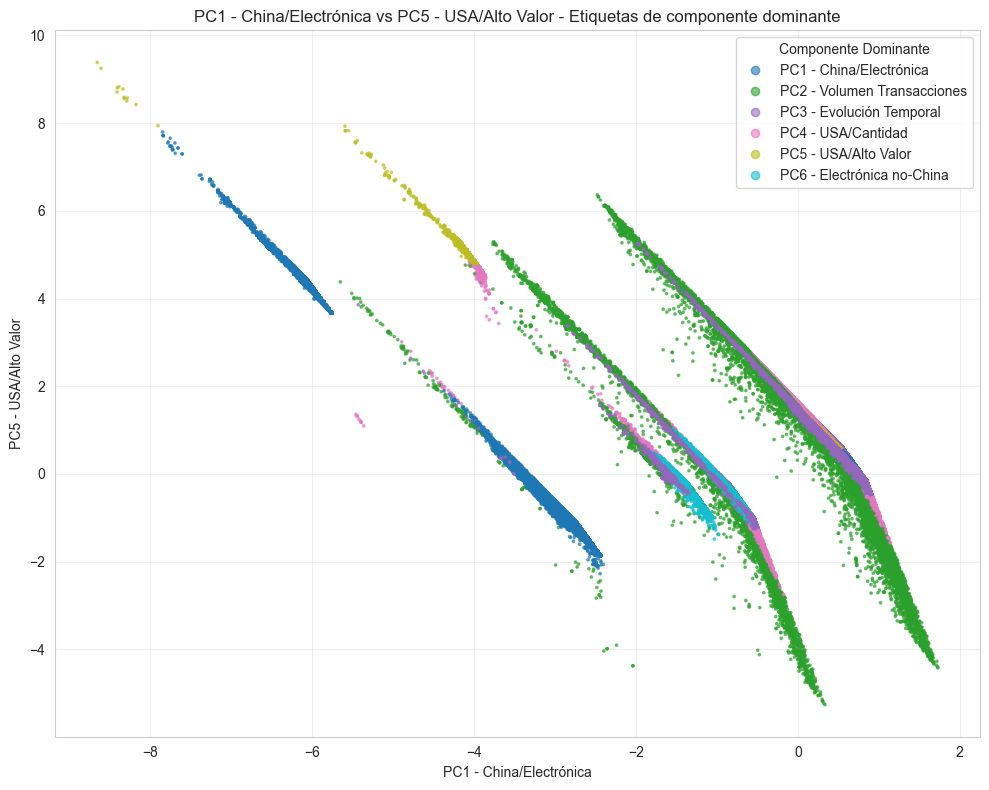

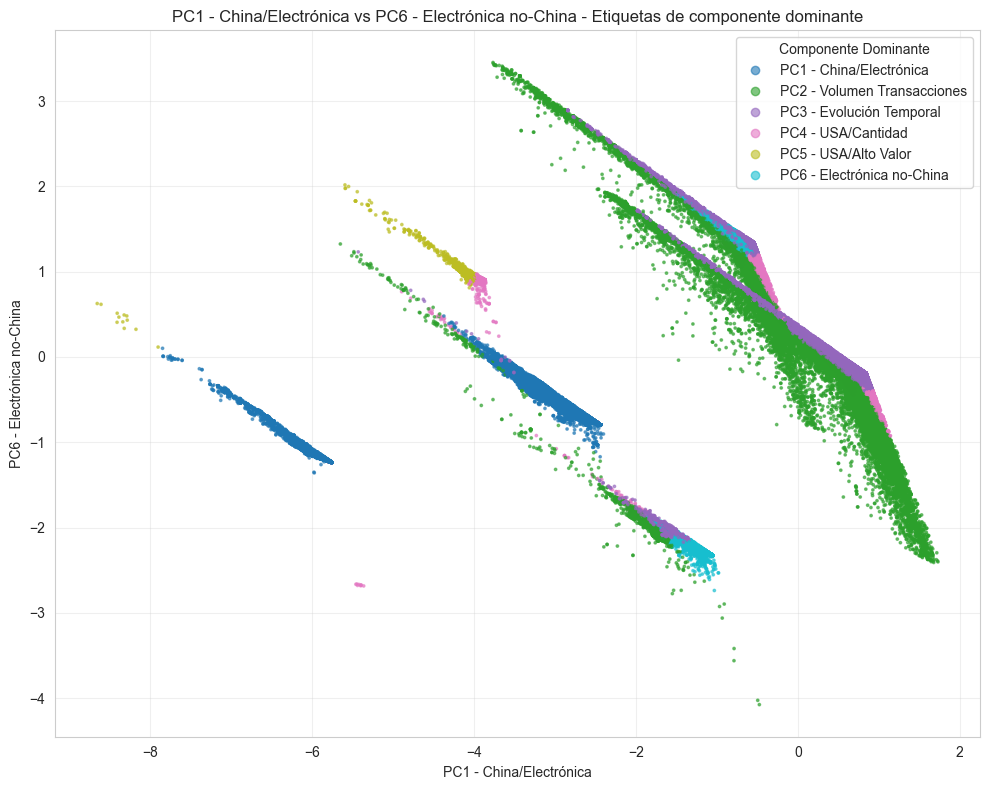

In [68]:
import re 

print("=== CARGA Y DESCRIPCIÓN DE RESULTADOS PCA ===")

# Cargar el archivo parquet
df_pca_cargado = pd.read_parquet("pca_results.parquet")

print(f"\nForma del dataset: {df_pca_cargado.shape}")
print(f"Columnas: {list(df_pca_cargado.columns)}")

print("\n=== PRIMERAS 5 FILAS ===")
print(df_pca_cargado.head())

print("\n=== DESCRIPCIÓN ESTADÍSTICA ===")
print(df_pca_cargado.describe())


# Obtener las componentes originales
componentes_originales = df_pca_cargado.values
componentes_dominantes = np.argmax(np.abs(componentes_originales), axis=1)

# Nombres completos de los componentes principales
component_labels = [
    "PC1 - China/Electrónica",
    "PC2 - Volumen Transacciones",
    "PC3 - Evolución Temporal",
    "PC4 - USA/Cantidad",
    "PC5 - USA/Alto Valor",
    "PC6 - Electrónica no-China"
]

def extraer_numero(latex_label):
    # Extrae dígitos de la cadena de label tipo '$\\mathdefault{0}$'
    return int(re.findall(r"\d+", latex_label)[0])

# Lista de pares (PC1 vs PCi)
pares = [
    (0,1),
    (0,2),
    (0,3),
    (0,4),
    (0,5)
]

for idx_x, idx_y in pares:
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        componentes_originales[:, idx_x],
        componentes_originales[:, idx_y],
        c=componentes_dominantes,
        cmap="tab10",
        alpha=0.6,
        s=3
    )
    plt.title(f"{component_labels[idx_x]} vs {component_labels[idx_y]} - Etiquetas de componente dominante")
    plt.xlabel(component_labels[idx_x])
    plt.ylabel(component_labels[idx_y])
    plt.grid(True, alpha=0.3)

    handles, labels = scatter.legend_elements()
    etiquetas_legibles = [component_labels[extraer_numero(lbl)] for lbl in labels]
    plt.legend(handles, etiquetas_legibles, title="Componente Dominante", loc="best")

    plt.tight_layout()
    plt.show()

In [69]:

# --- VARIANZA EXPLICADA POR COMPONENTE ---
#        Componente  Varianza Explicada  Varianza Acumulada
#    PC1_China_Elec              0.2670              0.2670
# PC2_Transacciones              0.1801              0.4471
#        PC3_Tiempo              0.1687              0.6158
# PC4_USA_Elec_Cant              0.1505              0.7663
# PC5_USA_Altovalor              0.1405              0.9069
#  PC6_Elec_noChina              0.0931              1.0000

---

# Las implicancias del dataset 


... reiniciemos pero con el dataset original sin la limpieza que hicimos 

---


### vamos a ver las diferencias e implicancias de haber limpiado el dataset 

In [70]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pyreadstat
# %pip install pyreadstat


# Cargar archivo de Stata
file_path = "Data/base_importaciones/Base cobus comercio tdf - con Cuits y Rama str.dta"

# Definir ruta del archivo parquet
output_path = file_path.replace('.dta', '.parquet')

# Verificar si el archivo parquet ya existe
import os
if os.path.exists(output_path):
    # Si existe, cargar directamente el parquet
    df = pd.read_parquet(output_path)
    print(f"Archivo parquet cargado: {len(df)} filas y {len(df.columns)} columnas")
else:
    # Si no existe, cargar el .dta y crear el parquet
    df, meta = pyreadstat.read_dta(file_path)
    df.to_parquet(output_path, index=False)
    print(f"Archivo cargado exitosamente con {len(df)} filas y {len(df.columns)} columnas")
    print(f"Archivo guardado como: {output_path}")
    
    # Abrir el archivo parquet creado
    df = pd.read_parquet(output_path)
    print(f"Archivo parquet abierto: {len(df)} filas y {len(df.columns)} columnas")


from funciones.describe_vars2 import describe_vars
from funciones.sort_df import sort_dataframe_columns


df = sort_dataframe_columns(df)

describe_vars(df)

# variables dentro del análisis

df = df

################
# pca_sin_limpieza

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Convertir todas las variables categóricas a dummies
X = pd.get_dummies(df, drop_first=False)

# 2. Eliminar columnas que no sean numéricas después de get_dummies (por ejemplo, si quedan objetos)
X = X.select_dtypes(include=[np.number])

# 3. Llenar posibles NaNs con 0 (puedes cambiarlo por otra imputación si prefieres)
X = X.fillna(0)

# 4. Estandarizar
X_scaled = StandardScaler().fit_transform(X)

# 5. PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 6. Mostrar varianza explicada
varianza = pca.explained_variance_ratio_
var_acum = np.cumsum(varianza)

print("\n=== VARIANZA EXPLICADA ===")
for i, (v, va) in enumerate(zip(varianza, var_acum), start=1):
    print(f"PC{i}: {v:.4f} (acumulada: {va:.4f})")

# 7. Mostrar cargas principales
cargas_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i}" for i in range(1, len(varianza)+1)]
)

print("\n=== CARGAS PRINCIPALES ===")
display(cargas_df.iloc[:16].round(4))  # componentes que explican el 90% de la varianza

Archivo parquet cargado: 664371 filas y 52 columnas
DataFrame reordenado con 52 columnas
Primeras 10 columnas: ['RAZONSOCIAL', 'RAZONSOCIAL_enc', 'RAZONSOCIAL_enc_str', 'CUIT', 'RAMA', 'RAMA2', 'RAMA3', 'RAMA_str', 'RAMA2_str', 'RAMA3_str']
Últimas 10 columnas: ['ANIO_TRIMESTRE_str', 'TRIMESTRE', 'NUMERODEDESPACHO', 'ITEM', 'POSICIONARANCELARIA', 'UNIDAD_enc', 'UNIDAD_enc_str', 'MEDIO', 'MEDIO_str', 'des_first4']


,Columna,Tipo,Nulos,Únicos,Valores_Muestra
0,RAZONSOCIAL,object,0,363,None
1,RAZONSOCIAL_enc,int64,0,363,None
2,RAZONSOCIAL_enc_str,object,0,363,None
3,CUIT,object,0,363,None
4,RAMA,int64,0,16,None
5,RAMA2,int64,0,52,None
6,RAMA3,int64,0,31,None
7,RAMA_str,object,0,31,None
8,RAMA2_str,object,0,52,None
9,RAMA3_str,object,0,31,None


,count,mean,std,min,25%,50%,75%,max
RAZONSOCIAL_enc,664371.0000,195.3600,73.9200,1.0000,161.0000,222.0000,224.0000,363.0000
RAMA,664371.0000,9.2600,2.8600,1.0000,9.0000,9.0000,9.0000,22.0000
RAMA2,664371.0000,32.6300,13.6800,4.0000,28.0000,28.0000,28.0000,86.0000
RAMA3,664371.0000,1.7400,2.8700,1.0000,1.0000,1.0000,1.0000,50.0000
PRECIOUNITARIODOLARSSUBITEM,664371.0000,1093.5100,156242.7000,0.0000,0.0100,0.1200,1.5400,49690348.0000
PRECIOUNITARIODOLARSITEM,664371.0000,1087.0300,156230.0500,0.0000,0.0300,0.1700,1.6000,49690348.0000
CANTIDADSUBITEM,664371.0000,7106.8200,32774.5100,0.0100,98.0000,2000.0000,5000.0000,5751185.0000
CANTIDADITEM,664371.0000,34946.3400,279557.5400,0.0100,250.0000,3300.0000,12200.0000,46130000.0000
FOBDOLARSSUBITEM,664371.0000,10823.9500,167200.7000,0.0000,19.7200,187.1600,1333.5000,49690348.0000
FOBDOLARSITEM,664371.0000,15567.9800,174688.0200,0.0000,63.8600,570.0000,3407.3400,49690348.0000



=== VARIANZA EXPLICADA ===
PC1: 0.2358 (acumulada: 0.2358)
PC2: 0.0948 (acumulada: 0.3306)
PC3: 0.0838 (acumulada: 0.4144)
PC4: 0.0649 (acumulada: 0.4794)
PC5: 0.0624 (acumulada: 0.5417)
PC6: 0.0517 (acumulada: 0.5935)
PC7: 0.0486 (acumulada: 0.6420)
PC8: 0.0452 (acumulada: 0.6872)
PC9: 0.0389 (acumulada: 0.7261)
PC10: 0.0349 (acumulada: 0.7610)
PC11: 0.0318 (acumulada: 0.7927)
PC12: 0.0311 (acumulada: 0.8238)
PC13: 0.0260 (acumulada: 0.8499)
PC14: 0.0252 (acumulada: 0.8751)
PC15: 0.0229 (acumulada: 0.8980)
PC16: 0.0216 (acumulada: 0.9196)
PC17: 0.0189 (acumulada: 0.9385)
PC18: 0.0180 (acumulada: 0.9565)
PC19: 0.0160 (acumulada: 0.9724)
PC20: 0.0118 (acumulada: 0.9842)
PC21: 0.0077 (acumulada: 0.9919)
PC22: 0.0047 (acumulada: 0.9966)
PC23: 0.0014 (acumulada: 0.9980)
PC24: 0.0011 (acumulada: 0.9992)
PC25: 0.0008 (acumulada: 1.0000)
PC26: 0.0000 (acumulada: 1.0000)
PC27: 0.0000 (acumulada: 1.0000)
PC28: 0.0000 (acumulada: 1.0000)

=== CARGAS PRINCIPALES ===


,RAZONSOCIAL_enc,RAMA,RAMA2,RAMA3,PRECIOUNITARIODOLARSSUBITEM,PRECIOUNITARIODOLARSITEM,CANTIDADSUBITEM,CANTIDADITEM,FOBDOLARSSUBITEM,FOBDOLARSITEM,...,LOCALIDAD,PUERTO,PAISDEORIGEN,PAISDEPROCEDENCIA,MES,ANIO,ANIO_TRIMESTRE,TRIMESTRE,UNIDAD_enc,MEDIO
PC1,-0.0065,0.0332,0.0347,0.0168,0.3509,0.3509,0.0127,0.0047,0.3789,0.3841,...,-0.0022,0.0046,0.0089,0.0071,-0.0027,-0.0050,-0.0054,-0.0025,-0.0239,0.0002
PC2,0.0072,-0.1655,-0.2956,-0.1898,0.0551,0.0551,-0.0327,0.0040,0.0299,0.0271,...,-0.0157,-0.2160,-0.2422,-0.2840,-0.1366,0.4468,0.4386,-0.1366,0.1933,0.1699
PC3,0.1295,-0.2401,-0.3744,-0.2415,0.0574,0.0574,-0.0641,0.0073,0.0221,0.0185,...,0.1147,0.1233,-0.2571,-0.2501,0.3897,-0.2972,-0.2579,0.3884,0.1929,-0.1652
PC4,-0.0423,0.1657,0.1811,0.0857,-0.0542,-0.0543,0.0536,-0.0026,-0.0174,-0.0088,...,-0.1197,-0.1456,0.0781,0.0630,0.5468,0.1895,0.2549,0.5491,-0.1604,0.1343
PC5,0.0004,0.4044,0.0272,-0.1711,-0.1526,-0.1526,0.1439,0.0743,-0.0568,-0.0298,...,0.0564,0.2871,-0.3245,-0.3793,-0.0689,0.0761,0.0698,-0.0666,-0.2773,-0.3329
PC6,0.4966,-0.1060,-0.0261,-0.0757,0.0231,0.0230,0.0266,0.0321,0.0096,-0.0003,...,0.5161,0.1886,0.2845,0.1723,0.0280,0.2199,0.2266,0.0281,0.0344,-0.2347
PC7,0.0982,-0.2679,-0.1542,0.0181,-0.2380,-0.2381,0.1106,0.1628,-0.0912,-0.0263,...,0.1085,-0.2569,0.0601,0.0796,-0.0342,-0.0956,-0.1012,-0.0359,0.2572,0.2487
PC8,-0.0560,0.0651,-0.0237,-0.1519,0.0753,0.0753,0.6439,0.6427,0.0255,0.0124,...,0.0535,-0.0818,0.0315,0.0081,-0.0198,-0.0951,-0.0988,-0.0192,-0.0633,0.1017
PC9,-0.0551,-0.0719,0.0318,0.2884,-0.0110,-0.0110,0.1492,0.1998,-0.0084,-0.0045,...,0.0189,0.0720,-0.0266,-0.0065,0.1307,0.2369,0.2551,0.1262,0.0471,0.0411
PC10,-0.3783,-0.1642,-0.1296,-0.0902,-0.0297,-0.0296,0.0606,0.1210,-0.0125,0.0035,...,-0.4021,0.4260,0.2163,0.2002,0.0175,0.1265,0.1302,0.0148,0.3842,-0.3704


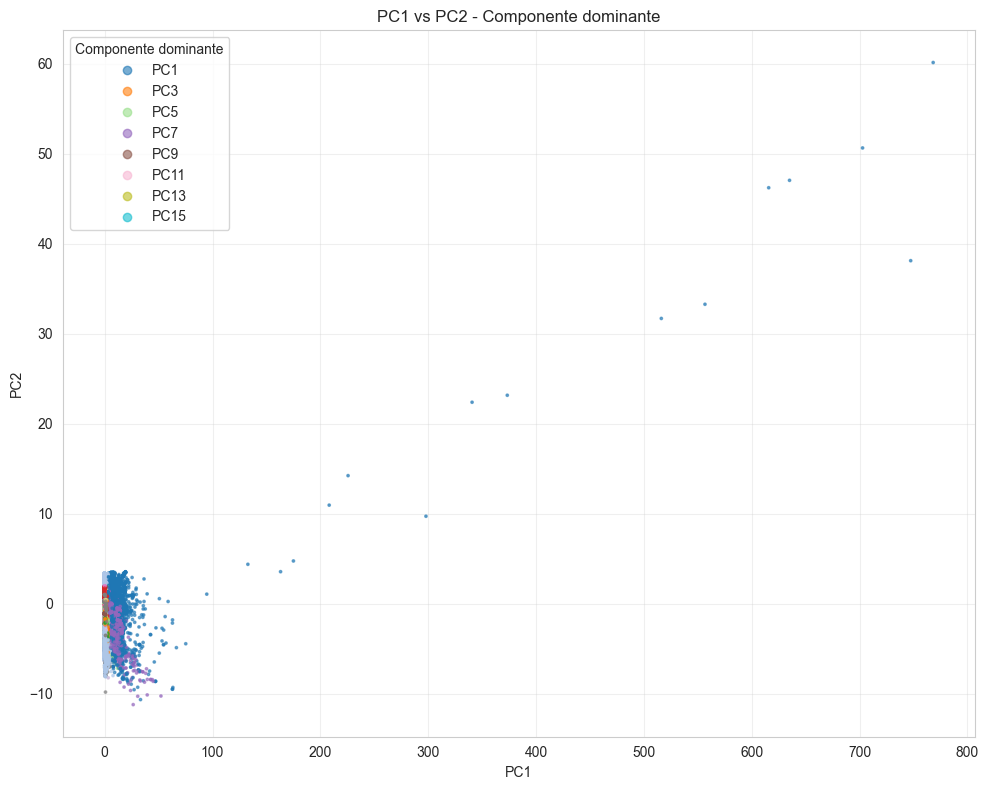

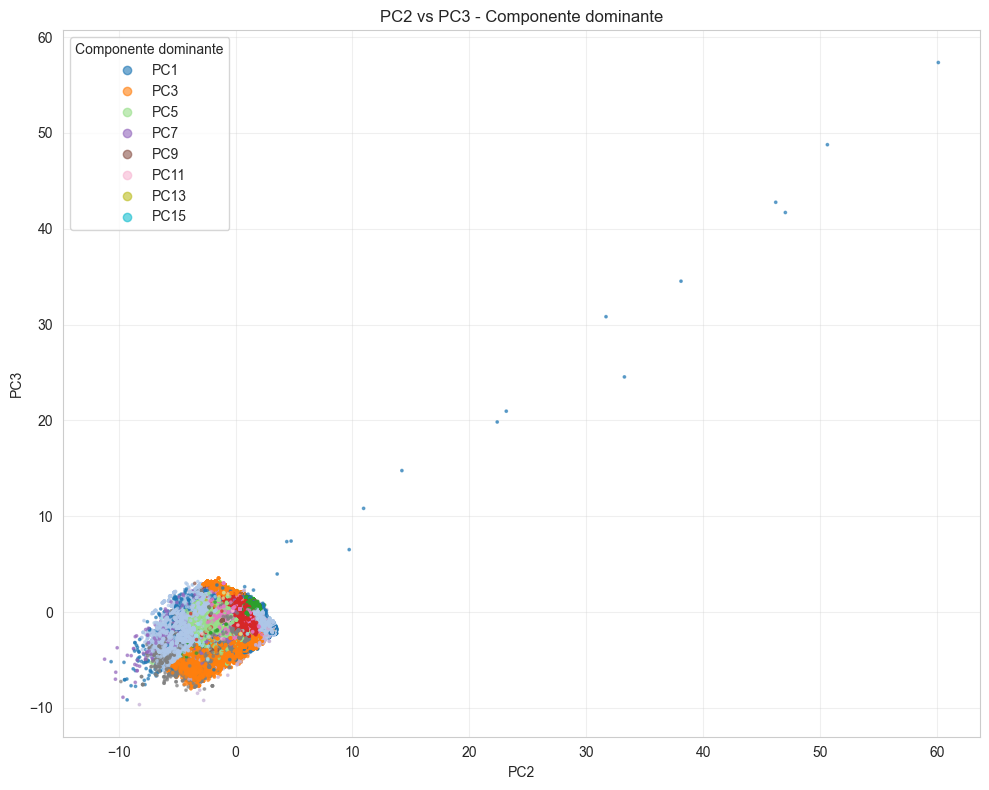


PC1 - Top 5 variables:
  CIFDOLARSITEM                            +0.385
  FOBDOLARSITEM                            +0.384
  FOBDOLARSSUBITEM                         +0.379
  SEGURODOLARSITEM                         +0.364
  PRECIOUNITARIODOLARSSUBITEM              +0.351

PC2 - Top 5 variables:
  ANIO                                     +0.447
  ANIO_TRIMESTRE                           +0.439
  RAMA2                                    -0.296
  PAISDEPROCEDENCIA                        -0.284
  TIPODESPACHO                             -0.267

PC3 - Top 5 variables:
  MES                                      +0.390
  TRIMESTRE                                +0.388
  RAMA2                                    -0.374
  ANIO                                     -0.297
  ANIO_TRIMESTRE                           -0.258

PC4 - Top 5 variables:
  TRIMESTRE                                +0.549
  MES                                      +0.547
  ANIO_TRIMESTRE                           +0.255
  TI

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import re

componentes_originales = X_pca

componentes_dominantes = np.argmax(np.abs(componentes_originales[:, :16]), axis=1)

pares = [
    (0, 1),
    (1, 2)
]

for idx_x, idx_y in pares:
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        componentes_originales[:, idx_x],
        componentes_originales[:, idx_y],
        c=componentes_dominantes,
        cmap="tab20",
        alpha=0.6,
        s=3
    )
    plt.title(f"PC{idx_x+1} vs PC{idx_y+1} - Componente dominante")
    plt.xlabel(f"PC{idx_x+1}")
    plt.ylabel(f"PC{idx_y+1}")
    plt.grid(True, alpha=0.3)

    handles, labels = scatter.legend_elements()

    # Extraer número sin usar f-string directa
    etiquetas_legibles = []
    for lbl in labels:
        num = int(re.findall(r"\d+", lbl)[0])
        etiquetas_legibles.append(f"PC{num + 1}")

    plt.legend(handles, etiquetas_legibles, title="Componente dominante", loc="best")

    plt.tight_layout()
    plt.show()


### features x componente
    top_n = 5 #primeros 5 componentes 

for i, comp in enumerate(cargas_df.values[:5]):  # Solo primeros 5 componentes
    top_vars = np.argsort(np.abs(comp))[::-1][:top_n]
    print(f"\nPC{i+1} - Top {top_n} variables:")
    for idx in top_vars:
        var = cargas_df.columns[idx]
        carga = comp[idx]
        print(f"  {var:40s} {carga:+.3f}")

DataFrame reordenado con 137 columnas
Primeras 10 columnas: ['RAMA_str_ALIMENTOS_BEBIDAS', 'RAMA_str_AUTOMOTORES', 'RAMA_str_AUTOPARTES', 'RAMA_str_CALZADO_INDUMENTARIA', 'RAMA_str_CARTON_PAPEL', 'RAMA_str_CONSTRUCCION', 'RAMA_str_ELECTRONICA_ELECTRODOM', 'RAMA_str_FARMACIA_MEDICINA', 'RAMA_str_FERRETERIA', 'RAMA_str_GOBIERNO']
Últimas 10 columnas: ['PAISDEORIGEN_str_Uzbekistan', 'PAISDEORIGEN_str_Vietnam', 'PAISDEORIGEN_str_Z Franca Manaos (Brasil)', 'MES_GLOBAL', 'ANIO', 'MEDIO_str_Avión', 'MEDIO_str_Camión', 'MEDIO_str_No Determinado', 'MEDIO_str_Propios Medios', 'MEDIO_str_Via postal']


,Columna,Tipo,Nulos,Únicos,Valores_Muestra
0,RAMA_str_ALIMENTOS_BEBIDAS,float64,0,2,"[-0.024460714531986248, 40.88188015490482]"
1,RAMA_str_AUTOMOTORES,float64,0,2,"[-0.07761146555365529, 12.88469419906352]"
2,RAMA_str_AUTOPARTES,float64,0,2,"[-0.051169123917903125, 19.543035397761003]"
3,RAMA_str_CALZADO_INDUMENTARIA,float64,0,2,"[-0.09325912236301671, 10.72281160986525]"
4,RAMA_str_CARTON_PAPEL,float64,0,2,"[-0.016790906414695203, 59.5560463087813]"
...,...,...,...,...,...
132,MEDIO_str_Avión,float64,0,2,"[-0.2576911564115892, 3.880614352177384]"
133,MEDIO_str_Camión,float64,0,2,"[2.4444116394753332, -0.4090963992523942]"
134,MEDIO_str_No Determinado,float64,0,2,"[-0.2128108141058688, 4.699009325261642]"
135,MEDIO_str_Propios Medios,float64,0,2,"[-0.014064310633746835, 71.10195629500197]"


,count,mean,std,min,25%,50%,75%,max
RAMA_str_ALIMENTOS_BEBIDAS,642174.0000,-0.0000,1.0000,-0.0200,-0.0200,-0.0200,-0.0200,40.8800
RAMA_str_AUTOMOTORES,642174.0000,0.0000,1.0000,-0.0800,-0.0800,-0.0800,-0.0800,12.8800
RAMA_str_AUTOPARTES,642174.0000,0.0000,1.0000,-0.0500,-0.0500,-0.0500,-0.0500,19.5400
RAMA_str_CALZADO_INDUMENTARIA,642174.0000,0.0000,1.0000,-0.0900,-0.0900,-0.0900,-0.0900,10.7200
RAMA_str_CARTON_PAPEL,642174.0000,-0.0000,1.0000,-0.0200,-0.0200,-0.0200,-0.0200,59.5600
...,...,...,...,...,...,...,...,...
MEDIO_str_Avión,642174.0000,-0.0000,1.0000,-0.2600,-0.2600,-0.2600,-0.2600,3.8800
MEDIO_str_Camión,642174.0000,-0.0000,1.0000,-0.4100,-0.4100,-0.4100,-0.4100,2.4400
MEDIO_str_No Determinado,642174.0000,0.0000,1.0000,-0.2100,-0.2100,-0.2100,-0.2100,4.7000
MEDIO_str_Propios Medios,642174.0000,-0.0000,1.0000,-0.0100,-0.0100,-0.0100,-0.0100,71.1000



=== VARIANZA EXPLICADA ===
PC1: 0.0228 (acumulada: 0.0228)
PC2: 0.0158 (acumulada: 0.0386)
PC3: 0.0157 (acumulada: 0.0543)
PC4: 0.0129 (acumulada: 0.0672)
PC5: 0.0127 (acumulada: 0.0798)
PC6: 0.0116 (acumulada: 0.0914)
PC7: 0.0112 (acumulada: 0.1026)
PC8: 0.0108 (acumulada: 0.1134)
PC9: 0.0099 (acumulada: 0.1233)
PC10: 0.0097 (acumulada: 0.1329)
PC11: 0.0094 (acumulada: 0.1424)
PC12: 0.0093 (acumulada: 0.1516)
PC13: 0.0091 (acumulada: 0.1607)
PC14: 0.0089 (acumulada: 0.1696)
PC15: 0.0088 (acumulada: 0.1783)
PC16: 0.0086 (acumulada: 0.1869)
PC17: 0.0085 (acumulada: 0.1954)
PC18: 0.0083 (acumulada: 0.2037)
PC19: 0.0082 (acumulada: 0.2119)
PC20: 0.0081 (acumulada: 0.2200)
PC21: 0.0081 (acumulada: 0.2281)
PC22: 0.0079 (acumulada: 0.2360)
PC23: 0.0078 (acumulada: 0.2438)
PC24: 0.0078 (acumulada: 0.2516)
PC25: 0.0078 (acumulada: 0.2593)
PC26: 0.0077 (acumulada: 0.2670)
PC27: 0.0077 (acumulada: 0.2747)
PC28: 0.0077 (acumulada: 0.2824)
PC29: 0.0076 (acumulada: 0.2900)
PC30: 0.0076 (acumulada:

,RAMA_str_ALIMENTOS_BEBIDAS,RAMA_str_AUTOMOTORES,RAMA_str_AUTOPARTES,RAMA_str_CALZADO_INDUMENTARIA,RAMA_str_CARTON_PAPEL,RAMA_str_CONSTRUCCION,RAMA_str_ELECTRONICA_ELECTRODOM,RAMA_str_FARMACIA_MEDICINA,RAMA_str_FERRETERIA,RAMA_str_GOBIERNO,...,PAISDEORIGEN_str_Uzbekistan,PAISDEORIGEN_str_Vietnam,PAISDEORIGEN_str_Z Franca Manaos (Brasil),MES_GLOBAL,ANIO,MEDIO_str_Avión,MEDIO_str_Camión,MEDIO_str_No Determinado,MEDIO_str_Propios Medios,MEDIO_str_Via postal
PC1,-0.0193,-0.0996,-0.0417,-0.0733,-0.0330,-0.0270,0.5010,-0.0251,-0.0173,-0.0276,...,-0.0231,-0.0628,-0.0120,0.0635,0.0612,-0.2134,0.0189,-0.0084,-0.0272,-0.0313
PC2,-0.0097,0.0086,-0.0017,0.0044,0.0378,0.0119,0.0072,0.0087,0.0127,-0.0225,...,0.0435,-0.0043,0.0040,0.2842,0.2839,-0.2563,0.1129,-0.0298,-0.0075,-0.0313
PC3,-0.0031,0.0113,0.0236,0.0772,0.0071,0.0006,-0.0405,-0.0104,0.0074,0.0028,...,-0.0061,0.0686,0.0148,0.5833,0.5832,0.1569,0.2770,-0.0264,-0.0101,-0.0261
PC4,-0.0008,0.0129,-0.0015,-0.0359,-0.0040,0.0730,0.0356,0.0198,0.0298,0.0131,...,-0.0066,-0.0362,0.0035,0.0321,0.0316,0.0108,0.0245,-0.0185,-0.0028,0.6484
PC5,0.0078,-0.0053,0.0300,0.2724,0.0113,0.0194,-0.1850,-0.0158,0.0059,-0.0112,...,0.0008,0.2572,-0.0085,0.0083,0.0096,-0.2765,-0.0049,0.1229,-0.0133,0.0870
PC6,0.0105,-0.0182,-0.0304,-0.2768,0.0516,-0.0115,-0.0045,0.0209,0.0129,0.0318,...,-0.0146,-0.2567,0.0070,0.0662,0.0663,-0.0036,-0.0770,-0.0793,0.0060,-0.0385
PC7,0.0181,-0.1687,-0.0717,-0.0448,0.0016,0.0152,-0.1153,-0.0426,-0.0015,-0.0235,...,0.0494,-0.0730,-0.0333,0.0569,0.0567,0.0302,-0.1090,-0.0463,-0.1277,0.0836
PC8,-0.0369,0.0067,0.0974,-0.2317,-0.0196,0.0032,0.1104,-0.0374,-0.0195,-0.0137,...,0.0354,-0.1760,0.0004,0.0182,0.0190,-0.0426,0.0687,-0.0768,-0.0289,0.0335
PC9,0.0072,-0.1095,-0.0350,0.0149,-0.0443,-0.0323,-0.0478,-0.0515,-0.0174,-0.0177,...,0.0176,-0.0261,0.0427,0.0504,0.0497,0.1068,-0.0786,-0.0564,0.5690,0.0207
PC10,0.0364,0.4655,-0.0177,-0.2803,0.0266,0.0981,-0.0629,0.0067,0.0288,-0.0547,...,-0.0146,-0.0562,-0.0116,-0.0396,-0.0398,-0.1333,0.2375,0.0140,0.1040,0.0223


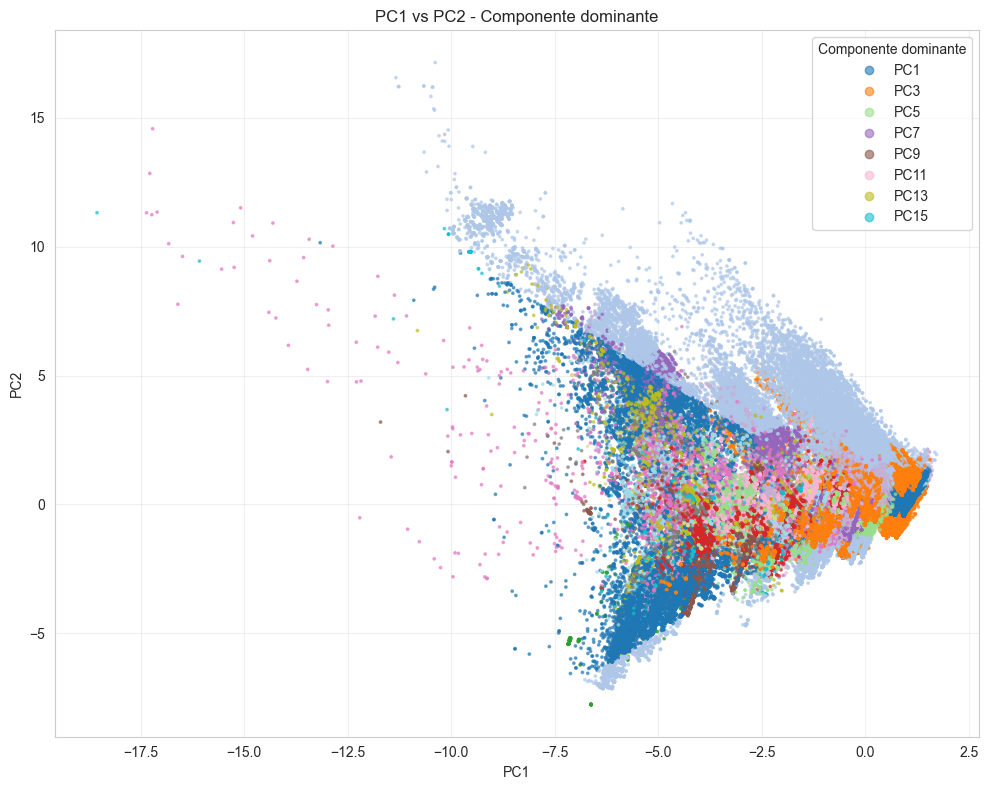

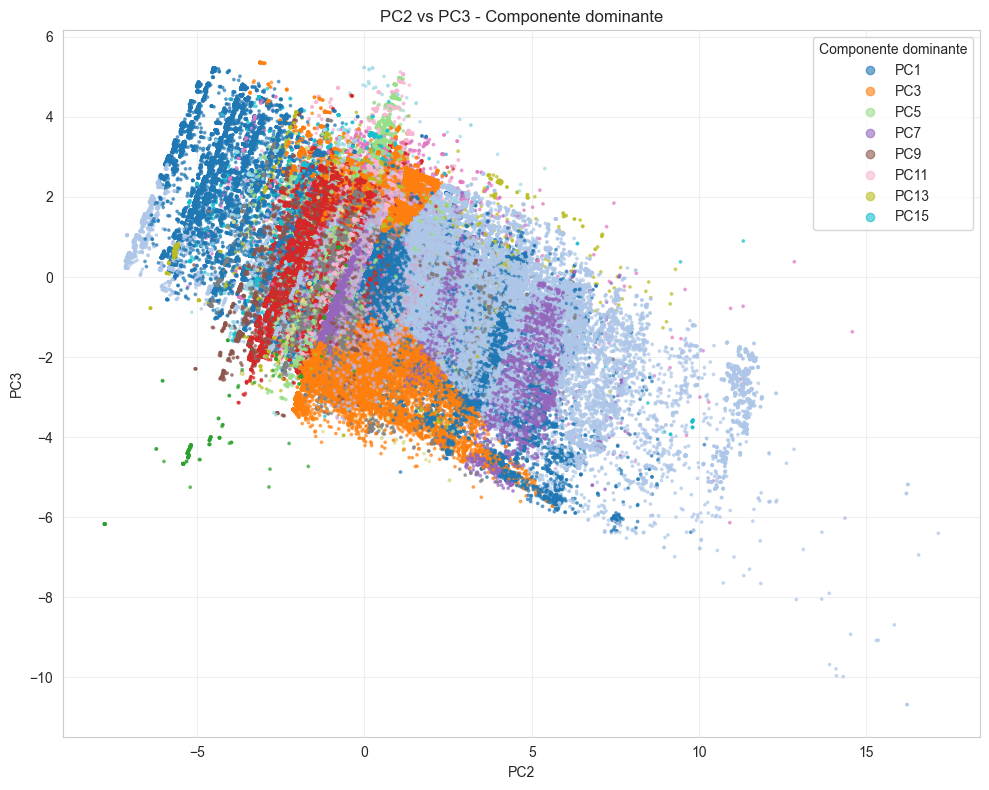


PC1 - Top 5 variables:
  RAMA_str_ELECTRONICA_ELECTRODOM          +0.501
  PAISDEORIGEN_str_China                   +0.379
  RAMA_str_PESCA                           -0.270
  RAMA_str_TEXTIL                          -0.240
  KILOGRAMOSNETOITEM                       -0.230

PC2 - Top 5 variables:
  KILOGRAMOSNETOITEM                       +0.413
  FOBDOLARSITEM                            +0.366
  RAMA_str_TEXTIL                          +0.314
  RAMA_str_PESCA                           -0.302
  MES_GLOBAL                               +0.284

PC3 - Top 5 variables:
  MES_GLOBAL                               +0.583
  ANIO                                     +0.583
  MEDIO_str_Camión                         +0.277
  KILOGRAMOSNETOITEM                       -0.183
  RAMA_str_PESCA                           +0.166

PC4 - Top 5 variables:
  RAMA_str_NO INFORMADO                    +0.672
  MEDIO_str_Via postal                     +0.648
  PAISDEORIGEN_str_Bolivia                 +0.209
  PA

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pyreadstat
# %pip install pyreadstat

# Cargar el archivo parquet
df = pd.read_parquet("Data/df_clean_v3.parquet")
#################################################################################
#AHORA CON LA VERSIÓN NORMALIZADA Y SIN MISSINGS, PERO CON TODAS LAS VARIABLES

from funciones.describe_vars2 import describe_vars
from funciones.sort_df import sort_dataframe_columns


df = sort_dataframe_columns(df)

describe_vars(df)

# variables dentro del análisis

df = df

################
# pca_sin_limpieza

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Convertir todas las variables categóricas a dummies
X = pd.get_dummies(df, drop_first=False)

# 2. Eliminar columnas que no sean numéricas después de get_dummies (por ejemplo, si quedan objetos)
X = X.select_dtypes(include=[np.number])

# 3. Llenar posibles NaNs con 0 (puedes cambiarlo por otra imputación si prefieres)
X = X.fillna(0)

# 4. Estandarizar
X_scaled = StandardScaler().fit_transform(X)

# 5. PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 6. Mostrar varianza explicada
varianza = pca.explained_variance_ratio_
var_acum = np.cumsum(varianza)

print("\n=== VARIANZA EXPLICADA ===")
for i, (v, va) in enumerate(zip(varianza, var_acum), start=1):
    print(f"PC{i}: {v:.4f} (acumulada: {va:.4f})")

# 7. Mostrar cargas principales
cargas_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i}" for i in range(1, len(varianza)+1)]
)

print("\n=== CARGAS PRINCIPALES ===")
display(cargas_df.iloc[:16].round(4))  # componentes que explican el 90% de la varianza


import matplotlib.pyplot as plt
import numpy as np
import re

componentes_originales = X_pca

componentes_dominantes = np.argmax(np.abs(componentes_originales[:, :16]), axis=1)

pares = [
    (0, 1),
    (1, 2)
]

for idx_x, idx_y in pares:
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        componentes_originales[:, idx_x],
        componentes_originales[:, idx_y],
        c=componentes_dominantes,
        cmap="tab20",
        alpha=0.6,
        s=3
    )
    plt.title(f"PC{idx_x+1} vs PC{idx_y+1} - Componente dominante")
    plt.xlabel(f"PC{idx_x+1}")
    plt.ylabel(f"PC{idx_y+1}")
    plt.grid(True, alpha=0.3)

    handles, labels = scatter.legend_elements()

    # Extraer número sin usar f-string directa
    etiquetas_legibles = []
    for lbl in labels:
        num = int(re.findall(r"\d+", lbl)[0])
        etiquetas_legibles.append(f"PC{num + 1}")

    plt.legend(handles, etiquetas_legibles, title="Componente dominante", loc="best")

    plt.tight_layout()
    plt.show()


### features x componente
    top_n = 5 #primeros 5 componentes 

for i, comp in enumerate(cargas_df.values[:5]):  # Solo primeros 5 componentes
    top_vars = np.argsort(np.abs(comp))[::-1][:top_n]
    print(f"\nPC{i+1} - Top {top_n} variables:")
    for idx in top_vars:
        var = cargas_df.columns[idx]
        carga = comp[idx]
        print(f"  {var:40s} {carga:+.3f}")

Problemas de interpretación, problemas de representación pero, por sobre todo, está mal técnicamente. :) 

## ¿Qué está pasando?

El PCA termina generando componentes que solo son combinaciones rotadas de las mismas columnas dummy, sin ganancia interpretativa ni reducción real de dimensionalidad.

### Solución de recodificación

Es una práctica común para evitar alta cardinalidad y sparsity. Es mejor tener una categoría "otros" que trabajar con 50 columnas que son casi todo ceros.

**Profundicemos...**


PCA solo con sectores, cada sector un dummie

In [73]:
# CORREMOS EL MISMO PROBLEMA SIMPLIFICADO, SOLO TODOS LOS SECTORES 
# o sea, dejamos de lado el resto de las variables y sólo vamos a trabajar con los sectores 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Cargar datos limpios 
df = pd.read_parquet("Data/df_clean_v3.parquet")

print(f"Dimensiones del DataFrame: {df.shape[0]} filas x {df.shape[1]} columnas")

# 2. Seleccionar solo las dummies de sector
sector_cols = [col for col in df.columns if col.startswith("RAMA_str_")]
X = df[sector_cols].copy()

# 3. Revisar que no haya columnas totalmente nulas
X = X.loc[:, (X.sum(axis=0) > 0)]

print(f"Variables de sector seleccionadas: {len(X.columns)} columnas")
print("Lista de variables:", X.columns.tolist())

# Mostrar dimensionalidad de la selección
print(f"\n=== DIMENSIONALIDAD DE LA SELECCIÓN RAMA_STR ===")
print(f"Filas: {X.shape[0]}")
print(f"Columnas: {X.shape[1]}")
print(f"Total de elementos: {X.shape[0] * X.shape[1]:,}")

# 4. Estandarizar
X_scaled = StandardScaler().fit_transform(X)

# 5. PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 6. Varianza explicada
varianza = pca.explained_variance_ratio_
var_acum = np.cumsum(varianza)

print("\n=== VARIANZA EXPLICADA ===")
for i, (v, va) in enumerate(zip(varianza, var_acum), start=1):
    print(f"PC{i}: {v:.4f} (acumulada: {va:.4f})")

# 7. Cargas principales
cargas_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i}" for i in range(1, len(varianza)+1)]
)


Dimensiones del DataFrame: 642174 filas x 137 columnas
Variables de sector seleccionadas: 16 columnas
Lista de variables: ['RAMA_str_AUTOMOTORES', 'RAMA_str_AUTOPARTES', 'RAMA_str_CALZADO_INDUMENTARIA', 'RAMA_str_CONSTRUCCION', 'RAMA_str_GOBIERNO', 'RAMA_str_HIDROCARBUROS', 'RAMA_str_HOTELERIA_GASTRONOMIA', 'RAMA_str_INDUSTRIALES', 'RAMA_str_INMOBILIARIOS', 'RAMA_str_MAYORISTA', 'RAMA_str_OPTICA_FOTO_OTROS', 'RAMA_str_OTROS', 'RAMA_str_RETAIL_BAZAR', 'RAMA_str_TELECOMUNICACIONES', 'RAMA_str_TEXTIL', 'RAMA_str_TURISMO_ESPARCIMIENTO']

=== DIMENSIONALIDAD DE LA SELECCIÓN RAMA_STR ===
Filas: 642174
Columnas: 16
Total de elementos: 10,274,784

=== VARIANZA EXPLICADA ===
PC1: 0.0637 (acumulada: 0.0637)
PC2: 0.0630 (acumulada: 0.1266)
PC3: 0.0628 (acumulada: 0.1894)
PC4: 0.0627 (acumulada: 0.2521)
PC5: 0.0626 (acumulada: 0.3147)
PC6: 0.0626 (acumulada: 0.3773)
PC7: 0.0626 (acumulada: 0.4399)
PC8: 0.0626 (acumulada: 0.5025)
PC9: 0.0625 (acumulada: 0.5650)
PC10: 0.0625 (acumulada: 0.6276)
PC11

### COMO ERA DE ESPERAR, EL PROBLEMA DE LA DIMENSIONALIDAD SE MANTIENE

- Tenemos 30 sectores
- tenemos 30 componentes

> NO HAY REDUCCIÓN DE DIMENSIONALIDAD 

Agrupemos los valores, a ver si se soluciona el problema. Vamos a crear, ordenando las frecuencias, una nueva categoría otros que contiene todos los valores excepto los tres más importantes:

In [74]:
from funciones.describe_vars2 import describe_vars
import pandas as pd
import numpy as np

# Si tu DataFrame parquet ya estaba limpio:
df = pd.read_parquet("Data/df_clean_v3.parquet")

print("DataFrame cargado. Filas:", len(df))

# 2. Identificar las columnas dummy de sector
sector_cols = [col for col in df.columns if col.startswith("RAMA_str_")]
print("Columnas de sector encontradas:", sector_cols)

# 3. Verificar la frecuencia de cada dummy
sector_freqs = df[sector_cols].sum().sort_values(ascending=False)
print("Frecuencia de cada sector:\n", sector_freqs)

# 4. Tomar las 3 más frecuentes
top3 = sector_freqs.head(3).index.tolist()
print("Top 3 sectores:", top3)

# 5. Crear una nueva variable categórica con 4 categorías (Top 3 + OTROS)
def clasificar_sector(row):
    for col in top3:
        if row[col] == 1:
            return col.replace("RAMA_str_", "")
    return "OTROS"

df["SECTOR_AGRUPADO"] = df.apply(clasificar_sector, axis=1)

print("\nDistribución de la nueva variable SECTOR_AGRUPADO:")
print(df["SECTOR_AGRUPADO"].value_counts())

# 6. (Opcional) Si prefieres, puedes convertirla a categoría
df["SECTOR_AGRUPADO"] = df["SECTOR_AGRUPADO"].astype("category")

############################# ANALISIS PCA CON LAS NUEVAS VARS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Reutilizar DataFrame existente con SECTOR_AGRUPADO
# Si ya está cargado como df, no necesitas volver a leer parquet

# 2. Convertir SECTOR_AGRUPADO en dummies (4 categorías)
X = pd.get_dummies(df["SECTOR_AGRUPADO"], prefix="SECTOR")

print("Columnas generadas por get_dummies:", X.columns.tolist())

# 3. Estandarizar
X_scaled = StandardScaler().fit_transform(X)

# 4. PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 5. Varianza explicada
varianza = pca.explained_variance_ratio_
var_acum = np.cumsum(varianza)

print("\n=== VARIANZA EXPLICADA ===")
for i, (v, va) in enumerate(zip(varianza, var_acum), start=1):
    print(f"PC{i}: {v:.4f} (acumulada: {va:.4f})")

# 6. Cargas principales
cargas_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i}" for i in range(1, len(varianza)+1)]
)

print("\n=== CARGAS PRINCIPALES ===")
display(cargas_df.round(4))

DataFrame cargado. Filas: 642174
Columnas de sector encontradas: ['RAMA_str_ALIMENTOS_BEBIDAS', 'RAMA_str_AUTOMOTORES', 'RAMA_str_AUTOPARTES', 'RAMA_str_CALZADO_INDUMENTARIA', 'RAMA_str_CARTON_PAPEL', 'RAMA_str_CONSTRUCCION', 'RAMA_str_ELECTRONICA_ELECTRODOM', 'RAMA_str_FARMACIA_MEDICINA', 'RAMA_str_FERRETERIA', 'RAMA_str_GOBIERNO', 'RAMA_str_HIDROCARBUROS', 'RAMA_str_HOTELERIA_GASTRONOMIA', 'RAMA_str_INDUSTRIALES', 'RAMA_str_IND_DEPORTIVA', 'RAMA_str_IND_PLASTICA', 'RAMA_str_INMOBILIARIOS', 'RAMA_str_LOGISTICA_TRANSP', 'RAMA_str_MAQUINARIA_EQUIPO', 'RAMA_str_MAYORISTA', 'RAMA_str_NO INFORMADO', 'RAMA_str_OPTICA_FOTO_OTROS', 'RAMA_str_OTROS', 'RAMA_str_PESCA', 'RAMA_str_PETROQUIMICA', 'RAMA_str_PLASTICOS', 'RAMA_str_POLIRUBRO', 'RAMA_str_RETAIL_BAZAR', 'RAMA_str_TELECOMUNICACIONES', 'RAMA_str_TEXTIL', 'RAMA_str_TURISMO_ESPARCIMIENTO']
Frecuencia de cada sector:
 RAMA_str_AUTOPARTES                0.0000
RAMA_str_TURISMO_ESPARCIMIENTO     0.0000
RAMA_str_INDUSTRIALES              0.0000

/opt/anaconda3/envs/teaching/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:648: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


,SECTOR_OTROS
PC1,1.0000


funciona bien, pero no reduce la dimensionalidad. Solo ganamos un componente sobre 4 variables. Vamos a explorar si es porque son pocas variables... quizás la categoría otros está demasiado comprimida... 

In [75]:
#############################
# EJEMPLO CON 8 SECTORES EN LUGAR DE 3
#############################

import pandas as pd
import numpy as np

# Cargar DataFrame limpio
df = pd.read_parquet("Data/df_clean_v3.parquet")
print("DataFrame cargado. Filas:", len(df))

# Identificar columnas dummy de sector
sector_cols = [col for col in df.columns if col.startswith("RAMA_str_")]
print("Columnas de sector encontradas:", sector_cols)

# Verificar frecuencia de cada dummy
sector_freqs = df[sector_cols].sum().sort_values(ascending=False)
print("Frecuencia de cada sector:\n", sector_freqs)

# Tomar las 8 más frecuentes
top_sectores = sector_freqs.head(8).index.tolist()
print("Top sectores:", top_sectores)

# Crear variable categórica con Top 8 + OTROS
def clasificar_sector(row):
    for col in top_sectores:
        if row[col] == 1:
            return col.replace("RAMA_str_", "")
    return "OTROS"

df["SECTOR_AGRUPADO"] = df.apply(clasificar_sector, axis=1)
print("\nDistribución de la nueva variable SECTOR_AGRUPADO:")
print(df["SECTOR_AGRUPADO"].value_counts())

# Convertir en categoría
df["SECTOR_AGRUPADO"] = df["SECTOR_AGRUPADO"].astype("category")


#############################
# ANÁLISIS PCA CON LA NUEVA VARIABLE
#############################

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Convertir SECTOR_AGRUPADO en dummies
X = pd.get_dummies(df["SECTOR_AGRUPADO"], prefix="SECTOR")
print("Columnas generadas por get_dummies:", X.columns.tolist())

# Estandarizar
X_scaled = StandardScaler().fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
varianza = pca.explained_variance_ratio_
var_acum = np.cumsum(varianza)

print("\n=== VARIANZA EXPLICADA ===")
for i, (v, va) in enumerate(zip(varianza, var_acum), start=1):
    print(f"PC{i}: {v:.4f} (acumulada: {va:.4f})")

# Cargas principales
cargas_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i}" for i in range(1, len(varianza)+1)]
)

print("\n=== CARGAS PRINCIPALES ===")
display(cargas_df.round(4))

DataFrame cargado. Filas: 642174
Columnas de sector encontradas: ['RAMA_str_ALIMENTOS_BEBIDAS', 'RAMA_str_AUTOMOTORES', 'RAMA_str_AUTOPARTES', 'RAMA_str_CALZADO_INDUMENTARIA', 'RAMA_str_CARTON_PAPEL', 'RAMA_str_CONSTRUCCION', 'RAMA_str_ELECTRONICA_ELECTRODOM', 'RAMA_str_FARMACIA_MEDICINA', 'RAMA_str_FERRETERIA', 'RAMA_str_GOBIERNO', 'RAMA_str_HIDROCARBUROS', 'RAMA_str_HOTELERIA_GASTRONOMIA', 'RAMA_str_INDUSTRIALES', 'RAMA_str_IND_DEPORTIVA', 'RAMA_str_IND_PLASTICA', 'RAMA_str_INMOBILIARIOS', 'RAMA_str_LOGISTICA_TRANSP', 'RAMA_str_MAQUINARIA_EQUIPO', 'RAMA_str_MAYORISTA', 'RAMA_str_NO INFORMADO', 'RAMA_str_OPTICA_FOTO_OTROS', 'RAMA_str_OTROS', 'RAMA_str_PESCA', 'RAMA_str_PETROQUIMICA', 'RAMA_str_PLASTICOS', 'RAMA_str_POLIRUBRO', 'RAMA_str_RETAIL_BAZAR', 'RAMA_str_TELECOMUNICACIONES', 'RAMA_str_TEXTIL', 'RAMA_str_TURISMO_ESPARCIMIENTO']
Frecuencia de cada sector:
 RAMA_str_AUTOPARTES                0.0000
RAMA_str_TURISMO_ESPARCIMIENTO     0.0000
RAMA_str_INDUSTRIALES              0.0000

/opt/anaconda3/envs/teaching/lib/python3.11/site-packages/sklearn/decomposition/_pca.py:648: RuntimeWarning: invalid value encountered in divide
  explained_variance_ratio_ = explained_variance_ / total_var


,SECTOR_OTROS
PC1,1.0000


---

Como se observa, tanto con 3+otros como con 8+otros, el problema persiste. Esto ocurre a pesar de que se combinen las variables, porque la estructura excluyente de las respuestas mantiene la misma naturaleza, por lo tanto no se logra reducir realmente la dimensionalidad de los sectores.



| Caso | SECTOR_A | SECTOR_B | SECTOR_C | SECTOR_D | SECTOR_E | SECTOR_F | SECTOR_G | SECTOR_H |
|------|----------|----------|----------|----------|----------|----------|----------|----------|
| 1    | 1        | 0        | 0        | 0        | 0        | 0        | 0        | 0        |
| 2    | 0        | 1        | 0        | 0        | 0        | 0        | 0        | 0        |
| 3    | 0        | 0        | 1        | 0        | 0        | 0        | 0        | 0        |
| 4    | 0        | 0        | 0        | 1        | 0        | 0        | 0        | 0        |
| 5    | 0        | 0        | 0        | 0        | 1        | 0        | 0        | 0        |
| 6    | 0        | 0        | 0        | 0        | 0        | 1        | 0        | 0        |
| 7    | 0        | 0        | 0        | 0        | 0        | 0        | 1        | 0        |

**Problema**: Cada fila tiene exactamente un "1" y el resto "0", creando una estructura excluyente que impide la reducción efectiva de dimensionalidad en PCA/MCA/NMF.

La solución consiste en combinar las variables en la fase de transformación, para que exista mayor combinatoria de valores por observación, buscando evitar que haya únicamente un "1" por fila y el resto "0". Esta es una limitación del PCA, del MCA y del NMF, ya que esta estructura matricial no permite reducir la dimensionalidad correctamente.


---


# Clusterización 

In [76]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_parquet('Data/df_pca.parquet')

# Variables numéricas básicas
vars_numericas_basicas = [
    'CANTIDADITEM',
    'FOBDOLARSITEM',
    'ANIO'
]

vars_numericas = [v for v in vars_numericas_basicas if v in df.columns]

dummies = []

# Principales países de origen
principales_paises = [
    'PAISDEORIGEN_str_China',
    'PAISDEORIGEN_str_Estados Unidos'
]

dummies += [col for col in principales_paises if col in df.columns]

# Principales ramas de actividad
principales_ramas = [
    'RAMA_str_ELECTRONICA_ELECTRODOM'
]

dummies += [col for col in principales_ramas if col in df.columns]

variables_candidatas = vars_numericas + dummies
X = df[variables_candidatas].copy()

# Eliminar categorías no informadas
if "RAMA_str_NO INFORMADO" in X.columns:
    X.drop(columns=["RAMA_str_NO INFORMADO"], inplace=True)
    X.drop(columns=["RAMA_str_OTROS"], inplace=True)

scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_std)

componentes_df = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(len(X.columns))]
)

varianza_df = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(pca.explained_variance_ratio_))],
    'Varianza Explicada': pca.explained_variance_ratio_,
    'Varianza Acumulada': np.cumsum(pca.explained_variance_ratio_)
})

print("\n--- VARIANZA EXPLICADA POR COMPONENTE ---\n")
print(varianza_df.to_string(index=False, float_format="%.4f"))

print("\n--- CARGAS DE LOS COMPONENTES PRINCIPALES ---\n")
print(componentes_df.round(4).to_string())

for i, comp in enumerate(componentes_df.values):
    top_vars = np.argsort(np.abs(comp))[::-1][:5]
    print(f"\nPC{i+1} - Top 5 variables:")
    for idx in top_vars:
        var = componentes_df.columns[idx]
        carga = comp[idx]
        print(f"  {var:40s} {carga:+.3f}")


--- VARIANZA EXPLICADA POR COMPONENTE ---

Componente  Varianza Explicada  Varianza Acumulada
       PC1              0.2670              0.2670
       PC2              0.1801              0.4471
       PC3              0.1687              0.6158
       PC4              0.1505              0.7663
       PC5              0.1405              0.9069
       PC6              0.0931              1.0000

--- CARGAS DE LOS COMPONENTES PRINCIPALES ---

     CANTIDADITEM  FOBDOLARSITEM    ANIO  PAISDEORIGEN_str_China  PAISDEORIGEN_str_Estados Unidos  RAMA_str_ELECTRONICA_ELECTRODOM
PC1        0.0554        -0.2207  0.0780                  0.6155                          -0.4184                           0.6232
PC2        0.7651         0.5883 -0.2054                  0.0314                          -0.1564                           0.0300
PC3       -0.0984         0.4258  0.8959                  0.0473                          -0.0536                          -0.0353
PC4        0.5619        -0

In [77]:

#        Componente  Varianza explicada  Varianza acumulada
#    PC1_China_Elec              0.2670              0.2670
# PC2_Transacciones              0.1801              0.4471
#        PC3_Tiempo              0.1687              0.6158
# PC4_USA_Elec_Cant              0.1505              0.7663
# PC5_USA_Altovalor              0.1405              0.9069
#  PC6_Elec_noChina              0.0931              1.0000

### Clusters con K-Means (K-Means Clustering)

Qué hace:


K-Means es un algoritmo que agrupa observaciones en "clusters", de manera que:
- Los elementos dentro de un cluster sean lo más parecidos entre sí posible.
- Los clusters sean lo más diferentes entre sí posible.

Cómo funciona (intuición):
1. **Inicialización**: Se eligen al azar k puntos como centroides iniciales
2. **Asignación**: Cada observación se asigna al centroide más cercano (usando distancia euclidiana)
3. **Actualización**: Se recalcula cada centroide como el promedio de todos los puntos asignados a ese cluster
4. **Iteración**: Se repiten los pasos 2 y 3 hasta que:
   - Los centroides ya no cambian significativamente, o
   - Se alcanza el número máximo de iteraciones permitidas
5. **Convergencia**: El algoritmo termina cuando los clusters se estabilizan

Qué logramos:
- Identificar agrupamientos naturales en los datos (sin etiquetas previas).
- En este caso, cada cluster captura un perfil distinto de observaciones, definido por combinaciones de variables:
- Ej.: Cluster de alto volumen, cluster de alto valor FOB, cluster dominado por operaciones con China.
- Se puede luego describir y caracterizar cada grupo y compararlos.

Por qué sirve:
- Reduce complejidad: en lugar de millones de filas dispersas, se tienen k grupos interpretables.
- Permite diseñar estrategias específicas: políticas, segmentaciones, acciones diferenciadas.
- Ayuda a descubrir patrones ocultos que no son evidentes mirando variables aisladas.



--- DATOS SINTÉTICOS ---

Head:
   Variable1  Variable2
0     1.7236     2.6343
1     4.2168     0.9228
2    -0.6906     0.2254
3    -1.0350    -0.3374
4    -0.2817     0.3255

Tail:
    Variable1  Variable2
35     3.4965    -0.1855
36     1.6396     1.8250
37     1.1129     1.5681
38     3.9785     0.9388
39     4.1988     0.5853


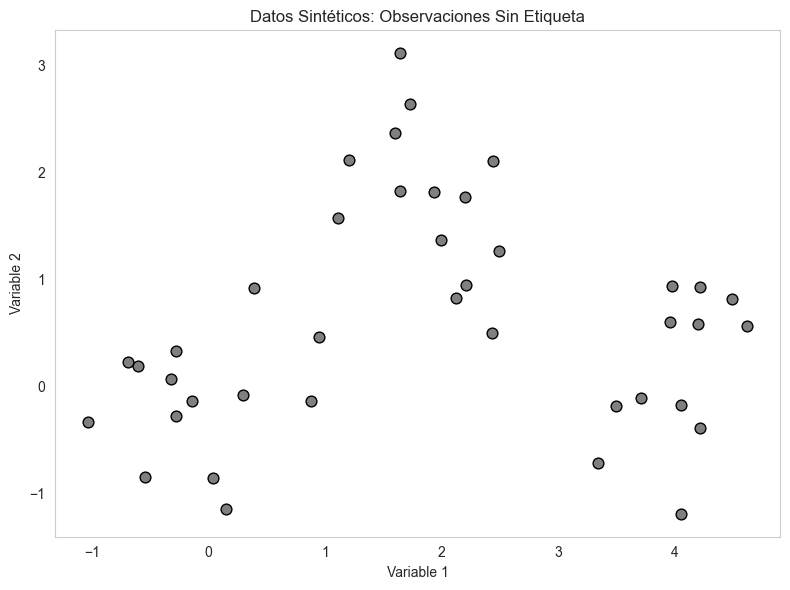


--- MECÁNICA DEL MÉTODO ---

En este ejemplo reducido, K-Means comienza eligiendo 3 centroides iniciales.
Cada punto se asigna al centroide más cercano.
Luego, los centroides se recalculan como la media de los puntos asignados.
Este proceso se repite hasta que los centroides ya no cambian significativamente.



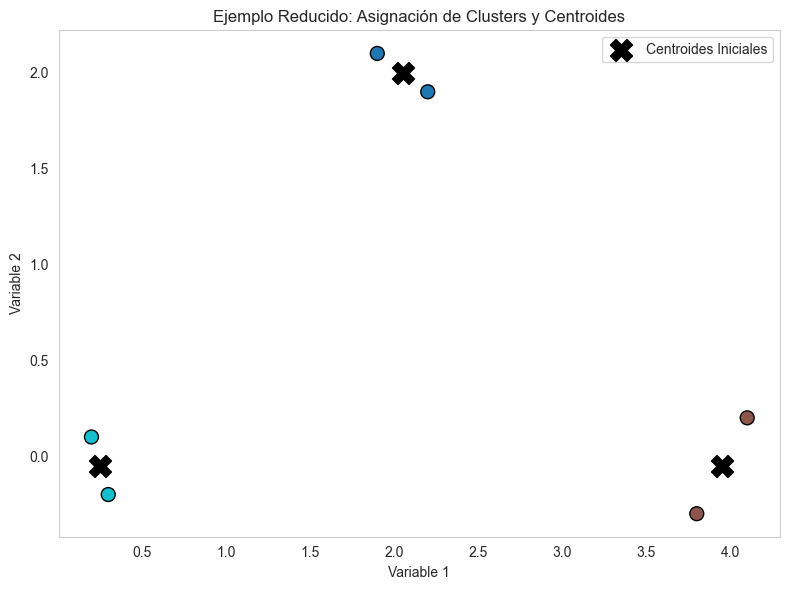

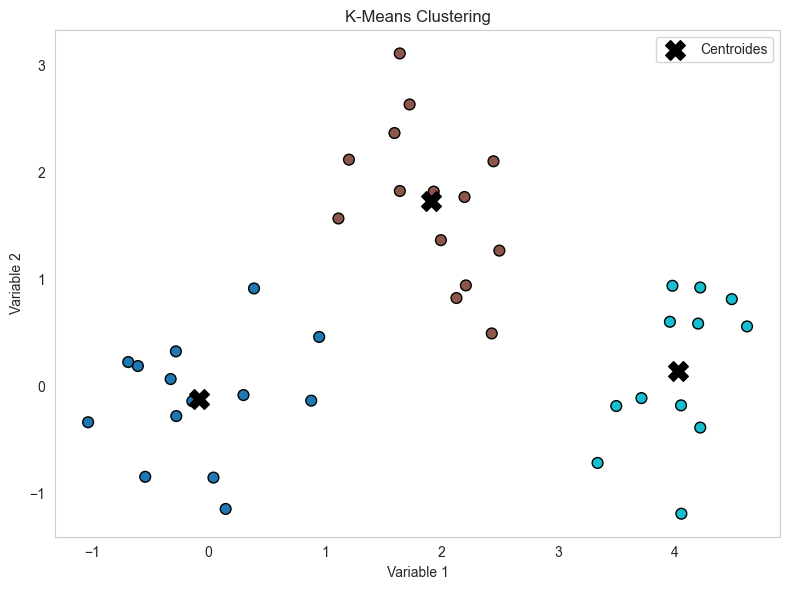


--- DATOS REDUCIDOS ---

Head:
   ClusterKMeans
0              1
1              2
2              0
3              0
4              0

Tail:
    ClusterKMeans
35              2
36              1
37              1
38              2
39              2


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

# Generar datos sintéticos con clusters cercanos y moderada dispersión
X, y_true = make_blobs(
    n_samples=40,
    centers=[(0,0), (2,2), (4,0)],
    cluster_std=0.6,
    random_state=42
)

# Crear DataFrame
df = pd.DataFrame(X, columns=['Variable1', 'Variable2'])
df['ClusterReal'] = y_true

print("\n--- DATOS SINTÉTICOS ---\n")
print("Head:")
print(df[['Variable1', 'Variable2']].head())
print("\nTail:")
print(df[['Variable1', 'Variable2']].tail())

# Gráfico inicial: sin color distintivo
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c='gray', s=60, edgecolor='k')
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.title('Datos Sintéticos: Observaciones Sin Etiqueta')
plt.grid(False)
plt.tight_layout()
plt.show()

# Ejemplo reducido de asignación inicial (sólo 6 puntos)
X_reducido = np.array([
    [0.2, 0.1],
    [0.3, -0.2],
    [1.9, 2.1],
    [2.2, 1.9],
    [4.1, 0.2],
    [3.8, -0.3]
])

# KMeans sobre datos reducidos
kmeans_reducido = KMeans(n_clusters=3, n_init=1, random_state=42)
etiquetas_reducido = kmeans_reducido.fit_predict(X_reducido)

print("\n--- MECÁNICA DEL MÉTODO ---\n")
print(
    "En este ejemplo reducido, K-Means comienza eligiendo 3 centroides iniciales.\n"
    "Cada punto se asigna al centroide más cercano.\n"
    "Luego, los centroides se recalculan como la media de los puntos asignados.\n"
    "Este proceso se repite hasta que los centroides ya no cambian significativamente.\n"
)

# Gráfico del ejemplo reducido
plt.figure(figsize=(8,6))
plt.scatter(
    X_reducido[:,0], 
    X_reducido[:,1], 
    c=etiquetas_reducido, 
    cmap='tab10', 
    s=100, 
    edgecolor='k'
)
plt.scatter(
    kmeans_reducido.cluster_centers_[:,0],
    kmeans_reducido.cluster_centers_[:,1],
    s=250, c='black', marker='X', label='Centroides Iniciales'
)
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.title('Ejemplo Reducido: Asignación de Clusters y Centroides')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Aplicar K-Means
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
clusters_kmeans = kmeans.fit_predict(X)

# Gráfico con clusters asignados por K-Means
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=clusters_kmeans, cmap='tab10', s=60, edgecolor='k')
plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=200, c='black', marker='X', label='Centroides'
)
plt.xlabel('Variable 1')
plt.ylabel('Variable 2')
plt.title('K-Means Clustering')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

# Ejemplo de reducción de dimensionalidad
df['ClusterKMeans'] = clusters_kmeans

print("\n--- DATOS REDUCIDOS ---\n")
print("Head:")
print(df[['ClusterKMeans']].head())
print("\nTail:")
print(df[['ClusterKMeans']].tail())


K-Means Clustering — Mecanismo General

K-Means es un método que agrupa observaciones en k clusters mediante un proceso iterativo de asignación y recálculo de centroides.

Mecánica básica:

1. Elección inicial de k:
   Se define un número de clusters k que es arbitrario y debe elegirse previamente.

2. Inicialización de centroides:
   K-Means selecciona aleatoriamente k puntos que actuarán como centroides iniciales.

3. Asignación:
   Cada observación se asigna al cluster del centroide más cercano (mínima distancia euclidiana).

4. Recálculo de centroides:
   Cada centroide se actualiza como la media de todas las observaciones asignadas a su cluster.

5. Iteración:
   Se repiten los pasos de asignación y recálculo hasta que los centroides dejan de cambiar significativamente o se alcanza el máximo de iteraciones.

Aspecto clave:

- El número de clusters (k) es el principal parámetro del método.
- No existe un único k "correcto"; elegirlo adecuadamente es una cuestión central que afecta todo el resultado.

Próximo paso:
A partir de este punto, se retoman los datos reales y se exploran distintas estrategias para determinar el número óptimo de clusters (k) que refleje la estructura natural de los datos.


In [79]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

df = pd.read_parquet("Data/df_pca.parquet")

inertias = []

rango_clusters = range(2, 15)

for k in rango_clusters:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X_pca)
    inertias.append(kmeans.inertia_)

df_inertia = pd.DataFrame({
    'Clusters': list(rango_clusters),
    'Inercia_Millones': np.array(inertias) / 1e6
})

df_inertia['Reduccion_vs_Anterior_pct'] = (
    (df_inertia['Inercia_Millones'].shift(1) - df_inertia['Inercia_Millones'])
    / df_inertia['Inercia_Millones'].shift(1)
) * 100


from IPython.display import display

print("\n--- INERCIA Y REDUCCIÓN RELATIVA POR NÚMERO DE CLUSTERS ---\n")
display(df_inertia.round(3).reset_index(drop=True))


--- INERCIA Y REDUCCIÓN RELATIVA POR NÚMERO DE CLUSTERS ---



,Clusters,Inercia_Millones,Reduccion_vs_Anterior_pct
0,2,3.0280,NaN
1,3,2.4280,19.8120
2,4,1.9920,17.9420
3,5,1.5600,21.7160
4,6,1.1680,25.0840
5,7,0.8680,25.7120
6,8,0.7840,9.7230
7,9,0.7140,8.8300
8,10,0.6500,9.0190
9,11,0.5800,10.6940


Hasta 7 clusters, las reducciones son de ~25% en cada paso.
	•	Cuando pasas de 7 a 8, la reducción cae drásticamente a ~9.7% (un quiebre fuerte).

    vamos a usar 7 clusters entonces. 
    

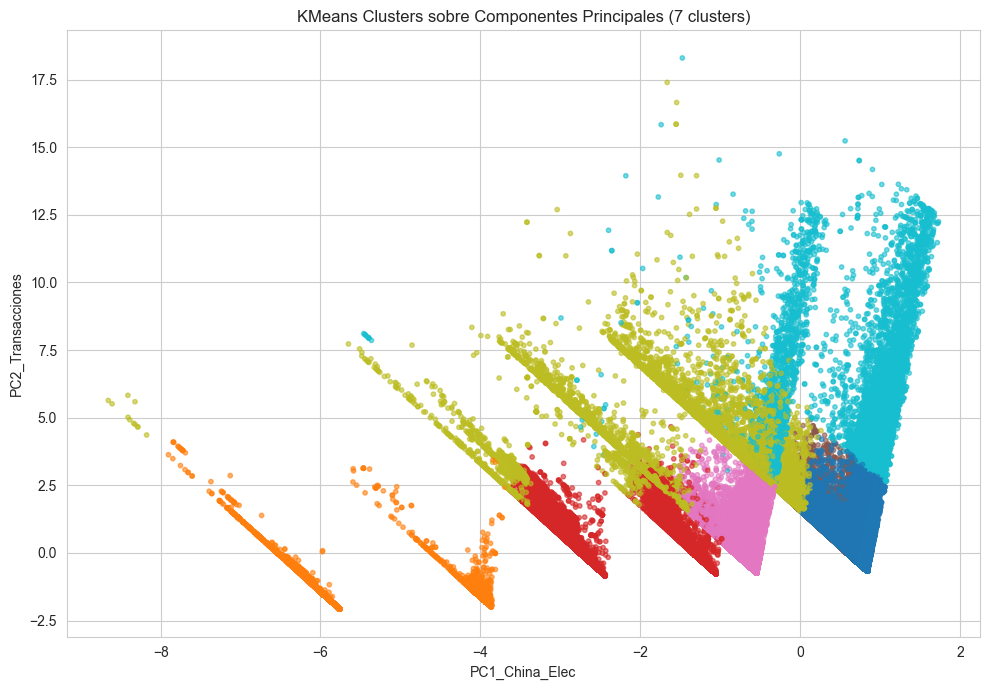

In [80]:
%matplotlib inline

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

kmeans = KMeans(n_clusters=7, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_pca)

df_clusters = pd.DataFrame(X_pca[:, :3], columns=['PC1_China_Elec', 'PC2_Transacciones', 'PC3_Tiempo'])
df_clusters['Cluster'] = clusters

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    df_clusters['PC1_China_Elec'],
    df_clusters['PC2_Transacciones'],
    c=df_clusters['Cluster'],
    cmap='tab10',
    s=10,
    alpha=0.6
)
plt.xlabel('PC1_China_Elec')
plt.ylabel('PC2_Transacciones')
plt.title('KMeans Clusters sobre Componentes Principales (7 clusters)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Entonces, K-Means:

![K-Means Algorithm](kmeans.png)

## Aclaraciones importantes

##### Considerando que:

**k-means es un algoritmo de agrupamiento no supervisado que tiene como objetivo dividir un conjunto de datos en k grupos (clusters)**:

- Cada observación pertenece al cluster cuyo centroide está más cercano (mínima distancia euclídea o similar).
- La varianza interna de cada grupo sea lo menor posible (minimiza la suma de distancias cuadradas dentro de cada cluster).

#### ¿Para qué sirve?

- Identificar segmentos relativamente homogéneos (agrupaciones de observaciones "similares") en datos multidimensionales.
- Explorar patrones y relaciones no evidentes.
- Agrupar datos para tareas de resumen o compresión.
- Inicializar otros métodos de clustering o modelos, o generar inputs para ellos.

## Proceso iterativo No Supervisado:

### 1. Asignación de puntos al centroide más cercano

- Cada punto se clasifica al cluster cuyo centroide tiene menor distancia euclídea (o la métrica que se utilice).
- Este paso no considera dónde están los demás centroides, solo cuál es el más cercano a cada punto.

### 2. Recalculo de centroides

- Una vez reasignados todos los puntos, se recalcula cada centroide como el promedio de todas las observaciones en su cluster.

### 3. Convergencia

Este ciclo se repite hasta que:

- No cambian las asignaciones, o
- La variación de la función objetivo (suma de distancias cuadradas) es menor que un umbral.

## Consideraciones importantes

K-means crea la separación porque los datos están distribuidos de cierta manera en n-dimensiones, no porque busque maximizar explícitamente la distancia entre centroides, u optimizar su separación. La separación de categorías es un resultado indirecto de la mecánica de centroides.

Otros modelos de clustering más complejos como DBSCAN sí optimizan la distancia entre clusters, generando una mecánica explícita de atracción-repulsión (además de otras grandes diferencias, como la emergencia del propio modelo del número de clusters, y no la necesidad de parametrizarlo ex-ante como en k-means).



--- MEDIA DE CADA COMPONENTE POR CLUSTER ---



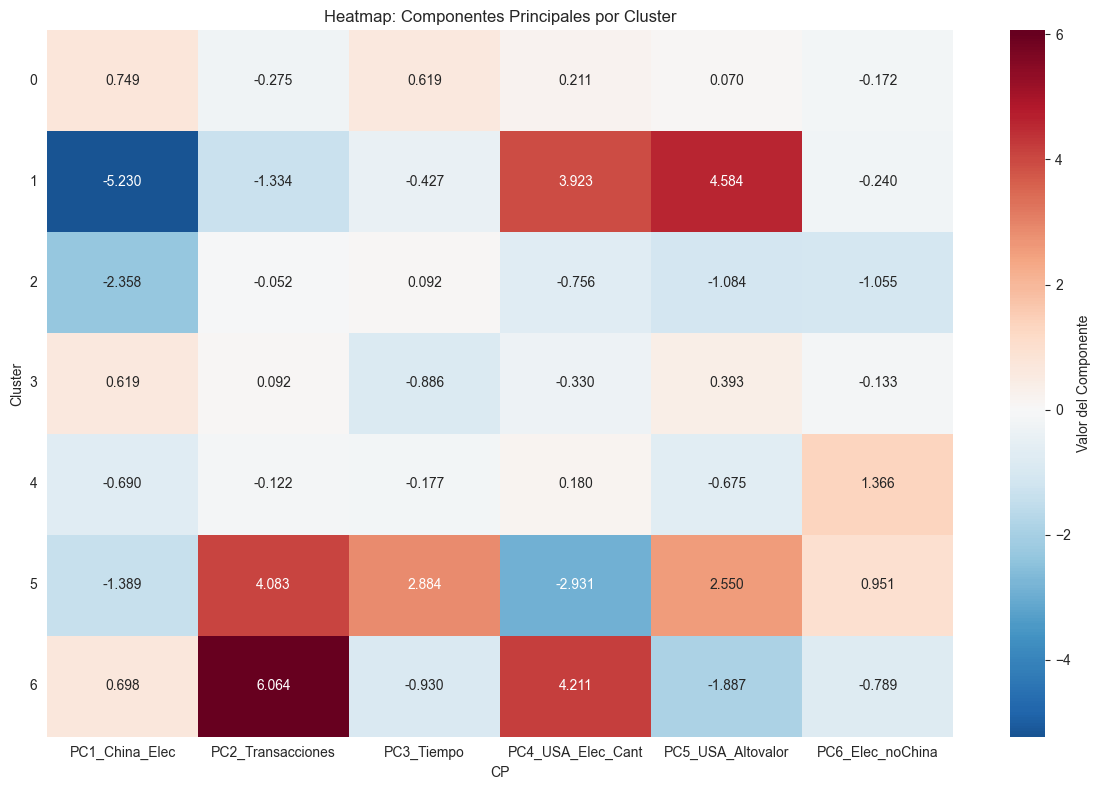

,PC1_China_Elec,PC2_Transacciones,PC3_Tiempo,PC4_USA_Elec_Cant,PC5_USA_Altovalor,PC6_Elec_noChina
Cluster,,,,,,
0,0.7490,-0.2750,0.6190,0.2110,0.0700,-0.1720
1,-5.2300,-1.3340,-0.4270,3.9230,4.5840,-0.2400
2,-2.3580,-0.0520,0.0920,-0.7560,-1.0840,-1.0550
3,0.6190,0.0920,-0.8860,-0.3300,0.3930,-0.1330
4,-0.6900,-0.1220,-0.1770,0.1800,-0.6750,1.3660
5,-1.3890,4.0830,2.8840,-2.9310,2.5500,0.9510
6,0.6980,6.0640,-0.9300,4.2110,-1.8870,-0.7890



--- CLUSTER 0 ---
1. ANIO                                     30.59% (+0.73)
2. PAISDEORIGEN_str_China                   25.52% (+0.61)
3. RAMA_str_ELECTRONICA_ELECTRODOM          15.72% (+0.38)
4. CANTIDADITEM                             11.44% (-0.11)
5. FOBDOLARSITEM                            11.37% (-0.16)
6. PAISDEORIGEN_str_Estados Unidos          5.36% (-0.13)

--- CLUSTER 1 ---
1. PAISDEORIGEN_str_Estados Unidos          60.15% (+7.81)
2. RAMA_str_ELECTRONICA_ELECTRODOM          13.27% (-1.41)
3. PAISDEORIGEN_str_China                   12.64% (-1.64)
4. ANIO                                     7.44% (-0.11)
5. FOBDOLARSITEM                            4.45% (+0.23)
6. CANTIDADITEM                             2.05% (-0.23)

--- CLUSTER 2 ---
1. RAMA_str_ELECTRONICA_ELECTRODOM          44.83% (-2.67)
2. PAISDEORIGEN_str_China                   23.38% (-1.09)
3. ANIO                                     15.94% (-0.10)
4. FOBDOLARSITEM                            9.33% (+0.27)
5. C

In [81]:
import pandas as pd
import numpy as np
import seaborn as sns

# DataFrame con todos componentes y clusters
df_clusters = pd.DataFrame(
    X_pca,
    columns=[
        'PC1_China_Elec',
        'PC2_Transacciones',
        'PC3_Tiempo',
        'PC4_USA_Elec_Cant',
        'PC5_USA_Altovalor',
        'PC6_Elec_noChina'
    ]
)
df_clusters['Cluster'] = clusters

# Medias de cada componente por cluster
resumen_componentes = df_clusters.groupby('Cluster').mean().round(3)

from IPython.display import display

print("\n--- MEDIA DE CADA COMPONENTE POR CLUSTER ---\n")
# Crear heatmap de los componentes por cluster
plt.figure(figsize=(12, 8))
sns.heatmap(resumen_componentes, 
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            fmt='.3f',
            cbar_kws={'label': 'Valor del Componente'})
plt.title('Heatmap: Componentes Principales por Cluster')
plt.xlabel('CP')
plt.ylabel('Cluster')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(resumen_componentes)


import pandas as pd
import numpy as np

# DataFrame con los componentes y cluster
df_comp = pd.DataFrame(
    X_pca[:, :6],
    columns=[
        'PC1',
        'PC2',
        'PC3',
        'PC4',
        'PC5',
        'PC6'
    ]
)
df_comp['Cluster'] = clusters

# Original variables dataframe (not PCA) with cluster
df_vars = df.copy()
df_vars['Cluster'] = clusters

# Variables a usar
variables_componentes = [
    'CANTIDADITEM',
    'FOBDOLARSITEM',
    'ANIO',
    'PAISDEORIGEN_str_China',
    'PAISDEORIGEN_str_Estados Unidos',
    'RAMA_str_ELECTRONICA_ELECTRODOM'
]

# Media global de cada variable
medias_globales = {}
for var in variables_componentes:
    if var in df_vars.columns:
        medias_globales[var] = df_vars[var].mean()

# Resultado
resultados = {}

for cluster in sorted(df_vars['Cluster'].unique()):
    df_cluster = df_vars[df_vars['Cluster'] == cluster]
    sumas_abs = {}
    diferencias_media = {}
    for var in variables_componentes:
        if var in df_cluster.columns:
            suma = df_cluster[var].abs().sum()
            sumas_abs[var] = suma
            media_cluster = df_cluster[var].mean()
            diff = media_cluster - medias_globales[var]
            diferencias_media[var] = diff
    total = sum(sumas_abs.values())
    porcentajes = {
        var: (valor / total * 100) if total > 0 else 0
        for var, valor in sumas_abs.items()
    }
    # Combinar porcentaje y diferencia
    top_vars = sorted(
        [(var, pct, diferencias_media[var]) for var, pct in porcentajes.items()],
        key=lambda x: x[1],
        reverse=True
    )
    resultados[cluster] = (top_vars, 100 - sum(p[1] for p in top_vars))

# Mostrar resultado
for cluster, (top_vars, otras_pct) in resultados.items():
    print(f"\n--- CLUSTER {cluster} ---")
    for i, (var, pct, diff) in enumerate(top_vars, start=1):
        signo = "+" if diff >= 0 else "-"
        print(f"{i}. {var:40s} {pct:.2f}% ({signo}{abs(diff):.2f})")

---

# Qué se está analizando en este código?

## Proceso de cálculo para cada cluster C y variable V:

Para cada cluster, se realizan dos operaciones con las variables originales (no con los componentes):

1. Suma absoluta de cada variable dentro del cluster.
   - Ejemplo: suma de los valores absolutos de CANTIDADITEM en ese cluster.
   - ¿Por qué absolutos? Porque algunas variables pueden ser negativas (por ejemplo, si fueran diferencias), y se requiere medir el "peso" total.
2. Media de cada variable dentro del cluster, comparada con la media global.
   - Ejemplo: media de ANIO en el cluster menos la media de ANIO en todo el dataset.

1. **Extracción de datos**: Se extraen los registros $X_c$ que pertenecen al cluster C.

2. **Cálculo de suma absoluta**:
   - $suma\_abs[V] = \sum |X_c[V]|$

3. **Cálculo de media del cluster**:
   - $media\_cluster[V] = \frac{1}{n_c} \sum X_c[V]$

4. **Cálculo de diferencia con media global**:
   - $diff[V] = media\_cluster[V] - media\_global[V]$

5. **Suma total de valores absolutos**:
   - $total = \sum suma\_abs[V]$

6. **Cálculo de porcentaje por variable**:
   - $porcentaje[V] = (suma\_abs[V] / total) \times 100$

7. **Ordenamiento**: Las variables se ordenan por porcentaje en orden descendente.

---

## Interpretación de resultados:

**Variable ANIO (ejemplo)**:

- **30.59%**: Representa la suma absoluta de ANIO en este cluster dividida por la suma absoluta de todas las variables en este cluster, multiplicada por 100. Indica cuánto contribuye esta variable a la magnitud total del cluster.

- **(+0.73)**: Diferencia de medias. La media de ANIO en este cluster es 0.73 unidades mayor que en el conjunto completo de datos.


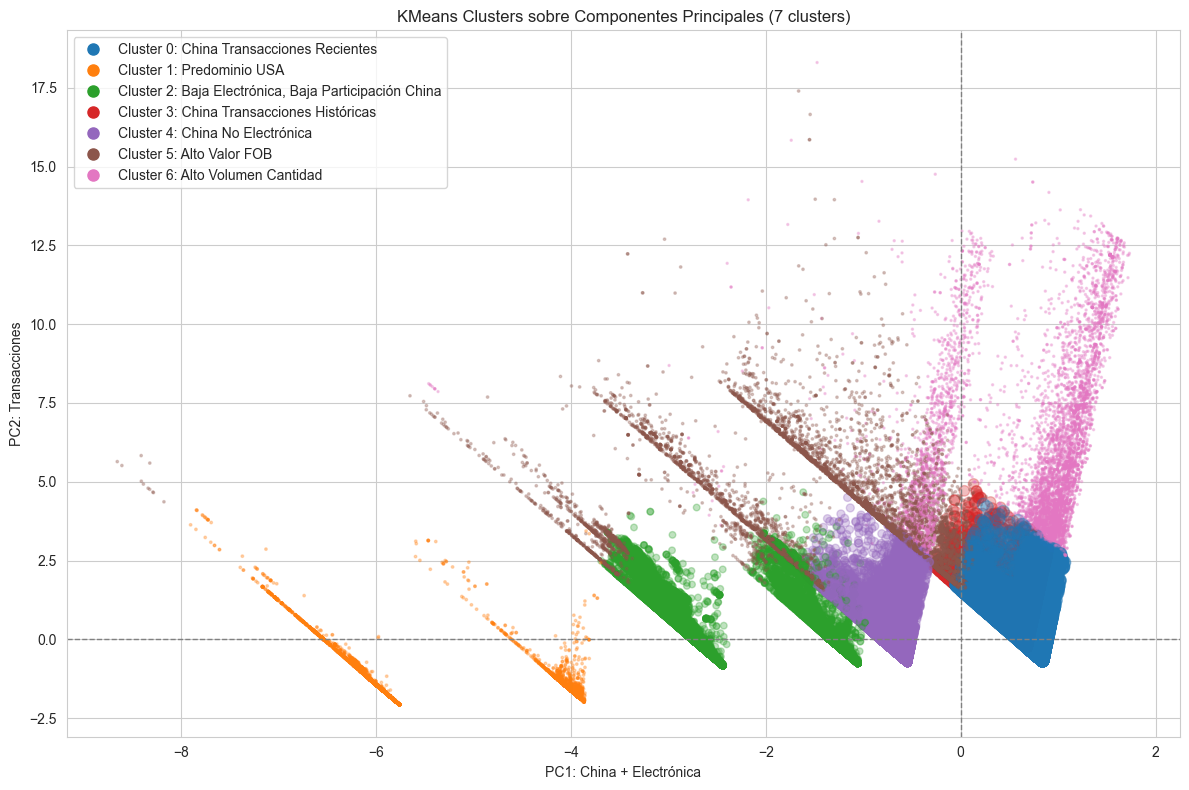

In [82]:
%matplotlib inline

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

# Aplicar KMeans
kmeans = KMeans(n_clusters=7, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_pca)

# Crear DataFrame con componentes principales
df_clusters = pd.DataFrame(
    X_pca[:, :3],
    columns=['PC1_China_Elec', 'PC2_Transacciones', 'PC3_Tiempo']
)
df_clusters['Cluster'] = clusters

# Definir nombres descriptivos de clusters
nombres_clusters = {
    0: "China Transacciones Recientes",
    1: "Predominio USA",
    2: "Baja Electrónica, Baja Participación China",
    3: "China Transacciones Históricas",
    4: "China No Electrónica",
    5: "Alto Valor FOB",
    6: "Alto Volumen Cantidad"
}

# Calcular frecuencias para tamaños de puntos
frecuencias = df_clusters['Cluster'].value_counts(normalize=True).sort_index()
size_scale = 200
sizes = df_clusters['Cluster'].map(lambda x: size_scale * frecuencias[x])

# Configurar colormap
cmap = ListedColormap(cm.tab10.colors[:7])

# Crear visualización
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_clusters['PC1_China_Elec'],
    df_clusters['PC2_Transacciones'],
    c=df_clusters['Cluster'],
    cmap=cmap,
    s=sizes,
    alpha=0.3
)

# Agregar líneas de referencia
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)

# Configurar etiquetas
plt.xlabel('PC1: China + Electrónica')
plt.ylabel('PC2: Transacciones')
plt.title('KMeans Clusters sobre Componentes Principales (7 clusters)')

# Crear leyenda personalizada
handles = []
for idx, name in nombres_clusters.items():
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            color=cmap(idx),
            markersize=8,
            label=f'Cluster {idx}: {name}'
        )
    )
plt.legend(handles=handles, loc='best')

plt.grid(True)
plt.tight_layout()
plt.show()

In [83]:
# Guardamos esto como un parquet para ahorrar trabajo y tiempo más adelante. 
df_clusters_completo = pd.DataFrame(
    X_pca,
    columns=[
        'PC1_China_Elec',
        'PC2_Transacciones',
        'PC3_Tiempo',
        'PC4_USA_Elec_Cant',
        'PC5_USA_Altovalor',
        'PC6_Elec_noChina'
    ]
)
df_clusters_completo['Cluster'] = clusters

# Si quieres también incluir los nombres legibles del cluster
df_clusters_completo['Cluster_Nombre'] = df_clusters_completo['Cluster'].map(nombres_clusters)

# Guardar a parquet
df_clusters_completo.to_parquet("Data/df_pca_clusters.parquet")

print("DataFrame guardado en Data/df_pca_clusters.parquet")

DataFrame guardado en Data/df_pca_clusters.parquet


K-Means y T-SNE

## Propósito principal

- **k-means**: clustering. Indica qué puntos pertenecen al mismo grupo. El resultado son etiquetas de cluster.
- **t-SNE**: reducción de dimensionalidad no lineal. Muestra cómo se verían estos datos si se preservan las relaciones de proximidad local en un plano. El resultado son coordenadas 2D o 3D para graficar.
- **t-SNE** no asigna clusters ni etiquetas de grupo de manera formal.

**Diferencias fundamentales**:
- **k-means** no proyecta: todo sucede en el espacio original.
- **t-SNE** proyecta: toma la alta dimensión y genera un mapeo no lineal a baja dimensión.

**Herramientas complementarias**:
- **k-means**: etiquetar grupos en el espacio original.
- **t-SNE**: visualizar relaciones de proximidad en baja dimensión.

**Combinación frecuente**:
- Primero, t-SNE para proyectar y ver estructura.
- Luego, k-means (sobre los datos originales o reducidos) para definir clusters.

---

## K-Means

### Qué es
- Un algoritmo de clustering no supervisado.
- Agrupa datos en k clusters definidos por centroides.
- Cada observación se asigna al cluster con el centroide más cercano.

### Qué hace
- Encuentra particiones del espacio en regiones compactas.
- Minimiza la inercia (la suma de distancias cuadradas de cada punto a su centroide).

### Resultado
- Etiquetas de cluster discretas (0,1,2…).
- No cambia la dimensionalidad de los datos.

### Aplicación típica
- Detectar segmentos homogéneos en datos multidimensionales.
- Resumir grandes volúmenes de datos en grupos.

---

## T-SNE

### Qué es
- Un algoritmo de reducción de dimensionalidad no supervisado.
- Transforma datos de alta dimensión en 2D o 3D.

### Qué hace
- Preserva la estructura local de los datos (vecindades).
- No define clusters ni centroides: produce una proyección.

### Resultado
- Coordenadas en un espacio reducido (por ejemplo, X e Y en un scatter plot).
- Los colores que se ven habitualmente en t-SNE son solo etiquetas que se aplican posteriormente (por ejemplo, clusters de KMeans).

### Aplicación típica
- Visualizar datos complejos.
- Explorar relaciones de proximidad.

---

## Diferencias Clave

| Aspecto | K-Means | T-SNE |
|---------|---------|-------|
| Tipo de método | Clustering | Reducción de dimensionalidad |
| Salida principal | Etiquetas de cluster | Coordenadas proyectadas |
| Define grupos | Sí | No (solo representación) |
| Métrica interna | Distancia euclídea al centroide | Distribución de proximidades |
| Interpretación | Segmentos homogéneos | Vecindades preservadas |
| Uso posterior típico | Asignar categorías | Visualizar estructuras |
| Sensibilidad a escala | Alta | Media |

---

## Ejemplo sintético

Si se tienen datos de 1000 transacciones:
- **k-means**: indicará "estas 100 son cluster 0, estas 300 cluster 1, estas 600 cluster 2".
- **t-SNE**: dará coordenadas (x,y) que se pueden graficar en 2D; si se colorean por cluster (de k-means u otro método), se ve cómo se distribuyen los grupos en un espacio que preserva relaciones de cercanía.

---

## Diferencia de enfoque probabilístico

- **K-Means**: No hay enfoque probabilístico. Es pura geometría: busca minimizar distancias cuadradas a centroides.
- **T-SNE**: Sí hay enfoque probabilístico: modela la distribución de pares cercanos y busca preservar esas relaciones en menor dimensión.

---

## Diferencias clave (2)

| Aspecto | K-Means | T-SNE |
|---------|---------|-------|
| Cercanía | Distancia a un centroide | Probabilidad de vecindad entre pares |
| Optimización | Suma de distancias cuadradas | Divergencia entre distribuciones |
| Salida | Etiquetas de cluster | Coordenadas 2D/3D |
| Determinismo | Alta | Alta, pero sujeto a aleatoriedad inicial |


## Repreesentación T-SNE



## ¿Qué es?

**t-SNE (t-Distributed Stochastic Neighbor Embedding) es un algoritmo de reducción de dimensionalidad no lineal que transforma datos de alta dimensión en 2 o 3 dimensiones para visualización.**

## Funcionamiento del algoritmo

El algoritmo funciona en dos etapas principales:
### 1. Cálculo de similitudes en alta dimensión

**¿Cómo mide t-SNE la similitud entre observaciones en el espacio original?**

El algoritmo comienza calculando las probabilidades de similitud $p_{ij}$ entre pares de observaciones en el espacio de alta dimensión. Esta similitud se basa en la **distancia euclídea** entre los puntos:

- **Observaciones similares**: Si dos puntos tienen valores muy parecidos en múltiples variables (por ejemplo, ambas empresas tienen ventas similares, mismo sector, mismo país de origen), su distancia euclídea será pequeña. Esto resulta en una **alta probabilidad de similitud $p_{ij}$**, indicando que el algoritmo los considera "vecinos cercanos" en el espacio original.

- **Observaciones diferentes**: Por el contrario, si dos observaciones difieren significativamente en sus características (por ejemplo, una empresa compra electrónicos de China y otra compra autopartes a USA), la distancia euclídea será grande, generando una **baja probabilidad de similitud $p_{ij}$**.

### 2. Optimización en baja dimensión

**¿Cómo crea t-SNE la representación visual en 2D o 3D?**

Una vez calculadas las similitudes originales, t-SNE crea una representación en baja dimensión (típicamente 2D) donde cada observación obtiene nuevas coordenadas. La clave está en usar una **distribución t de Student** para medir similitudes en este espacio reducido:

- **Ventaja de la distribución t**: A diferencia de la distribución gaussiana usada en alta dimensión, la distribución t tiene **colas más pesadas**. Esto significa que puntos muy alejados ejercen menos influencia en la optimización, evitando que "arrastren" a otros puntos hacia ellos.


**Proceso de optimización iterativo**:

El algoritmo ajusta las posiciones en 2D para que las similitudes $q_{ij}$ reflejen lo mejor posible las similitudes originales $p_{ij}$:

- **Atracción**: Si dos puntos tenían alta similitud en alta dimensión ($p_{ij}$ alta) pero están lejos en 2D ($q_{ij}$ baja), se atraen mutuamente
- **Repulsión**: Si dos puntos tenían baja similitud original ($p_{ij}$ baja) pero están muy cerca en 2D ($q_{ij}$ alta), se repelen

**Beneficio de las colas pesadas**: Las colas largas de la distribución t evitan que puntos muy diferentes en alta dimensión colapsen en el mismo lugar en 2D, creando **separaciones visuales claras** entre grupos distintos de observaciones.

**Función de pérdida**: El algoritmo minimiza la divergencia de Kullback-Leibler entre las distribuciones $P$ y $Q$: $KL(P||Q) = \sum_{i,j} p_{ij} \log \frac{p_{ij}}{q_{ij}}$

## Características principales

- **Preservación de vecindades locales**: Puntos que estaban cerca en alta dimensión siguen cerca en la proyección
- **Separación de grupos distintos**: Observaciones diferentes quedan bien separadas
- **Visualización efectiva**: Produce gráficos donde grupos similares quedan agrupados

## Aplicaciones

- Visualizar clusters o patrones que PCA no capta
- Reducir alta dimensión a 2D o 3D para exploración
- **Importante**: No usar para modelado predictivo (solo exploratorio)

## T-SNE para visualización

El resultado final es un mapa donde observaciones semejantes quedan agrupadas y observaciones distintas aparecen bien separadas, reflejando las relaciones de proximidad originales pero en un plano fácil de visualizar.

In [44]:
import pandas as pd
from funciones.describe_vars2 import describe_vars

df_tsne = pd.read_parquet("Data/df_pca_clusters.parquet") #importamos el ultimo df con los clusters
X_pca = df_tsne.iloc[:, :6].values  # Las 6 componentes
clusters = df_tsne['Cluster']       # Etiquetas numéricas
cluster_nombres = df_tsne['Cluster_Nombre']  # Etiquetas de texto si las querésdescribe_vars(df_pca_cargado)

describe_vars(df_tsne)

,Columna,Tipo,Nulos,Únicos,Valores_Muestra
0,PC1_China_Elec,float64,0,458452,None
1,PC2_Transacciones,float64,0,458452,None
2,PC3_Tiempo,float64,0,458452,None
3,PC4_USA_Elec_Cant,float64,0,458452,None
4,PC5_USA_Altovalor,float64,0,458452,None
5,PC6_Elec_noChina,float64,0,458452,None
6,Cluster,int32,0,7,"[3, 2, 1, 6, 5]"
7,Cluster_Nombre,object,0,7,"[China Transacciones Históricas, Baja Electrón..."


,count,mean,std,min,25%,50%,75%,max
PC1_China_Elec,642174.0000,-0.0000,1.2700,-8.6500,-0.6400,0.6500,0.7400,1.7300
PC2_Transacciones,642174.0000,0.0000,1.0400,-2.0700,-0.4100,-0.2200,0.0200,18.3000
PC3_Tiempo,642174.0000,-0.0000,1.0100,-3.5700,-0.7500,-0.0100,0.7300,7.3000
PC4_USA_Elec_Cant,642174.0000,-0.0000,0.9500,-7.1800,-0.3300,-0.0400,0.2500,10.4900
PC5_USA_Altovalor,642174.0000,0.0000,0.9200,-5.2600,-0.4300,0.0700,0.2900,9.3800
PC6_Elec_noChina,642174.0000,-0.0000,0.7500,-4.0800,-0.1900,-0.1500,-0.1000,3.4500
Cluster,642174.0000,1.8900,1.6900,0.0000,0.0000,2.0000,3.0000,6.0000


### El enfoque más usado: PCA ➜ t-SNE.

=== CARGA DE PCA DESDE PARQUET ===
Shape de X_pca: (642174, 6)


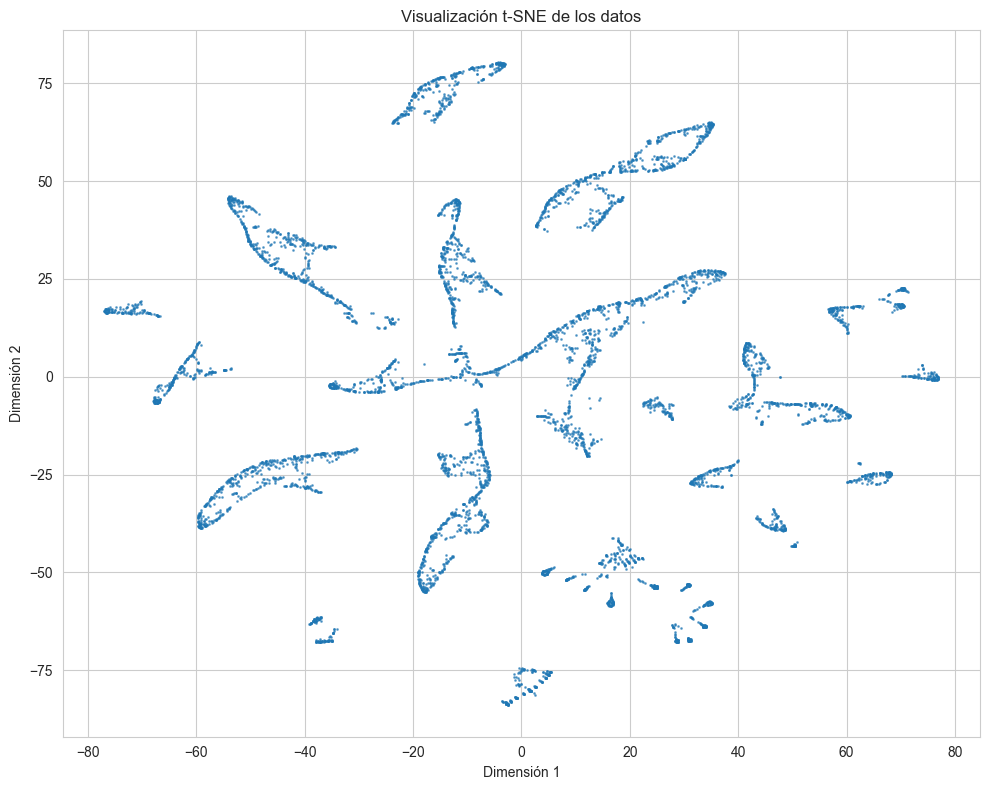

In [90]:
import warnings
# versión más simple y rústica, sin etiquetas de cluster

print("=== CARGA DE PCA DESDE PARQUET ===")
df_pca_cargado = pd.read_parquet("pca_results.parquet")
X_pca = df_pca_cargado.values

print("Shape de X_pca:", X_pca.shape)

# Configurar t-SNE
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

def visualizar_tsne_basico(
    X,
    random_state=42,
    n_iter=250,
    perplexity=30,
    sample_frac=0.05,
    learning_rate=200,          # Controla la velocidad de convergencia del algoritmo
    early_exaggeration=12       # Aumenta la separación inicial entre grupos
):
    np.random.seed(random_state)
    
    n_samples = int(X.shape[0] * sample_frac)
    n_samples = max(n_samples, 1)
    if X.shape[0] > n_samples:
        idx = np.random.choice(X.shape[0], size=n_samples, replace=False)
        X_sub = X[idx]
    else:
        X_sub = X

    tsne = TSNE(
        n_components=2,
        random_state=random_state,
        n_iter=n_iter,
        perplexity=perplexity,
        learning_rate=learning_rate,               # Controla la velocidad de convergencia del algoritmo
        early_exaggeration=early_exaggeration     # Aumenta la separación inicial entre grupos
    )
    X_embedded = tsne.fit_transform(X_sub)

    plt.figure(figsize=(10, 8))
    plt.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.6, s=1)
    plt.title('Visualización t-SNE de los datos')
    plt.xlabel('Dimensión 1')
    plt.ylabel('Dimensión 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Ejecutar visualización
visualizar_tsne_basico(
    X_pca,
    random_state=42,        # Controla la reproducibilidad de los resultados (cualquier entero)
    n_iter=1000,           # Número de iteraciones para la optimización (250-2000)
    # Más iteraciones = mejor convergencia pero más tiempo de cómputo
    perplexity=50,         # Balance entre estructura local y global (5-50)
    # Valores bajos = estructura local, valores altos = estructura global
    sample_frac=0.01,      # Fracción de datos a usar para acelerar el proceso (0.01-1.0)
    # Valores menores = más rápido pero menos representativo
    learning_rate=500,     # Controla la velocidad de convergencia del algoritmo (10-1000)
    # Valores altos = convergencia rápida pero inestable, valores bajos = lento pero estable
    early_exaggeration=50  # Aumenta la separación inicial entre grupos (1-50)
    # Valores altos = mejor separación de clusters pero puede causar inestabilidad
)




# === SUPRIMIR WARNINGS DE UMAP ===
def suppress_common_warnings():
    """Suprime warnings comunes de sklearn y otras librerías de ML"""
    warnings.filterwarnings(
        "ignore",
        category=FutureWarning,
        message=".*force_all_finite.*"
    )
    warnings.filterwarnings(
        "ignore",
        category=UserWarning,
        message=".*n_jobs value 1 overridden.*"
    )
    warnings.filterwarnings(
        "ignore",
        category=FutureWarning,
        message=".*'n_iter' was renamed to 'max_iter'.*"
    )

# quitar warnings
suppress_common_warnings()



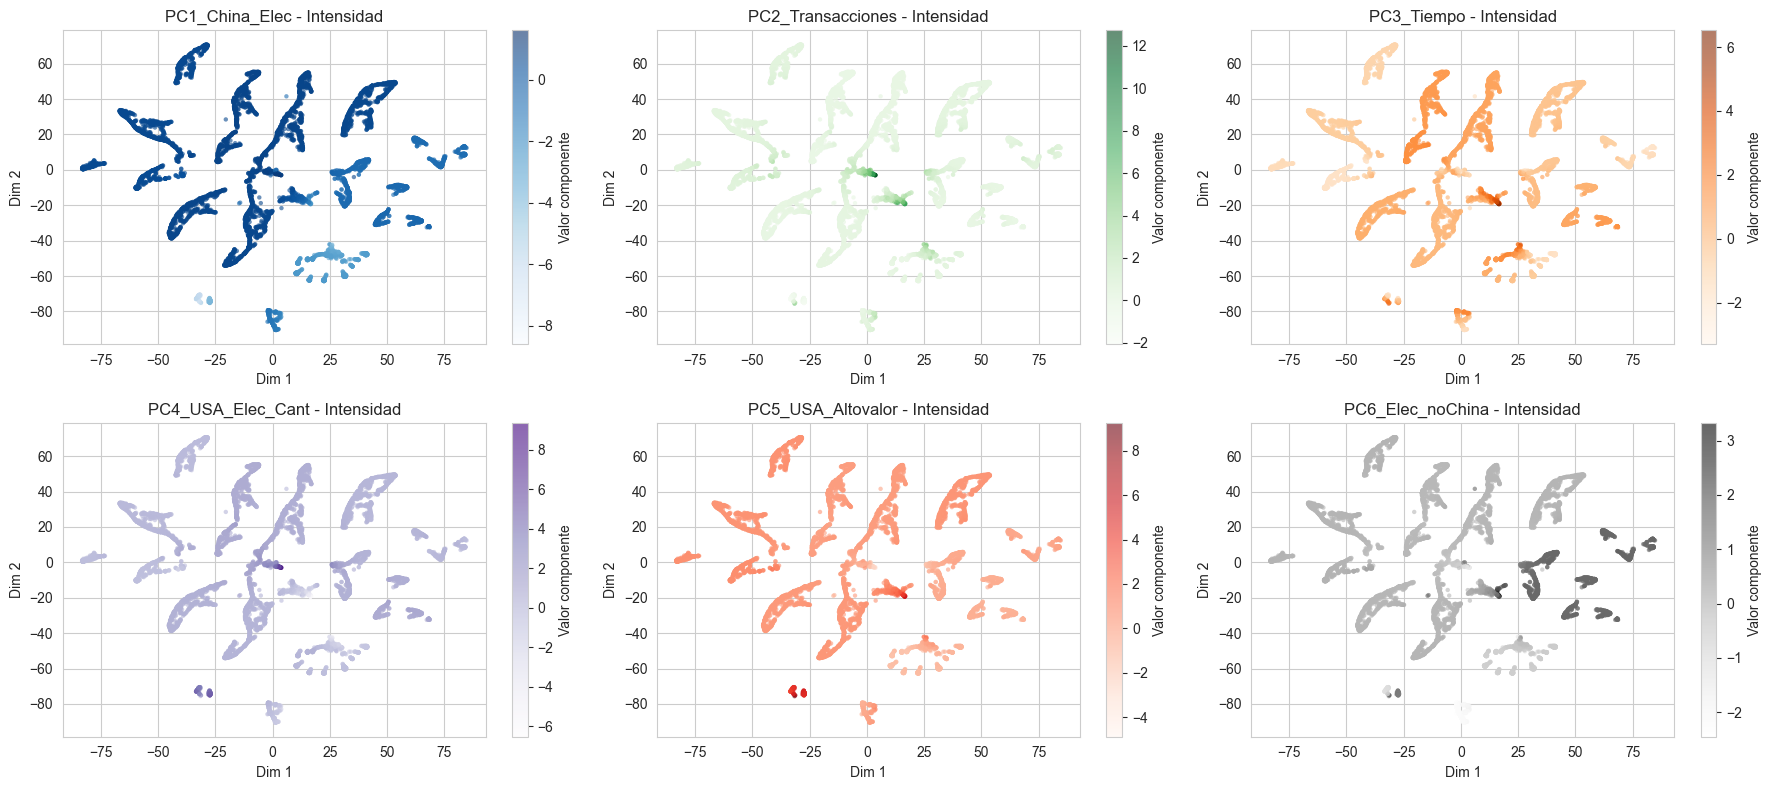

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


# === SUPRIMIR WARNINGS DE UMAP ===
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*force_all_finite.*"
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*n_jobs value 1 overridden.*"
)



# Cargar parquet con las etiquetas, tanto de PCA como de cluster 
df_tsne = pd.read_parquet("Data/df_pca_clusters.parquet")
X_pca = df_tsne.iloc[:, :6].values

# Muestra
np.random.seed(42)
sample_frac = 0.01
n_samples = max(int(X_pca.shape[0] * sample_frac), 1)
idx = np.random.choice(X_pca.shape[0], size=n_samples, replace=False)

X_sub = X_pca[idx]

# t-SNE único
tsne = TSNE(
    n_components=2,
    random_state=42,
    n_iter=1000,
    perplexity=50,
    learning_rate=500,
    early_exaggeration=50
)
X_embedded = tsne.fit_transform(X_sub)

# Subplots de intensidad de componentes sin etiquetas de cluster
component_names = [
    'PC1_China_Elec',
    'PC2_Transacciones',
    'PC3_Tiempo',
    'PC4_USA_Elec_Cant',
    'PC5_USA_Altovalor',
    'PC6_Elec_noChina'
]
cmap_list = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 'Greys']

plt.figure(figsize=(6 * 3, 4 * 2))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    colores = X_sub[:, i]
    sc = plt.scatter(
        X_embedded[:, 0],
        X_embedded[:, 1],
        c=colores,
        cmap=cmap_list[i],
        alpha=0.6,
        s=10,
        edgecolors='none'
    )
    plt.title(f"{component_names[i]} - Intensidad")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.colorbar(sc, label="Valor componente")
    plt.grid(True)

plt.tight_layout()
plt.show()

### Qué aporta la visualización t-SNE respecto del PCA

Cuando se realiza un análisis de PCA y se examina únicamente la tabla de cargas (componentes vs features) y la varianza explicada de cada componente, se obtiene información sobre:

- Qué combinación de variables forma cada componente
- Cuánta varianza global captura cada componente

Sin embargo, no se puede determinar cómo se distribuyen esas componentes a nivel de observaciones.

La visualización t-SNE permite observar:

1. Si los casos con valores altos de una componente forman un conjunto compacto (es decir, si se parecen en el espacio total)
2. Si esos casos están dispersos por toda la proyección, lo que indicaría que ese patrón es más difuso
3. Si hay regiones donde varias componentes se solapan, mostrando relaciones entre patrones latentes

---
## Algunas cuestiones clave:
#### Qué significa que un grupo de puntos esté junto y tenga alta intensidad en PC2?

Cuando se observa que un subconjunto concentrado está coloreado con intensidad en PC2, se está viendo que:

- Esas observaciones tienen una configuración de variables original que produce un valor alto de PC2
- Además, esas observaciones son similares entre sí considerando todas las componentes simultáneamente, porque t-SNE preserva la vecindad local
- En términos prácticos: probablemente comparten características comunes (volumen, origen, temporalidad) que no necesariamente son evidentes mirando sólo PC2 como vector

Dicho de forma sencilla:
Están juntas porque son parecidas en la estructura multivariada y el color indica que, dentro de esa similitud, comparten un nivel alto de PC2.

#### Qué significa que en PC1 toda la proyección esté intensa?

Cuando casi toda la proyección tiene color intenso en un componente (por ejemplo, PC1), indica que:

- Esa componente es la principal fuente de variabilidad que atraviesa todo el dataset
- Las diferencias de valor absoluto de PC1 son amplias y están distribuidas globalmente
- El patrón que representa (en este caso, por ejemplo, China/Electrónica) es estructural y define la mayoría de casos

Por contraste:

- Los patrones de componentes como PC2 se restringen a regiones específicas (casos particulares que presentan ese patrón de forma acentuada)
- PC1 "impregna" toda la nube de datos, por eso no se ve un grupo limitado

---

## ¿Hay patrones opuestos?

Si se comparan dos componentes:

- Uno con color uniforme en toda la proyección (PC1) y otro con color concentrado en un bloque pequeño (PC2), eso indica que:
- El primero refleja una tendencia general que afecta casi todas las observaciones
- El segundo es un patrón diferencial específico de un subconjunto

Esto es una ventaja de t-SNE:

- En PCA se podría saber que ambos componentes tienen peso, pero no se vería qué tan localizado o generalizado es cada patrón
- t-SNE muestra la estructura espacial de esas diferencias en alta dimensión

Lo que la visualización está indicando es:

- PC1 representa un patrón dominante que atraviesa todo el dataset
- PC2 identifica un bloque compacto de observaciones que presentan un rasgo distintivo
- El hecho de que esos puntos estén juntos en la proyección confirma que no es un efecto espurio: esos casos son multivariadamente semejantes y comparten la característica de PC2

Este es el valor principal: no sólo ver la varianza, sino ver cómo se distribuyen los patrones en el conjunto y qué casos se asocian a cada eje.

Si se desea, se puede profundizar o cruzar estas zonas con otras variables categóricas.

=== CARGA DE PCA DESDE PARQUET ===
Shape de X_pca: (642174, 6)


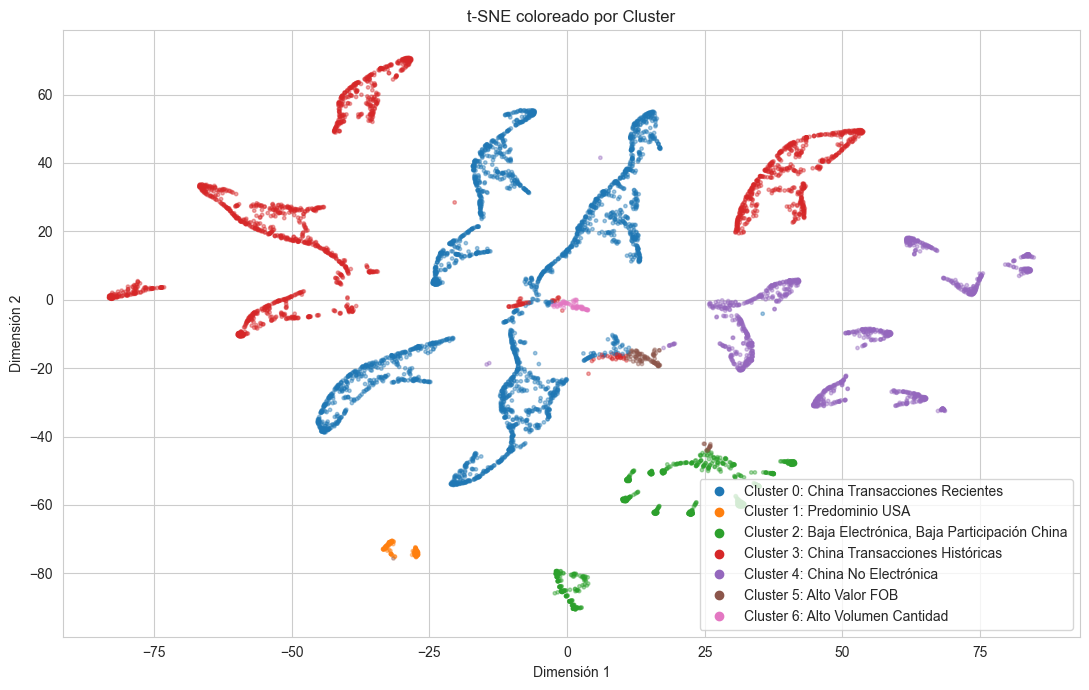

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from matplotlib import cm
from matplotlib.colors import ListedColormap
import warnings

# === SUPRIMIR WARNINGS DE UMAP ===
def suppress_common_warnings():
    """Suprime warnings comunes de sklearn y otras librerías de ML"""
    warnings.filterwarnings(
        "ignore",
        category=FutureWarning,
        message=".*force_all_finite.*"
    )
    warnings.filterwarnings(
        "ignore",
        category=UserWarning,
        message=".*n_jobs value 1 overridden.*"
    )
    warnings.filterwarnings(
        "ignore",
        category=FutureWarning,
        message=".*'n_iter' was renamed to 'max_iter'.*"
    )

# quitar warnings
suppress_common_warnings()




# === CARGA DEL PARQUET CON CLUSTERS ===
print("=== CARGA DE PCA DESDE PARQUET ===")
df_tsne = pd.read_parquet("Data/df_pca_clusters.parquet")
X_pca = df_tsne.iloc[:, :6].values
clusters = df_tsne['Cluster']
cluster_nombres = df_tsne['Cluster_Nombre']

print("Shape de X_pca:", X_pca.shape)

# === t-SNE + Muestra aleatoria ===
np.random.seed(42)
sample_frac = 0.01
n_samples = int(X_pca.shape[0] * sample_frac)
n_samples = max(n_samples, 1)

idx = np.random.choice(X_pca.shape[0], size=n_samples, replace=False)
X_sub = X_pca[idx]
clusters_sub = clusters.iloc[idx].reset_index(drop=True)
nombres_sub = cluster_nombres.iloc[idx].reset_index(drop=True)

# t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    n_iter=1000,
    perplexity=50,
    learning_rate=500,
    early_exaggeration=50
)
X_embedded = tsne.fit_transform(X_sub)

# Colormap consistente
cmap = ListedColormap(cm.tab10.colors[:7])

# === GRÁFICO: Con color por cluster ===
plt.figure(figsize=(11, 7))
scatter = plt.scatter(
    X_embedded[:, 0],
    X_embedded[:, 1],
    c=clusters_sub, # <--- clusters_sub es el vector de clusters
    cmap=cmap,
    s=6,
    alpha=0.4
)
plt.title('t-SNE coloreado por Cluster')
plt.xlabel('Dimensión 1')
plt.ylabel('Dimensión 2')

# Leyenda: colores extraídos del cmap usando el entero idx
handles = []
unique_clusters_sorted = sorted(clusters_sub.unique())
for idx in unique_clusters_sorted:
    nombre = nombres_sub[clusters_sub==idx].iloc[0]
    color = cmap(idx)  # Aquí se toma el color correcto
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            color=color,
            label=f"Cluster {idx}: {nombre}",
            markersize=6
        )
    )
plt.legend(handles=handles, loc='best')

plt.grid(True)
plt.tight_layout()
plt.show()

**¿Qué se observa en este gráfico?**

Este gráfico muestra la agrupación final de observaciones según K-Means, proyectada en 2 dimensiones con t-SNE.
Específicamente:
- Cada punto: una observación.
- El color: la etiqueta de cluster asignada por K-Means (categórica).
- La forma y posición: la estructura de similitud en el espacio reducido.

Esto permite ver:
- Qué observaciones quedaron agrupadas en el mismo cluster.
- La separación relativa de grupos en la representación t-SNE.
- Cómo se organizan las categorías dominantes en la base de datos.

---

**Diferencia conceptual con los paneles de componentes**

| Aspecto | Gráfico por Cluster | Gráficos de Componentes |
|---------|-------------------|------------------------|
| Qué colorea el punto | La etiqueta de cluster (categoría discreta) | El valor continuo de cada componente principal |
| Qué significa el color | A qué agrupamiento pertenece el punto | Cuánto "pesa" la dimensión latente en la observación |
| Qué revela | La segmentación homogénea de K-Means | Las zonas donde cada componente explica más la variabilidad |
| Cómo interpretarlo | Grupos comparativos de comportamiento o perfil | Gradientes de intensidad en dimensiones específicas |
| Visualización | Paleta cualitativa (tab10) con etiquetas y leyenda | Paleta secuencial por componente |

---

**Ejemplo concreto**

En este gráfico de clusters:
- Si un punto es verde, pertenece al Cluster 2 (Baja Electrónica, Baja Participación China).
- Todos los puntos verdes comparten ciertas características que K-Means identificó como cercanas.
- La posición refleja similitud multidimensional proyectada en 2D, pero el color muestra su categoría final.

En los gráficos de componentes:
- Si un punto es muy oscuro en el panel de PC1, significa que tiene un alto valor de China + Electrónica.
- El mismo punto, en el panel de PC4, puede ser claro (bajo en USA + Electrónica + Cantidad).
- Cada panel muestra una dimensión distinta, no la etiqueta del cluster.

---

**Interpretación combinada**

Si se combinan ambas visualizaciones se pueden responder preguntas como:
- ¿Qué componente explica que este grupo se separe tanto en t-SNE?
- ¿Qué variable subyace detrás de la formación de este cluster?
- ¿Dónde se concentran las observaciones con alta participación de China o alto valor FOB?



**Este enfoque integrado (clusters + componentes)  permite:**
- Ver qué grupos emergen del clustering no supervisado.
- Comprender por qué esos grupos están separados.
- Identificar la composición latente detrás de cada cluster.



| Criterio | PCA | t‑SNE | UMAP |
|----------|-----|-------|------|
| Tipo de reducción | Lineal | No lineal | No lineal |
| Preserva estructura global | Muy bien (por ser lineal) | Pobre (distorsiona distancias grandes) | Mejor que t‑SNE (mantiene cierta estructura global) |
| Preserva estructura local (vecindades) | Limitado | Excelente | Excelente |
| Interpretabilidad | Alta: cada componente es combinación lineal de features originales | Baja: no hay interpretación de ejes | Baja: no hay interpretación de ejes |
| Velocidad en datasets grandes | Muy alta (muy rápido) | Muy lenta | Rápida |
| Escalabilidad | Escala bien a millones de puntos | Escala mal (RAM y tiempo crecen exponencialmente) | Escala bien (soporta millones de puntos) |
| Reproducibilidad | 100% reproducible | Poca (aleatoriedad y sensibilidad a parámetros) | Mejor que t‑SNE, pero algo aleatorio |
| Parámetros principales | Ninguno crítico | Perplexity, learning rate, iteraciones | n_neighbors, min_dist |
| Uso más común | Preprocesamiento y visualización lineal | Visualización exploratoria 2D de clusters | Visualización exploratoria y reducción dimensional estable |
| Capacidad de transformar nuevos datos | Sí | No | Sí |
| Visualización de clusters complejos | Limitada | Excelente (clustering visual claro) | Excelente (clustering visual claro) |
| Conserva varianza | Sí (se cuantifica la varianza por componente) | No | No |
| Dependencia del número de dimensiones originales | Alta (más dimensiones, más varianza a capturar) | No depende directamente | No depende directamente |
| Estabilidad de embeddings | Muy estable | Poca | Buena |


### Importante

Lo que se está realizando es:

- Reducción de dimensionalidad (PCA, t-SNE): crear nuevas representaciones
- Exploración de estructura: identificar agrupamientos latentes
- Opcionalmente, segmentación no supervisada si se decide aplicar clustering sobre las proyecciones

Por eso se dice que este proceso es exploratorio y no supervisado. Si después se decide asignar etiquetas de clúster y usarlas como clases, allí se pasa a la clasificación.

## Integración al dataframe original

### PCA

- Para cada observación, el PCA devuelve los valores proyectados sobre cada componente
- Se pueden incorporar estos valores al dataframe original como nuevas columnas:
  - PC1, PC2, PC3, etc.
- Estas columnas pueden utilizarse como:
  - Variables predictoras en modelos
  - Factores de segmentación
  - Inputs para clustering (k-means, DBSCAN)

### t-SNE

- También devuelve para cada observación dos coordenadas de proyección:
  - tSNE1 y tSNE2
- Se pueden agregar al dataframe original
- La diferencia clave:
  - Estas coordenadas no son interpretables como combinación lineal de features
  - Solo expresan relaciones de vecindad: si dos observaciones tienen coordenadas similares, son parecidas considerando todas las dimensiones originales
  - No deben usarse como variables predictoras sin precaución, porque t-SNE no es un método supervisado

### ¿Qué utilidad tiene integrarlas?

- Etiquetar cada observación con su ubicación t-SNE permite identificar con qué grupo comparte similitud
- Se pueden clasificar observaciones nuevas asignándolas a la proyección
- Se puede segmentar el dataset según áreas del mapa
- Casos donde la prioridad absoluta es resaltar la estructura local, aunque la global quede distorsionada


¿Por qué UMAP se prefiere sobre t-SNE en muchos casos?

1. **Velocidad y escalabilidad**
   - t-SNE se vuelve extremadamente lento a partir de decenas de miles de observaciones
   - UMAP es mucho más rápido y escala bien a millones de registros

2. **Reproducibilidad**
   - t-SNE es sensible a inicializaciones aleatorias y parámetros (por ejemplo, perplexity), por lo que puede dar resultados distintos en ejecuciones repetidas
   - UMAP es más estable y menos dependiente de hiperparámetros

3. **Preservación de estructura global**
   - t-SNE prioriza la estructura local (vecindad inmediata), pero distorsiona mucho las relaciones globales (distancias entre grupos)
   - UMAP preserva mejor un equilibrio entre estructura local y global. Se puede observar no solo quién está cerca de quién, sino cómo se relacionan los conglomerados entre sí

4. **Transformación de datos nuevos**
   - t-SNE no permite proyectar datos nuevos sobre un mapa entrenado
   - UMAP sí tiene una implementación que permite "transform" y obtener coordenadas nuevas consistentes con las anteriores

5. **Control de la granularidad**
   - UMAP ofrece hiperparámetros (n_neighbors, min_dist) que permiten controlar de manera más interpretable cuán compacto o disperso es el resultado

Shape del array recibido: (642174, 6)
Shape después de muestreo: (6421, 6)


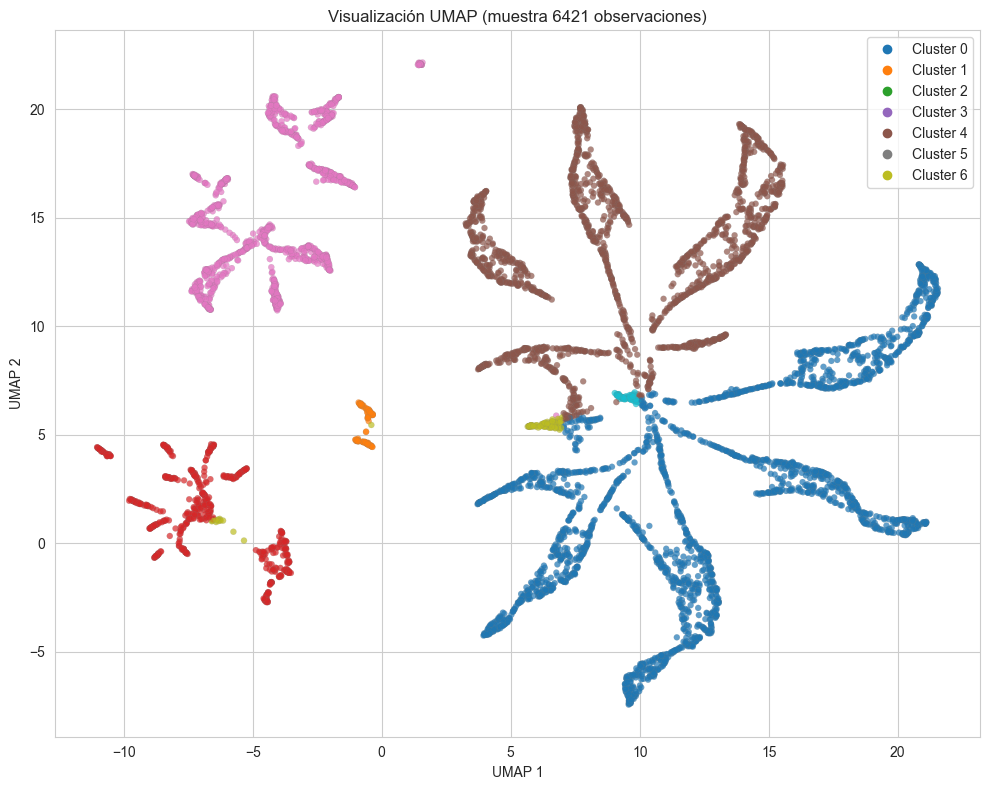

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
import warnings

# === SUPRIMIR WARNINGS DE UMAP ===
suppress_common_warnings()

# === CARGA DEL DATASET CONSISTENTE CON t-SNE ===
df_tsne = pd.read_parquet("Data/df_pca_clusters.parquet")
X_pca = df_tsne.iloc[:, :6].values
clusters = df_tsne['Cluster']

# === FUNCIÓN DE VISUALIZACIÓN UMAP ===
def visualizar_umap(
    X,
    etiquetas=None,
    random_state=42,
    n_neighbors=50,   # Similar a perplexity=50 de t-SNE
    min_dist=0.6,     # Separación media entre clusters
    sample_frac=0.01  # Misma fracción de muestra que usaste en t-SNE
):
    print("Shape del array recibido:", X.shape)

    if X.shape[1] != 6:
        raise ValueError(f"Error: este script espera exactamente 6 componentes, pero recibió {X.shape[1]} columnas.")

    np.random.seed(random_state)

    n_samples = max(int(X.shape[0] * sample_frac), 1)
    if X.shape[0] > n_samples:
        idx = np.random.choice(X.shape[0], size=n_samples, replace=False)
        X_sub = X[idx]
        etiquetas_sub = np.array(etiquetas)[idx] if etiquetas is not None else None
    else:
        X_sub = X
        etiquetas_sub = etiquetas

    print("Shape después de muestreo:", X_sub.shape)

    reducer = umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        n_components=2,
        random_state=random_state
    )
    X_embedded = reducer.fit_transform(X_sub)

    # === GRAFICAR ===
    plt.figure(figsize=(10, 8))
    if etiquetas_sub is not None:
        scatter = plt.scatter(
            X_embedded[:, 0],
            X_embedded[:, 1],
            c=etiquetas_sub,
            cmap="tab10",
            alpha=0.7,
            s=19.5,
            edgecolors="gray",
            linewidth=0.1
        )
        # Leyenda
        unique_labels = np.unique(etiquetas_sub)
        handles = []
        for lbl in sorted(unique_labels):
            color = scatter.cmap(lbl / len(unique_labels))
            handles.append(
                plt.Line2D(
                    [0], [0],
                    marker='o',
                    linestyle='',
                    color=color,
                    label=f"Cluster {lbl}",
                    markersize=6
                )
            )
        plt.legend(handles=handles, loc="best")
    else:
        plt.scatter(
            X_embedded[:, 0],
            X_embedded[:, 1],
            alpha=0.2,
            s=15.5,
            edgecolors="gray",
            linewidth=0.1
        )

    plt.title(f"Visualización UMAP (muestra {n_samples} observaciones)")
    plt.xlabel("UMAP 1")
    plt.ylabel("UMAP 2")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# === EJECUTAR VISUALIZACIÓN UMAP ===
visualizar_umap(
    X_pca,
    etiquetas=clusters,
    random_state=42,
    n_neighbors=50,
    min_dist=0.3,
    sample_frac=0.01
)

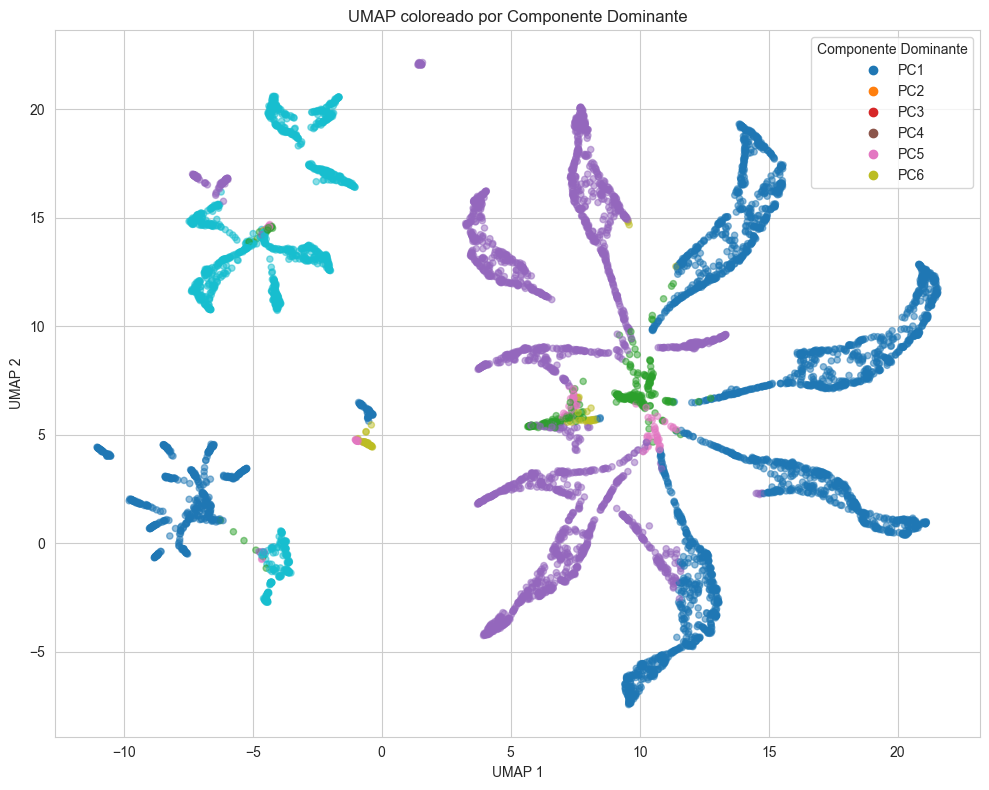

In [ ]:
# === ahora contra el pca ===
suppress_common_warnings()
df_tsne = pd.read_parquet("Data/df_pca_clusters.parquet")
X_pca = df_tsne.iloc[:, :6].values

# Muestra reproducible
np.random.seed(42)
sample_frac = 0.01
n_samples = max(int(X_pca.shape[0] * sample_frac), 1)
idx = np.random.choice(X_pca.shape[0], size=n_samples, replace=False)

X_sub = X_pca[idx]

# Componente dominante
componentes_dominantes = np.argmax(np.abs(X_sub), axis=1)

# UMAP
reducer = umap.UMAP(
    n_neighbors=50,
    min_dist=0.3,
    n_components=2,
    random_state=42
)
X_umap = reducer.fit_transform(X_sub)

# Graficar
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_umap[:,0],
    X_umap[:,1],
    c=componentes_dominantes,
    cmap='tab10',
    alpha=0.5,
    s=20
)
plt.title("UMAP coloreado por Componente Dominante")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

# Leyenda de componentes
handles = []
for i in range(6):
    handles.append(
        plt.Line2D(
            [0], [0],
            marker='o',
            linestyle='',
            color=scatter.cmap(i/6),
            label=f"PC{i+1}",
            markersize=6
        )
    )
plt.legend(handles=handles, title="Componente Dominante", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()

Dado que t-SNE y UMAP son técnicas distintas que producen distribuciones diferentes, el espacio embebido (las coordenadas 2D) no es comparable en valores absolutos, pero sí puedes analizar si los puntos del mismo cluster tienden a agruparse y si los clusters se separan de forma consistente.

Para cuantificar solapamientos entre clusters en los dos métodos, podemos:
	1.	Calcular la dispersión interna de cada cluster (ej. distancia media entre puntos del mismo cluster).
	2.	Calcular distancias entre centroides de clusters.
	3.	Medir cuántos vecinos cercanos de cada punto pertenecen a un cluster distinto (contaminación local).
	4.	Comparar asignaciones de clusters en ambas proyecciones (si se hicieran reclusterizaciones en 2D).


In [ ]:
suppress_common_warnings()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from scipy.spatial import ConvexHull
from sklearn.metrics import pairwise_distances

# Cargar datos base
df_tsne = pd.read_parquet("Data/df_pca_clusters.parquet")
X_pca = df_tsne.iloc[:, :6].values
clusters = df_tsne["Cluster"]

# Muestra reproducible
np.random.seed(42)
sample_frac = 0.01
n_samples = max(int(X_pca.shape[0] * sample_frac), 1)
idx = np.random.choice(X_pca.shape[0], size=n_samples, replace=False)

X_sub = X_pca[idx]
clusters_sub = clusters.iloc[idx].reset_index(drop=True)

# t-SNE
tsne = TSNE(
    n_components=2,
    random_state=42,
    n_iter=1000,
    perplexity=50,
    learning_rate=500,
    early_exaggeration=50
)
X_tsne = tsne.fit_transform(X_sub)

# UMAP
umap_reducer = umap.UMAP(
    n_neighbors=50,
    min_dist=0.3,
    n_components=2,
    random_state=42
)
X_umap = umap_reducer.fit_transform(X_sub)

# DataFrame conjunto
df_embedded = pd.DataFrame({
    "tsne_1": X_tsne[:,0],
    "tsne_2": X_tsne[:,1],
    "umap_1": X_umap[:,0],
    "umap_2": X_umap[:,1],
    "Cluster": clusters_sub
})

# Métricas de dispersión y área convexa
def resumen_dispersion(X_2d, labels, metodo=""):
    resumen = []
    for cluster_id in sorted(np.unique(labels)):
        puntos = X_2d[labels == cluster_id]
        centroide = puntos.mean(axis=0)
        dist_median = np.median(np.linalg.norm(puntos - centroide, axis=1))
        dist_mean = np.mean(np.linalg.norm(puntos - centroide, axis=1))
        dist_max = np.max(np.linalg.norm(puntos - centroide, axis=1))
        # Área del hull convex si hay suficientes puntos
        if puntos.shape[0] >= 3:
            hull = ConvexHull(puntos)
            area = hull.area
        else:
            area = np.nan
        resumen.append({
            "Cluster": cluster_id,
            "Metodologia": metodo,
            "N_puntos": puntos.shape[0],
            "Distancia_Mediana": dist_median,
            "Distancia_Media": dist_mean,
            "Distancia_Maxima": dist_max,
            "Area_Convexa": area
        })
    return pd.DataFrame(resumen)

df_disp_tsne = resumen_dispersion(X_tsne, clusters_sub, metodo="t-SNE")
df_disp_umap = resumen_dispersion(X_umap, clusters_sub, metodo="UMAP")

# Mostrar resultados
from IPython.display import display

print("\n=== DISPERSION t-SNE ===\n")
display(df_disp_tsne.round(3))

print("\n=== DISPERSION UMAP ===\n")
display(df_disp_umap.round(3))

# Componente dominante
componentes_dominantes = np.argmax(np.abs(X_sub), axis=1)

# Métrica de dispersión y área convexa
def calcular_metrica(X_2d, labels, nombre_metodo):
    resultados = []
    for cluster_id in sorted(np.unique(labels)):
        puntos = X_2d[labels == cluster_id]
        centroide = puntos.mean(axis=0)
        dist_median = np.median(np.linalg.norm(puntos - centroide, axis=1))
        dist_mean = np.mean(np.linalg.norm(puntos - centroide, axis=1))
        dist_max = np.max(np.linalg.norm(puntos - centroide, axis=1))
        if puntos.shape[0] >= 3:
            area = ConvexHull(puntos).area
        else:
            area = np.nan
        resultados.append({
            "Cluster": cluster_id,
            "Metodo": nombre_metodo,
            "N_puntos": len(puntos),
            "Distancia_Mediana": dist_median,
            "Distancia_Maxima": dist_max,
            "Area_Convexa": area
        })
    return pd.DataFrame(resultados)

df_tsne_disp = calcular_metrica(X_tsne, clusters_sub, "tSNE")
df_umap_disp = calcular_metrica(X_umap, clusters_sub, "UMAP")

# Tabla comparativa con columnas intercaladas
df_comparado = pd.DataFrame({"Cluster": df_tsne_disp["Cluster"]})

# Intercalar columnas por métrica: tSNE, UMAP, tSNE, UMAP, etc.
df_comparado["N_puntos_tSNE"] = df_tsne_disp["N_puntos"]
df_comparado["N_puntos_UMAP"] = df_umap_disp["N_puntos"]

df_comparado["Distancia_Mediana_tSNE"] = df_tsne_disp["Distancia_Mediana"]
df_comparado["Distancia_Mediana_UMAP"] = df_umap_disp["Distancia_Mediana"]

df_comparado["Distancia_Maxima_tSNE"] = df_tsne_disp["Distancia_Maxima"]
df_comparado["Distancia_Maxima_UMAP"] = df_umap_disp["Distancia_Maxima"]

df_comparado["Area_Convexa_tSNE"] = df_tsne_disp["Area_Convexa"]
df_comparado["Area_Convexa_UMAP"] = df_umap_disp["Area_Convexa"]

# Métrica adicional: razón de áreas
df_comparado["AreaRatio_tSNE_UMAP"] = df_comparado["Area_Convexa_tSNE"] / df_comparado["Area_Convexa_UMAP"]

# Mostrar tabla sintética
print("\n=== COMPARACIÓN t-SNE vs UMAP ===\n")
display(df_comparado.round(3))



=== DISPERSION t-SNE ===



,Cluster,Metodologia,N_puntos,Distancia_Mediana,Distancia_Media,Distancia_Maxima,Area_Convexa
0,0,t-SNE,2569,32.5640,33.2270,58.9350,292.5670
1,1,t-SNE,102,2.9020,2.8520,3.5280,17.4720
2,2,t-SNE,659,15.6660,17.6550,33.6590,134.8500
3,3,t-SNE,1889,44.3000,47.1780,77.3130,354.1870
4,4,t-SNE,1047,22.4610,21.6010,67.0670,280.1560
5,5,t-SNE,92,5.2420,8.2130,71.6970,175.7470
6,6,t-SNE,63,1.8760,1.8690,3.6640,15.3750



=== DISPERSION UMAP ===



,Cluster,Metodologia,N_puntos,Distancia_Mediana,Distancia_Media,Distancia_Maxima,Area_Convexa
0,0,UMAP,2569,6.4250,6.5560,13.2740,59.6340
1,1,UMAP,102,0.7860,0.7720,1.0640,4.7660
2,2,UMAP,659,2.6460,2.6160,5.0930,23.4010
3,3,UMAP,1889,5.0970,4.8710,7.9030,42.3340
4,4,UMAP,1047,3.2970,3.4900,14.6120,48.6490
5,5,UMAP,92,2.1440,3.3320,11.7030,30.4250
6,6,UMAP,63,0.2570,0.2680,0.5890,2.5130



=== COMPARACIÓN t-SNE vs UMAP ===



,Cluster,N_puntos_tSNE,N_puntos_UMAP,Distancia_Mediana_tSNE,Distancia_Mediana_UMAP,Distancia_Maxima_tSNE,Distancia_Maxima_UMAP,Area_Convexa_tSNE,Area_Convexa_UMAP,AreaRatio_tSNE_UMAP
0,0,2569,2569,32.5640,6.4250,58.9350,13.2740,292.5670,59.6340,4.9060
1,1,102,102,2.9020,0.7860,3.5280,1.0640,17.4720,4.7660,3.6660
2,2,659,659,15.6660,2.6460,33.6590,5.0930,134.8500,23.4010,5.7620
3,3,1889,1889,44.3000,5.0970,77.3130,7.9030,354.1870,42.3340,8.3660
4,4,1047,1047,22.4610,3.2970,67.0670,14.6120,280.1560,48.6490,5.7590
5,5,92,92,5.2420,2.1440,71.6970,11.7030,175.7470,30.4250,5.7760
6,6,63,63,1.8760,0.2570,3.6640,0.5890,15.3750,2.5130,6.1180


Esta comparación cuantitativa entre cómo t-SNE y UMAP representan los datos en dos dimensiones, a partir de las mismas observaciones y clusters, se puede sintetizar en cuatro puntos clave:

## 1. Qué mide cada indicador

- **Distancia Mediana y Distancia Media**: qué tan dispersos están los puntos de cada cluster respecto de su centroide.
- **Distancia Máxima**: la mayor separación interna en cada cluster.
- **Área Convexa**: el área mínima que contiene todos los puntos de un cluster (en 2D).

Estos valores permiten cuantificar si un cluster queda más "compacto" o más "estirado".

## 2. Qué muestran los resultados

- En todos los clusters, t-SNE produce áreas mucho más grandes. Por ejemplo, el Cluster 3 pasa de un área convexa de 354.2 en t-SNE a apenas 42.3 en UMAP, una reducción de casi 8 veces (ratio de 8.366).
- Las distancias máximas también son notablemente menores en UMAP: Cluster 4 tiene una distancia máxima de 67.07 en t-SNE y 14.61 en UMAP.
- En todos los clusters, las distancias medianas y máximas caen sustancialmente al pasar a UMAP.

## 3. Por qué es importante observar esto

- Estas diferencias son esperadas porque t-SNE tiende a preservar distancias locales y exagerar separaciones globales, mientras que UMAP mantiene una estructura global más compacta.
- Si el objetivo es visualizar la separación de grupos de manera clara y con amplios márgenes, t-SNE es más "explosivo".
- Si el objetivo es reflejar la densidad real y relaciones de cercanía global, UMAP produce representaciones más comprimidas y más proporcionales a la topología de alta dimensión.
- La razón de áreas (por ejemplo, ratios de entre 3.6 y 8.4 veces más área en t-SNE) indica que t-SNE enfatiza más los espacios vacíos entre clusters.

## 4. Qué implican estos datos para el análisis

- Si se desea reportar clusters con métricas de dispersión, estas cifras muestran que no se debe comparar a ciegas visualizaciones de t-SNE con UMAP: miden cosas distintas.
- Si se va a usar la proyección para tareas posteriores (por ejemplo, clasificación manual, selección de outliers), la compactación de UMAP puede ayudar a mantener relaciones más estables.
- Esta comparación objetiva permite fundamentar la decisión de qué método usar según la prioridad: separación visual clara (t-SNE) o fidelidad topológica (UMAP).

Estos indicadores cuantifican cuán diferente es la geometría de la representación reducida. Por eso es valioso reportarlos y no quedarse solo con la intuición de los gráficos.

### Entonces

1. **t-SNE genera representaciones mucho más dispersas**: Los clusters en t-SNE presentan áreas convexas entre 3 y 8 veces mayores que en UMAP, y las distancias máximas internas son significativamente más altas. Esto refleja su tendencia a exagerar las separaciones entre grupos, facilitando la percepción visual de límites claros.

2. **UMAP preserva una estructura global más compacta y proporcional**: Las reducciones consistentes en área y dispersión muestran que UMAP mantiene los clusters más cercanos entre sí y con menor variación interna, una representación más coherente con la densidad y la topología del espacio original.

3. **La elección del método depende de la finalidad analítica**: Si el objetivo es destacar separación visual y enfatizar diferencias aparentes, t-SNE es más adecuado; si se busca mantener relaciones relativas más fieles y estables, UMAP resulta preferible. Las métricas cuantitativas permiten fundamentar esta decisión de manera objetiva.


---

### Qué hicimos y algunas reflexiones finales

En este análisis se aplicaron cuatro técnicas fundamentales de aprendizaje no supervisado para explorar y estructurar los datos de comercio exterior:

**Reducción de dimensionalidad:**
- **PCA (Análisis de Componentes Principales)**: Técnica de reducción no supervisada de dimensión que transforma variables correlacionadas en componentes ortogonales, preservando la máxima varianza posible de los datos originales.

**Agrupamiento:**
- **K-Means**: Algoritmo de agrupamiento no supervisado que particiona las observaciones en clusters basándose en la proximidad euclidiana, optimizando la minimización de la varianza intra-cluster.

**Representación de reducción de dimensionalidad t-SNE y UMAP:**
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: Técnica no supervisada que mapea datos de alta dimensión a espacios de baja dimensión, preservando principalmente las distancias locales y exagerando las separaciones globales para facilitar la visualización.

- **UMAP (Uniform Manifold Approximation and Projection)**: Método de embedding no supervisado que construye representaciones de alta a baja dimensión manteniendo tanto la estructura local como global de los datos, produciendo visualizaciones más compactas y proporcionales a la topología original.

**Reflexiones metodológicas:**

La aplicación secuencial de estas técnicas permite una exploración sistemática de la estructura latente en los datos. PCA identifica las direcciones de máxima variabilidad, K-Means segmenta las observaciones en grupos homogéneos, mientras que t-SNE y UMAP ofrecen perspectivas complementarias para la visualización de estas estructuras en espacios reducidos.

La comparación cuantitativa entre t-SNE y UMAP revela diferencias sustanciales en cómo cada método representa la geometría de los clusters, lo cual es crucial para interpretar correctamente los resultados según el objetivo analítico específico.
